# ============================================================================
# Phase 05B - BTUMQA-225K Clean-Metadata Four-Seeds Final Evaluation,
# Ablation, Calibration, and LLM-Ready Structured Evidence
# ============================================================================

This notebook compares the four strict clean-metadata Phase 04 model families, fits
lightweight post-hoc calibration from validation predictions, evaluates calibrated
confidence on test predictions, and exports selected-model structured evidence for
the later post-hoc LLM/review layer.

# Dual Environment Compatibility Setup & Install Required Libraries


In [8]:
# ── DUAL ENVIRONMENT COMPATIBILITY & DEPENDENCY SETUP ────────────────────────
import os
import sys
from pathlib import Path

def resolve_project_environment(mount_point: str = "/content/drive") -> tuple[Path, Path]:
    try:
        import google.colab
        from google.colab import drive
        drive.mount(mount_point)
        project_root = Path(mount_point) / "MyDrive" / "AUGR-VQA"
        temp_dir = Path("/content")
        print("Running in Google Colab environment.")
    except ImportError:
        # Running locally (parent of notebooks directory)
        project_root = Path(os.getcwd()).parent.resolve()
        temp_dir = project_root / "temp"
        temp_dir.mkdir(parents=True, exist_ok=True)
        print("Running in Local environment.")
    return project_root, temp_dir

PROJECT_ROOT, TEMP_DIR = resolve_project_environment()
# ─────────────────────────────────────────────────────────────────────────────

import subprocess
import sys

required_packages = [
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "joblib",
]

for package in required_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Dependencies are ready.")

Dependencies are ready.


# Mount Google Drive and Configure Clean-Metadata Phase 05B Paths

In [9]:
from google.colab import drive
from pathlib import Path
import os
import time


def ensure_drive_connection(project_dir: Path, mount_point: str = "/content/drive"):
    def probe_path(target: Path):
        probe_target = target if target.exists() else target.parent
        return os.listdir(str(probe_target))

    try:
        probe_path(project_dir)
    except OSError as exc:
        if getattr(exc, "errno", None) != 107:
            raise
        print("Detected a stale Google Drive mount. Remounting now...")
        try:
            drive.flush_and_unmount()
            time.sleep(2)
        except Exception:
            pass
#         drive.mount(mount_point, force_remount=True)
        time.sleep(2)
        probe_path(project_dir)

    if not project_dir.exists():
        raise FileNotFoundError(
            f"Project Drive directory not found after mount check: {project_dir}"
        )


# drive.mount("/content/drive")

# Updated project path to point to the new drive structure
PROJECT_DRIVE_DIR = PROJECT_ROOT
ensure_drive_connection(PROJECT_DRIVE_DIR)

DATASET_RELEASE_NAME = "BTUMQA-225K"
PHASE5B_NOTEBOOK_NAME = (
    "BrainTumorVQA_Phase_05B_(BTUMQA_225K_Clean_Metadata_Four_Seeds_Final_"
    "Evaluation_Ablation_Calibration_Comparison)"
)
PHASE5B_METHOD_NAME = "BrainTumorVQA-BTUMQA-225K-CleanMetadata-FourSeeds-Final-Backbone-and-Reliability-Comparison"
PHASE5B_MODEL_VARIANT = "btumqa_225k_clean_metadata_four_seeds_final_eval_ablation_calibration"

# Corrected input paths: phase_3/p3a_brats_vqa_dataset/dataset_btumqa_225k
DATASET_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3a_brats_vqa_dataset" / "dataset_btumqa_225k"
BTUMQA_FULL_QA_PATH = DATASET_DIR / "btumqa_225k_qa_pairs.csv"

# Corrected training paths: phase_4/p4a_qgca_training
PHASE4_BASE_DIR = PROJECT_DRIVE_DIR / "phase_4" / "p4a_qgca_training"
PHASE4_CLEAN_METADATA_PARENT_DIR = PHASE4_BASE_DIR / "clean_metadata_training"
PHASE4_NO_UGTM_PARENT_DIR = PHASE4_CLEAN_METADATA_PARENT_DIR / "no_ugtm_qgca_btumqa_four_seeds"
PHASE4_UGTM_PARENT_DIR = PHASE4_CLEAN_METADATA_PARENT_DIR / "ugtm_qgca_btumqa_four_seeds"
PHASE4_PRUGTM_PARENT_DIR = PHASE4_CLEAN_METADATA_PARENT_DIR / "prugtm_qgca_btumqa_four_seeds"
PHASE4_QADP_PARENT_DIR = PHASE4_CLEAN_METADATA_PARENT_DIR / "adaptive_prugtm_qgca_btumqa_four_seeds"

# Corrected result directory: phase_5/p5b_final_evaluation_ablation_calibration
PHASE5B_BASE_DIR = PROJECT_DRIVE_DIR / "phase_5" / "p5b_final_evaluation_ablation_calibration"
PHASE5B_DIR = PHASE5B_BASE_DIR / "btumqa_225k_clean_metadata_four_seeds_final_comparison"
TABLES_DIR = PHASE5B_DIR / "tables"
REPORTS_DIR = PHASE5B_DIR / "reports"
FIGURES_DIR = PHASE5B_DIR / "figures"
MODELS_DIR = PHASE5B_DIR / "models"
PREDICTIONS_DIR = PHASE5B_DIR / "predictions"
EXPLANATION_READY_DIR = PHASE5B_DIR / "explanation_ready"
DONE_DIR = PHASE5B_DIR / "done"

for path in [PHASE5B_DIR, TABLES_DIR, REPORTS_DIR, FIGURES_DIR, MODELS_DIR, PREDICTIONS_DIR, EXPLANATION_READY_DIR, DONE_DIR]:
    path.mkdir(parents=True, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging
BTUMQA full QA path: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k/btumqa_225k_qa_pairs.csv
No-UGTM clean parent: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/no_ugtm_qgca_btumqa_four_seeds
UGTM-QGCA clean parent: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/ugtm_qgca_btumqa_four_seeds
PRUGTM-Hybrid clean parent: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/cl

# Clean-Metadata Clean-Metadata Four-Seeds Phase 05B Configuration

In [11]:
RUN_SEEDS = [42, 1337, 2025, 3407]
RANDOM_STATE = 42
CALIBRATION_BINS = 15
SELECTIVE_COVERAGES = [0.50, 0.70, 0.80, 0.90, 0.95, 1.00]
MIN_CONFIDENCE = 1e-6
SAVE_FIGURES = True
REQUIRE_COMPLETE_BACKBONE_SEEDS = True

QCUR_FULL_FORM = "Question-aware Confidence Calibration for Uncertainty Reliability"
BASELINE_NUMERIC_FEATURES = ["confidence", "confidence_logit"]
QCUR_NUMERIC_FEATURES = ["confidence", "confidence_logit"]
QCUR_CATEGORICAL_FEATURES = [
    "predicted_answer",
    "question_family",
    "question_style",
]
QCUR_EXCLUDED_REPORTING_ONLY_FIELDS = [
    "ambiguity_flag",
    "signal_gap_bucket",
    "difficulty_level",
    "region_target_primary",
    "region_target_secondary",
    "region_target_pair",
]

REGION_NAMES = ["edema", "ncr_net", "enhancing", "tumor", "context", "global"]
UNCERTAINTY_FEATURE_SUFFIXES = {
    "uncertainty": "_uncertainty",
    "weight": "_weight",
    "area_pixels": "_area_pixels",
}

LOW_CONFIDENCE_THRESHOLD = 0.70
CALIBRATION_DROP_THRESHOLD = 0.15
MODERATE_CONFIDENCE_THRESHOLD = 0.85
HIGH_UNCERTAINTY_QUANTILE = 0.75
LOW_UNCERTAINTY_QUANTILE = 0.25

KEY_FAMILIES = ["more_reliable_region", "more_uncertain_region"]
KEY_STYLES = ["comparative"]
KEY_GROUP_COLUMNS = [
    "question_style",
    "question_family",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_pair",
]

BACKBONE_SPECS = {
    "no_ugtm_clean": {
        "label": "No-UGTM",
        "parent_dir": PHASE4_NO_UGTM_PARENT_DIR,
        "report_name": "phase4_no_ugtm_training_report.json",
        "source_type": "phase4_clean_metadata_ablation",
    },
    "ugtm_qgca_clean": {
        "label": "UGTM-QGCA",
        "parent_dir": PHASE4_UGTM_PARENT_DIR,
        "report_name": "phase4_qgca_training_report.json",
        "source_type": "phase4_clean_metadata_backbone",
    },
    "prugtm_hybrid_clean": {
        "label": "PRUGTM-Hybrid",
        "parent_dir": PHASE4_PRUGTM_PARENT_DIR,
        "report_name": "phase4_prugtm_hybrid_training_report.json",
        "source_type": "phase4_clean_metadata_backbone",
    },
    "qadp_prugtm_hybrid_clean": {
        "label": "QAdp-PRUGTM-Hybrid",
        "parent_dir": PHASE4_QADP_PARENT_DIR,
        "report_name": "phase4_qa_prugtm_hybrid_training_report.json",
        "source_type": "phase4_clean_metadata_adaptive_candidate",
    },
}

LEGACY_ABLATION_SPECS = {}

DISPLAY_ORDER = {
    "No-UGTM": 1,
    "UGTM-QGCA": 2,
    "PRUGTM-Hybrid": 3,
    "QAdp-PRUGTM-Hybrid": 4,
}

METHOD_ORDER = ["Raw", "Posthoc", "Q-CUR"]
METHOD_PALETTE = {"Raw": "#b85c5c", "Posthoc": "#d39b2f", "Q-CUR": "#247a69"}
BACKBONE_PALETTE = {
    "No-UGTM": "#c98936",
    "UGTM-QGCA": "#2f6f9f",
    "PRUGTM-Hybrid": "#2a9d8f",
    "QAdp-PRUGTM-Hybrid": "#7659a6",
}

print("Run seeds:", RUN_SEEDS)
print("Require complete backbone seeds:", REQUIRE_COMPLETE_BACKBONE_SEEDS)
print("Q-CUR:", QCUR_FULL_FORM)
print("Reviewer-clean Q-CUR numeric features:", QCUR_NUMERIC_FEATURES)
print("Reviewer-clean Q-CUR categorical features:", QCUR_CATEGORICAL_FEATURES)
print("Reporting-only fields excluded from Q-CUR fitting:", QCUR_EXCLUDED_REPORTING_ONLY_FIELDS)
print("Clean backbones:", [spec["label"] for spec in BACKBONE_SPECS.values()])

Run seeds: [42, 1337, 2025, 3407]
Require complete backbone seeds: True
Q-CUR: Question-aware Confidence Calibration for Uncertainty Reliability
Reviewer-clean Q-CUR numeric features: ['confidence', 'confidence_logit']
Reviewer-clean Q-CUR categorical features: ['predicted_answer', 'question_family', 'question_style']
Reporting-only fields excluded from Q-CUR fitting: ['ambiguity_flag', 'signal_gap_bucket', 'difficulty_level', 'region_target_primary', 'region_target_secondary', 'region_target_pair']
Clean backbones: ['No-UGTM', 'UGTM-QGCA', 'PRUGTM-Hybrid', 'QAdp-PRUGTM-Hybrid']


# Imports and Helper Utilities

In [12]:
import json
import math
from collections import defaultdict
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#d6dde5", "axes.titleweight": "bold"})


def now_string():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def read_json(path: Path, default=None):
    if not path.exists():
        return {} if default is None else default
    return json.loads(path.read_text(encoding="utf-8"))


def write_json(path: Path, payload: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def save_dataframe(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved {len(df):,} rows -> {path}")


def save_figure(fig, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    # Avoid mixing constrained_layout with tight_layout after colorbars are created.
    layout_engine = fig.get_layout_engine() if hasattr(fig, "get_layout_engine") else None
    if layout_engine is None:
        try:
            fig.tight_layout()
        except RuntimeError as exc:
            print(f"Skipping tight_layout for {path.name}: {exc}")
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def seed_tag(run_seed: int):
    return f"seed_{int(run_seed)}"


def clamp_probs(values, eps=MIN_CONFIDENCE):
    arr = np.asarray(values, dtype=np.float64)
    return np.clip(arr, eps, 1.0 - eps)


def safe_logit(values):
    p = clamp_probs(values)
    return np.log(p / (1.0 - p))


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_backbone_seed_paths(backbone_key: str, run_seed: int):
    spec = BACKBONE_SPECS[backbone_key]
    tag = seed_tag(run_seed)
    seed_dir = Path(spec["parent_dir"]) / tag
    return {
        "run_seed": int(run_seed),
        "seed_tag": tag,
        "seed_dir": seed_dir,
        "report_path": seed_dir / spec["report_name"],
        "val_predictions": seed_dir / "predictions" / "val_predictions.csv",
        "test_predictions": seed_dir / "predictions" / "test_predictions.csv",
        "test_metrics_path": seed_dir / "reports" / "test_metrics.json",
        "final_eval_path": seed_dir / "reports" / "final_eval_summary.json",
    }


def compute_answer_metrics(df: pd.DataFrame):
    y_true = df["gold_answer"].astype(str).to_numpy()
    y_pred = df["predicted_answer"].astype(str).to_numpy()
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


def compute_ece(y_true, y_prob, n_bins=CALIBRATION_BINS):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_prob = clamp_probs(y_prob)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []
    for idx in range(n_bins):
        left = bin_edges[idx]
        right = bin_edges[idx + 1]
        if idx == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)
        count = int(mask.sum())
        if count == 0:
            rows.append({
                "bin_index": idx,
                "bin_left": float(left),
                "bin_right": float(right),
                "count": 0,
                "mean_confidence": None,
                "accuracy": None,
                "gap": None,
            })
            continue
        mean_conf = float(y_prob[mask].mean())
        mean_acc = float(y_true[mask].mean())
        gap = abs(mean_conf - mean_acc)
        ece += (count / len(y_true)) * gap
        rows.append({
            "bin_index": idx,
            "bin_left": float(left),
            "bin_right": float(right),
            "count": count,
            "mean_confidence": mean_conf,
            "accuracy": mean_acc,
            "gap": float(gap),
        })
    return float(ece), rows


def compute_selective_accuracy(y_true, y_prob, coverages=SELECTIVE_COVERAGES):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    order = np.argsort(-y_prob)
    y_sorted = y_true[order]
    result = {}
    for coverage in coverages:
        k = max(1, int(math.ceil(len(y_sorted) * float(coverage))))
        result[f"{coverage:.2f}"] = float(y_sorted[:k].mean())
    return result


def compute_aurc(y_true, y_prob):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    order = np.argsort(-y_prob)
    correct_sorted = y_true[order]
    cumulative_correct = np.cumsum(correct_sorted)
    counts = np.arange(1, len(correct_sorted) + 1, dtype=np.float64)
    coverage = counts / len(correct_sorted)
    risk = 1.0 - (cumulative_correct / counts)
    try:
        aurc = float(np.trapezoid(risk, coverage))
    except AttributeError:
        aurc = float(np.trapz(risk, coverage))
    return aurc, coverage, risk


def compute_calibration_metrics(df: pd.DataFrame, prob_col: str):
    y_true = df["is_correct"].astype(int).to_numpy()
    y_prob = clamp_probs(df[prob_col].astype(float).to_numpy())
    ece, reliability_rows = compute_ece(y_true, y_prob)
    brier = float(np.mean((y_prob - y_true) ** 2))
    nll = float(log_loss(y_true, y_prob, labels=[0, 1]))
    aurc, coverage, risk = compute_aurc(y_true, y_prob)
    selective_accuracy = compute_selective_accuracy(y_true, y_prob)
    return {
        "ece": ece,
        "brier": brier,
        "nll": nll,
        "aurc": aurc,
        "selective_accuracy": selective_accuracy,
        "reliability_bins": reliability_rows,
        "risk_coverage_curve": {
            "coverage": [float(x) for x in coverage.tolist()],
            "risk": [float(x) for x in risk.tolist()],
        },
    }


def summarize_method(df: pd.DataFrame, prob_col: str, method_label: str):
    answer_metrics = compute_answer_metrics(df)
    calib = compute_calibration_metrics(df, prob_col)
    return {
        "method": method_label,
        "num_rows": int(len(df)),
        "answer_metrics": answer_metrics,
        "calibration_metrics": {
            "ece": float(calib["ece"]),
            "brier": float(calib["brier"]),
            "nll": float(calib["nll"]),
            "aurc": float(calib["aurc"]),
            "selective_accuracy": calib["selective_accuracy"],
        },
        "reliability_bins": calib["reliability_bins"],
        "risk_coverage_curve": calib["risk_coverage_curve"],
    }


def method_summary_to_row(backbone_key, backbone_label, seed_tag_value, method_label, summary):
    row = {
        "backbone_key": backbone_key,
        "backbone": backbone_label,
        "seed_tag": seed_tag_value,
        "method": method_label,
        "num_rows": summary["num_rows"],
        "accuracy": summary["answer_metrics"]["accuracy"],
        "macro_f1": summary["answer_metrics"]["macro_f1"],
        "weighted_f1": summary["answer_metrics"]["weighted_f1"],
        "ece": summary["calibration_metrics"]["ece"],
        "brier": summary["calibration_metrics"]["brier"],
        "nll": summary["calibration_metrics"]["nll"],
        "aurc": summary["calibration_metrics"]["aurc"],
    }
    for coverage_key, value in summary["calibration_metrics"]["selective_accuracy"].items():
        row[f"selective_acc_at_{coverage_key}"] = value
    return row


def aggregate_numeric_frame(df: pd.DataFrame, group_cols: list, value_cols: list):
    rows = []
    for group_values, group_df in df.groupby(group_cols, dropna=False, sort=False):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)
        row = {col: value for col, value in zip(group_cols, group_values)}
        row["num_runs"] = int(group_df["seed_tag"].nunique()) if "seed_tag" in group_df.columns else int(len(group_df))
        for col in value_cols:
            values = group_df[col].astype(float)
            row[f"{col}__mean"] = float(values.mean())
            row[f"{col}__std"] = float(values.std(ddof=1)) if len(values) > 1 else 0.0
        rows.append(row)
    return pd.DataFrame(rows)


def aggregate_method_payloads(payloads: list, method_name: str):
    if len(payloads) == 1:
        return payloads[0]
    row_payloads = []
    for payload in payloads:
        row = {
            "method": method_name,
            "num_rows": payload["num_rows"],
            **payload["answer_metrics"],
            **payload["calibration_metrics"],
        }
        row_payloads.append(row)
    df = pd.DataFrame(row_payloads)
    return {
        "method": method_name,
        "num_runs": len(payloads),
        "num_rows_mean": float(df["num_rows"].mean()),
        "answer_metrics": {
            metric: {
                "mean": float(df[metric].mean()),
                "std": float(df[metric].std(ddof=1)) if len(df) > 1 else 0.0,
            }
            for metric in ["accuracy", "macro_f1", "weighted_f1"]
        },
        "calibration_metrics": {
            metric: {
                "mean": float(df[metric].mean()),
                "std": float(df[metric].std(ddof=1)) if len(df) > 1 else 0.0,
            }
            for metric in ["ece", "brier", "nll", "aurc"]
        },
        "selective_accuracy": {
            key: {
                "mean": float(np.mean([item["calibration_metrics"]["selective_accuracy"][key] for item in payloads])),
                "std": float(np.std([item["calibration_metrics"]["selective_accuracy"][key] for item in payloads], ddof=1)) if len(payloads) > 1 else 0.0,
            }
            for key in payloads[0]["calibration_metrics"]["selective_accuracy"]
        },
        "reliability_bins": aggregate_reliability_bins(payloads),
        "risk_coverage_curve": aggregate_risk_coverage_curves(payloads),
    }


def aggregate_reliability_bins(payloads: list):
    bins_by_index = defaultdict(list)
    for payload in payloads:
        for row in payload["reliability_bins"]:
            bins_by_index[int(row["bin_index"])].append(row)
    aggregated = []
    for idx in sorted(bins_by_index):
        rows = bins_by_index[idx]
        valid = [row for row in rows if row["count"] > 0 and row["mean_confidence"] is not None]
        if not valid:
            aggregated.append({**rows[0], "count": 0, "mean_confidence": None, "accuracy": None, "gap": None})
            continue
        total_count = sum(row["count"] for row in valid)
        mean_conf = sum(row["mean_confidence"] * row["count"] for row in valid) / total_count
        accuracy = sum(row["accuracy"] * row["count"] for row in valid) / total_count
        aggregated.append({
            "bin_index": idx,
            "bin_left": float(valid[0]["bin_left"]),
            "bin_right": float(valid[0]["bin_right"]),
            "count": int(total_count),
            "mean_confidence": float(mean_conf),
            "accuracy": float(accuracy),
            "gap": float(abs(mean_conf - accuracy)),
        })
    return aggregated


def aggregate_risk_coverage_curves(payloads: list):
    base_coverage = np.asarray(payloads[0]["risk_coverage_curve"]["coverage"], dtype=np.float64)
    risk_curves = []
    for payload in payloads:
        coverage = np.asarray(payload["risk_coverage_curve"]["coverage"], dtype=np.float64)
        risk = np.asarray(payload["risk_coverage_curve"]["risk"], dtype=np.float64)
        risk_curves.append(np.interp(base_coverage, coverage, risk))
    risk_stack = np.vstack(risk_curves)
    return {
        "coverage": [float(x) for x in base_coverage.tolist()],
        "risk": [float(x) for x in risk_stack.mean(axis=0).tolist()],
        "risk_std": [float(x) for x in risk_stack.std(axis=0, ddof=1).tolist()] if len(payloads) > 1 else [0.0 for _ in base_coverage],
    }


print("Helper utilities ready.")

Helper utilities ready.


# Load and Validate Clean-Metadata Multi-Seed Phase 4 Runs

In [13]:
PREDICTION_REQUIRED_COLUMNS = [
    "split",
    "qa_id",
    "unique_id",
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
    "region_target_pair",
    "gold_answer",
    "predicted_answer",
    "confidence",
]

PREDICTION_OPTIONAL_DIAGNOSTIC_COLUMNS = [
    "aux_gate_mean",
    "attended_uncertainty",
]


def normalize_prediction_df(path: Path, split_name: str, source_label: str):
    if not path.exists():
        raise FileNotFoundError(f"{source_label} {split_name} predictions not found: {path}")
    df = pd.read_csv(path, dtype=str).fillna("")
    missing = [col for col in PREDICTION_REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"{source_label} {split_name} predictions missing columns: {missing}")
    keep_cols = PREDICTION_REQUIRED_COLUMNS + [
        col for col in PREDICTION_OPTIONAL_DIAGNOSTIC_COLUMNS if col in df.columns
    ]
    df = df[keep_cols].copy()
    for col in PREDICTION_OPTIONAL_DIAGNOSTIC_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan
    df["confidence"] = df["confidence"].astype(float).clip(MIN_CONFIDENCE, 1.0 - MIN_CONFIDENCE)
    df["confidence_logit"] = safe_logit(df["confidence"].to_numpy())
    df["is_correct"] = (df["gold_answer"] == df["predicted_answer"]).astype(int)
    df["split"] = split_name
    return df


def validate_phase4_report(report: dict, source_label: str):
    dataset_name = str(report.get("dataset_release_name", "")).strip()
    if dataset_name and dataset_name != DATASET_RELEASE_NAME:
        raise ValueError(f"{source_label} uses dataset {dataset_name}, expected {DATASET_RELEASE_NAME}.")


backbone_runs = {}
missing_required = []

for backbone_key, spec in BACKBONE_SPECS.items():
    runs = []
    for run_seed in RUN_SEEDS:
        paths = build_backbone_seed_paths(backbone_key, run_seed)
        required_paths = [
            paths["report_path"],
            paths["val_predictions"],
            paths["test_predictions"],
            paths["test_metrics_path"],
        ]
        missing = [str(path) for path in required_paths if not path.exists()]
        if missing:
            missing_required.extend([f"{spec['label']} {paths['seed_tag']}: {path}" for path in missing])
            continue
        report = read_json(paths["report_path"], {})
        validate_phase4_report(report, f"{spec['label']} {paths['seed_tag']}")
        runs.append({**paths, "report": report, "test_metrics": read_json(paths["test_metrics_path"], {})})
    backbone_runs[backbone_key] = runs

if missing_required and REQUIRE_COMPLETE_BACKBONE_SEEDS:
    raise FileNotFoundError(
        "Missing required clean-metadata Phase 4 outputs. Complete all requested seeds before final Phase 05B.\n"
        + "\n".join(missing_required)
    )

for backbone_key, runs in backbone_runs.items():
    print("\n" + "=" * 100)
    print(BACKBONE_SPECS[backbone_key]["label"])
    print("Runs found:", [run["seed_tag"] for run in runs])
    for run in runs:
        print(run["seed_tag"], "| val:", run["val_predictions"], "| test:", run["test_predictions"])


No-UGTM
Runs found: ['seed_42', 'seed_1337', 'seed_2025', 'seed_3407']
seed_42 | val: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/no_ugtm_qgca_btumqa_four_seeds/seed_42/predictions/val_predictions.csv | test: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/no_ugtm_qgca_btumqa_four_seeds/seed_42/predictions/test_predictions.csv
seed_1337 | val: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/no_ugtm_qgca_btumqa_four_seeds/seed_1337/predictions/val_predictions.csv | test: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/clean_metadata_training/no_ugtm_qgca_btumqa_four_seeds/seed_1337/predictions/test_predictions.cs

# Confirm Clean-Only Ablation Scope

In [14]:
legacy_ablation_runs = {}
print("Clean Phase 05B uses only the four clean Phase 04 model families; no old metadata-using or legacy ablation runs are loaded.")

Clean Phase 05B uses only the four clean Phase 04 model families; no old metadata-using or legacy ablation runs are loaded.


# Fit Reviewer-Clean Calibration Models and Export Per-Run Structured Evidence

In [15]:
if not BTUMQA_FULL_QA_PATH.exists():
    raise FileNotFoundError(f"BTUMQA full QA CSV not found: {BTUMQA_FULL_QA_PATH}")

btumqa_full_df = pd.read_csv(BTUMQA_FULL_QA_PATH, dtype=str).fillna("")
btumqa_full_df["qa_id"] = btumqa_full_df["qa_id"].astype(str)
dataset_join_columns = [
    "qa_id",
    "question",
    "answer",
    "question_family",
    "question_style",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
    "region_target_pair",
]
for region_name in REGION_NAMES:
    for suffix in UNCERTAINTY_FEATURE_SUFFIXES.values():
        col = f"{region_name}{suffix}"
        if col in btumqa_full_df.columns:
            dataset_join_columns.append(col)
dataset_join_columns = [col for col in dict.fromkeys(dataset_join_columns) if col in btumqa_full_df.columns]
btumqa_join_df = btumqa_full_df[dataset_join_columns].drop_duplicates(subset=["qa_id"]).copy()
print("Loaded BTUMQA rows for explanation-ready joins:", len(btumqa_join_df))


def build_baseline_pipeline(run_seed: int):
    preprocess = ColumnTransformer(
        transformers=[("numeric", StandardScaler(), BASELINE_NUMERIC_FEATURES)],
        remainder="drop",
    )
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE + int(run_seed))),
        ]
    )


def build_qcur_pipeline(run_seed: int):
    preprocess = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), QCUR_NUMERIC_FEATURES),
            ("categorical", make_one_hot_encoder(), QCUR_CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("classifier", LogisticRegression(max_iter=2500, random_state=RANDOM_STATE + int(run_seed))),
        ]
    )


def compute_slice_rows(df: pd.DataFrame, backbone_key: str, backbone_label: str, seed_tag_value: str, method_label: str, prob_col: str):
    rows = []
    for group_col in KEY_GROUP_COLUMNS:
        for group_value, group_df in df.groupby(group_col, dropna=False):
            label = str(group_value) if str(group_value) != "" else "<empty>"
            summary = summarize_method(group_df.reset_index(drop=True), prob_col, method_label)
            row = method_summary_to_row(backbone_key, backbone_label, seed_tag_value, method_label, summary)
            row["slice_type"] = group_col
            row["slice_value"] = label
            rows.append(row)
    return rows


def as_float_or_nan(value):
    try:
        if pd.isna(value) or value == "":
            return np.nan
        return float(value)
    except Exception:
        return np.nan


def valid_region(value: str):
    value = str(value).strip()
    return value if value in REGION_NAMES else ""


def choose_target_region(row: pd.Series):
    predicted_region = valid_region(row.get("predicted_answer", ""))
    primary_region = valid_region(row.get("region_target_primary", ""))
    secondary_region = valid_region(row.get("region_target_secondary", ""))
    if predicted_region:
        return predicted_region
    if primary_region:
        return primary_region
    if secondary_region:
        return secondary_region
    return ""


def choose_comparison_region(row: pd.Series, target_region: str):
    primary_region = valid_region(row.get("region_target_primary", ""))
    secondary_region = valid_region(row.get("region_target_secondary", ""))
    if target_region == primary_region and secondary_region:
        return secondary_region
    if target_region == secondary_region and primary_region:
        return primary_region
    if secondary_region:
        return secondary_region
    if primary_region and primary_region != target_region:
        return primary_region
    return ""


def region_value(row: pd.Series, region_name: str, suffix: str):
    if not region_name:
        return np.nan
    col = f"{region_name}{suffix}"
    if col not in row.index:
        return np.nan
    return as_float_or_nan(row[col])


def write_jsonl(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        for record in df.replace({np.nan: None}).to_dict(orient="records"):
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")
    print(f"Saved {len(df):,} JSONL rows -> {path}")


def build_review_reason(row: pd.Series):
    reasons = []
    if bool(row.get("low_confidence_flag", False)):
        reasons.append("low calibrated confidence")
    if bool(row.get("calibration_drop_flag", False)):
        reasons.append("calibrated confidence is meaningfully lower than raw confidence")
    if bool(row.get("high_uncertainty_flag", False)):
        reasons.append("elevated target-region uncertainty")
    if not reasons:
        return "available confidence and uncertainty evidence do not trigger a caution flag"
    return " + ".join(reasons)


def build_review_template(row: pd.Series):
    answer = row.get("predicted_answer", "")
    qcur = row.get("qcur_confidence", np.nan)
    uncertainty = row.get("target_region_uncertainty", np.nan)
    uncertainty_level = row.get("target_region_uncertainty_level", "unknown")
    if pd.isna(qcur):
        qcur_text = "unavailable calibrated confidence"
    else:
        qcur_text = f"{float(qcur):.2f} calibrated confidence"
    if pd.isna(uncertainty):
        uncertainty_text = "target-region uncertainty is unavailable"
    else:
        uncertainty_text = f"target-region uncertainty is {uncertainty_level} ({float(uncertainty):.2f})"
    if bool(row.get("review_flag", False)):
        return (
            f"The model predicts {answer} with {qcur_text}. "
            f"Because {uncertainty_text}, this answer is flagged for cautious interpretation."
        )
    return (
        f"The model predicts {answer} with {qcur_text}. "
        f"The available uncertainty evidence does not trigger a review flag."
    )


def build_structured_evidence_df(test_df: pd.DataFrame, backbone_key: str, backbone_label: str, seed_tag_value: str):
    evidence_df = test_df.merge(
        btumqa_join_df,
        on="qa_id",
        how="left",
        suffixes=("", "_dataset"),
    )
    if "question" not in evidence_df.columns:
        evidence_df["question"] = ""
    for col in ["question_family", "question_style", "ambiguity_flag", "signal_gap_bucket", "region_target_primary", "region_target_secondary", "region_target_pair"]:
        dataset_col = f"{col}_dataset"
        if dataset_col in evidence_df.columns:
            evidence_df[col] = evidence_df[col].replace("", np.nan).fillna(evidence_df[dataset_col]).fillna("")

    evidence_df["model_key"] = backbone_key
    evidence_df["model_label"] = backbone_label
    evidence_df["seed"] = seed_tag_value
    evidence_df["target_region"] = evidence_df.apply(choose_target_region, axis=1)
    evidence_df["comparison_region"] = evidence_df.apply(
        lambda row: choose_comparison_region(row, row["target_region"]),
        axis=1,
    )
    evidence_df["target_region_uncertainty"] = evidence_df.apply(
        lambda row: region_value(row, row["target_region"], UNCERTAINTY_FEATURE_SUFFIXES["uncertainty"]),
        axis=1,
    )
    evidence_df["comparison_region_uncertainty"] = evidence_df.apply(
        lambda row: region_value(row, row["comparison_region"], UNCERTAINTY_FEATURE_SUFFIXES["uncertainty"]),
        axis=1,
    )
    evidence_df["target_region_weight"] = evidence_df.apply(
        lambda row: region_value(row, row["target_region"], UNCERTAINTY_FEATURE_SUFFIXES["weight"]),
        axis=1,
    )
    evidence_df["target_region_area_pixels"] = evidence_df.apply(
        lambda row: region_value(row, row["target_region"], UNCERTAINTY_FEATURE_SUFFIXES["area_pixels"]),
        axis=1,
    )
    evidence_df["uncertainty_gap"] = (
        evidence_df["target_region_uncertainty"].astype(float)
        - evidence_df["comparison_region_uncertainty"].astype(float)
    )

    uncertainty_values = evidence_df["target_region_uncertainty"].dropna().astype(float)
    if len(uncertainty_values):
        low_cut = float(uncertainty_values.quantile(LOW_UNCERTAINTY_QUANTILE))
        high_cut = float(uncertainty_values.quantile(HIGH_UNCERTAINTY_QUANTILE))
    else:
        low_cut = np.nan
        high_cut = np.nan

    def uncertainty_level(value):
        if pd.isna(value):
            return "unknown"
        value = float(value)
        if not pd.isna(high_cut) and value >= high_cut:
            return "high"
        if not pd.isna(low_cut) and value <= low_cut:
            return "low"
        return "medium"

    evidence_df["target_region_uncertainty_level"] = evidence_df["target_region_uncertainty"].apply(uncertainty_level)
    evidence_df["low_confidence_flag"] = evidence_df["qcur_confidence"].astype(float) < LOW_CONFIDENCE_THRESHOLD
    evidence_df["calibration_drop_flag"] = (
        evidence_df["raw_confidence"].astype(float) - evidence_df["qcur_confidence"].astype(float)
    ) >= CALIBRATION_DROP_THRESHOLD
    evidence_df["high_uncertainty_flag"] = evidence_df["target_region_uncertainty_level"].eq("high")
    evidence_df["review_flag"] = (
        evidence_df["low_confidence_flag"]
        | evidence_df["calibration_drop_flag"]
        | (evidence_df["high_uncertainty_flag"] & (evidence_df["qcur_confidence"].astype(float) < MODERATE_CONFIDENCE_THRESHOLD))
    )
    evidence_df["review_reason"] = evidence_df.apply(build_review_reason, axis=1)
    evidence_df["review_template_text"] = evidence_df.apply(build_review_template, axis=1)

    output_cols = [
        "qa_id", "unique_id", "split", "seed", "model_key", "model_label",
        "question", "question_family", "question_style",
        "gold_answer", "predicted_answer", "is_correct",
        "raw_confidence", "posthoc_confidence", "qcur_confidence",
        "target_region", "comparison_region",
        "target_region_uncertainty", "comparison_region_uncertainty", "uncertainty_gap",
        "target_region_uncertainty_level", "target_region_weight", "target_region_area_pixels",
        "aux_gate_mean", "attended_uncertainty",
        "low_confidence_flag", "high_uncertainty_flag", "calibration_drop_flag", "review_flag", "review_reason",
        "review_template_text",
        "ambiguity_flag", "signal_gap_bucket", "region_target_primary", "region_target_secondary", "region_target_pair",
    ]
    for col in output_cols:
        if col not in evidence_df.columns:
            evidence_df[col] = np.nan
    return evidence_df[output_cols].copy()


def calibrate_single_run(backbone_key: str, backbone_label: str, run: dict):
    seed_tag_value = run["seed_tag"]
    run_seed = run["run_seed"]
    val_df = normalize_prediction_df(run["val_predictions"], "val", f"{backbone_label} {seed_tag_value}")
    test_df = normalize_prediction_df(run["test_predictions"], "test", f"{backbone_label} {seed_tag_value}")

    baseline_model = build_baseline_pipeline(run_seed)
    qcur_model = build_qcur_pipeline(run_seed)
    y_val = val_df["is_correct"].astype(int).to_numpy()

    baseline_model.fit(val_df[BASELINE_NUMERIC_FEATURES], y_val)
    qcur_model.fit(val_df[QCUR_NUMERIC_FEATURES + QCUR_CATEGORICAL_FEATURES], y_val)

    val_df = val_df.copy()
    test_df = test_df.copy()
    val_df["raw_confidence"] = val_df["confidence"].astype(float)
    test_df["raw_confidence"] = test_df["confidence"].astype(float)
    val_df["posthoc_confidence"] = baseline_model.predict_proba(val_df[BASELINE_NUMERIC_FEATURES])[:, 1]
    test_df["posthoc_confidence"] = baseline_model.predict_proba(test_df[BASELINE_NUMERIC_FEATURES])[:, 1]
    val_df["qcur_confidence"] = qcur_model.predict_proba(val_df[QCUR_NUMERIC_FEATURES + QCUR_CATEGORICAL_FEATURES])[:, 1]
    test_df["qcur_confidence"] = qcur_model.predict_proba(test_df[QCUR_NUMERIC_FEATURES + QCUR_CATEGORICAL_FEATURES])[:, 1]

    run_out_dir = PREDICTIONS_DIR / backbone_key / seed_tag_value
    model_out_dir = MODELS_DIR / backbone_key / seed_tag_value
    evidence_out_dir = EXPLANATION_READY_DIR / backbone_key / seed_tag_value
    run_out_dir.mkdir(parents=True, exist_ok=True)
    model_out_dir.mkdir(parents=True, exist_ok=True)
    evidence_out_dir.mkdir(parents=True, exist_ok=True)
    val_out_path = run_out_dir / "val_calibrated_predictions.csv"
    test_out_path = run_out_dir / "test_calibrated_predictions.csv"
    model_out_path = model_out_dir / "qcur_models.joblib"
    evidence_csv_path = evidence_out_dir / "test_structured_evidence.csv"
    evidence_jsonl_path = evidence_out_dir / "test_structured_evidence.jsonl"

    prediction_cols = [
        "split", "qa_id", "unique_id", "question_family", "question_style", "difficulty_level",
        "ambiguity_flag", "signal_gap_bucket", "region_target_primary", "region_target_secondary",
        "region_target_pair", "gold_answer", "predicted_answer", "is_correct",
        "raw_confidence", "posthoc_confidence", "qcur_confidence",
        "aux_gate_mean", "attended_uncertainty",
    ]
    val_df[prediction_cols].to_csv(val_out_path, index=False)
    test_df[prediction_cols].to_csv(test_out_path, index=False)
    joblib.dump(
        {
            "baseline_model": baseline_model,
            "qcur_model": qcur_model,
            "run_seed": int(run_seed),
            "seed_tag": seed_tag_value,
            "backbone_key": backbone_key,
            "backbone_label": backbone_label,
            "baseline_numeric_features": BASELINE_NUMERIC_FEATURES,
            "qcur_full_form": QCUR_FULL_FORM,
            "qcur_numeric_features": QCUR_NUMERIC_FEATURES,
            "qcur_categorical_features": QCUR_CATEGORICAL_FEATURES,
            "qcur_excluded_reporting_only_fields": QCUR_EXCLUDED_REPORTING_ONLY_FIELDS,
        },
        model_out_path,
    )

    structured_evidence_df = build_structured_evidence_df(test_df, backbone_key, backbone_label, seed_tag_value)
    structured_evidence_df.to_csv(evidence_csv_path, index=False)
    write_jsonl(structured_evidence_df, evidence_jsonl_path)

    method_payloads = {
        "Raw": summarize_method(test_df, "raw_confidence", "Raw"),
        "Posthoc": summarize_method(test_df, "posthoc_confidence", "Posthoc"),
        "Q-CUR": summarize_method(test_df, "qcur_confidence", "Q-CUR"),
    }

    slice_rows = []
    for method_label, prob_col in [
        ("Raw", "raw_confidence"),
        ("Posthoc", "posthoc_confidence"),
        ("Q-CUR", "qcur_confidence"),
    ]:
        slice_rows.extend(compute_slice_rows(test_df, backbone_key, backbone_label, seed_tag_value, method_label, prob_col))

    return {
        "backbone_key": backbone_key,
        "backbone_label": backbone_label,
        "run_seed": int(run_seed),
        "seed_tag": seed_tag_value,
        "val_predictions_path": str(val_out_path),
        "test_predictions_path": str(test_out_path),
        "model_path": str(model_out_path),
        "structured_evidence_csv_path": str(evidence_csv_path),
        "structured_evidence_jsonl_path": str(evidence_jsonl_path),
        "method_payloads": method_payloads,
        "slice_rows": slice_rows,
    }


calibration_run_payloads = []
overall_rows = []
full_slice_rows = []

for backbone_key, runs in backbone_runs.items():
    backbone_label = BACKBONE_SPECS[backbone_key]["label"]
    for run in runs:
        payload = calibrate_single_run(backbone_key, backbone_label, run)
        calibration_run_payloads.append(payload)
        for method_label, summary in payload["method_payloads"].items():
            overall_rows.append(method_summary_to_row(backbone_key, backbone_label, payload["seed_tag"], method_label, summary))
        full_slice_rows.extend(payload["slice_rows"])
        print(
            f"Finished calibration: {backbone_label} | {payload['seed_tag']} | "
            f"raw_acc={payload['method_payloads']['Raw']['answer_metrics']['accuracy']:.6f} | "
            f"qcur_ece={payload['method_payloads']['Q-CUR']['calibration_metrics']['ece']:.6f}"
        )

overall_run_level_df = pd.DataFrame(overall_rows)
full_slice_run_level_df = pd.DataFrame(full_slice_rows)

print("Overall run-level calibration rows:", len(overall_run_level_df))
print("Full slice run-level rows:", len(full_slice_run_level_df))

Loaded BTUMQA rows for explanation-ready joins: 225000
Saved 33,750 JSONL rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/no_ugtm_clean/seed_42/test_structured_evidence.jsonl
Finished calibration: No-UGTM | seed_42 | raw_acc=0.894311 | qcur_ece=0.019973
Saved 33,750 JSONL rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/no_ugtm_clean/seed_1337/test_structured_evidence.jsonl
Finished calibration: No-UGTM | seed_1337 | raw_acc=0.890370 | qcur_ece=0.020033
Saved 33,750 JSONL rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btu

# Build Clean Answer, Ablation, Calibration, and Slice Tables

In [16]:
def build_multiseed_answer_row(backbone_key: str, runs: list):
    spec = BACKBONE_SPECS[backbone_key]
    rows = []
    source_reports = []
    source_metrics = []
    claims = []
    for run in runs:
        test_metrics = run["test_metrics"]
        report = run["report"]
        source_reports.append(str(run["report_path"]))
        source_metrics.append(str(run["test_metrics_path"]))
        claim = report.get("main_claim", report.get("description", ""))
        if claim:
            claims.append(str(claim))
        rows.append({
            "seed_tag": run["seed_tag"],
            "test_accuracy": float(test_metrics.get("accuracy", 0.0)),
            "test_macro_f1": float(test_metrics.get("macro_f1", 0.0)),
            "test_weighted_f1": float(test_metrics.get("weighted_f1", 0.0)),
        })
    df = pd.DataFrame(rows)
    return {
        "backbone_key": backbone_key,
        "backbone": spec["label"],
        "num_runs": int(len(df)),
        "test_accuracy_mean": float(df["test_accuracy"].mean()),
        "test_accuracy_std": float(df["test_accuracy"].std(ddof=1)) if len(df) > 1 else 0.0,
        "test_macro_f1_mean": float(df["test_macro_f1"].mean()),
        "test_macro_f1_std": float(df["test_macro_f1"].std(ddof=1)) if len(df) > 1 else 0.0,
        "test_weighted_f1_mean": float(df["test_weighted_f1"].mean()),
        "test_weighted_f1_std": float(df["test_weighted_f1"].std(ddof=1)) if len(df) > 1 else 0.0,
        "source_type": spec["source_type"],
        "source_reports": json.dumps(source_reports),
        "source_metrics": json.dumps(source_metrics),
        "claims": " | ".join(sorted(set(claims)))[:800],
    }


answer_rows = [
    build_multiseed_answer_row(backbone_key, backbone_runs[backbone_key])
    for backbone_key in BACKBONE_SPECS
]
answer_df = pd.DataFrame(answer_rows)
answer_df = answer_df.sort_values(
    ["test_macro_f1_mean", "test_accuracy_mean", "test_weighted_f1_mean"],
    ascending=[False, False, False],
).reset_index(drop=True)
answer_df.insert(0, "rank", np.arange(1, len(answer_df) + 1))
ranked_backbone_order = answer_df["backbone"].tolist()
ranked_backbone_keys = answer_df["backbone_key"].tolist()
backbone_rank_map = {backbone: rank for rank, backbone in enumerate(ranked_backbone_order, start=1)}

ablation_df = answer_df.copy()

calibration_agg_df = aggregate_numeric_frame(
    overall_run_level_df,
    ["backbone_key", "backbone", "method"],
    [
        "accuracy", "macro_f1", "weighted_f1",
        "ece", "brier", "nll", "aurc",
        *[f"selective_acc_at_{coverage:.2f}" for coverage in SELECTIVE_COVERAGES],
    ],
).reset_index(drop=True)
calibration_agg_df["method"] = pd.Categorical(calibration_agg_df["method"], METHOD_ORDER, ordered=True)
calibration_agg_df["backbone_rank"] = calibration_agg_df["backbone"].map(backbone_rank_map).fillna(999).astype(int)
calibration_agg_df = calibration_agg_df.sort_values(["backbone_rank", "method"]).drop(columns=["backbone_rank"]).reset_index(drop=True)
calibration_agg_df["method"] = calibration_agg_df["method"].astype(str)

key_slice_df = full_slice_run_level_df[
    ((full_slice_run_level_df["slice_type"] == "question_style") & (full_slice_run_level_df["slice_value"].isin(KEY_STYLES)))
    | ((full_slice_run_level_df["slice_type"] == "question_family") & (full_slice_run_level_df["slice_value"].isin(KEY_FAMILIES)))
    | (full_slice_run_level_df["slice_type"].isin(["ambiguity_flag", "signal_gap_bucket"]))
].copy()

key_slice_agg_df = aggregate_numeric_frame(
    key_slice_df,
    ["backbone_key", "backbone", "method", "slice_type", "slice_value"],
    ["accuracy", "macro_f1", "weighted_f1", "ece", "brier", "nll", "aurc"],
).reset_index(drop=True)
key_slice_agg_df["backbone_rank"] = key_slice_agg_df["backbone"].map(backbone_rank_map).fillna(999).astype(int)
key_slice_agg_df["method"] = pd.Categorical(key_slice_agg_df["method"], METHOD_ORDER, ordered=True)
key_slice_agg_df = key_slice_agg_df.sort_values(["slice_type", "slice_value", "backbone_rank", "method"]).drop(columns=["backbone_rank"]).reset_index(drop=True)
key_slice_agg_df["method"] = key_slice_agg_df["method"].astype(str)

full_slice_agg_df = aggregate_numeric_frame(
    full_slice_run_level_df,
    ["backbone_key", "backbone", "method", "slice_type", "slice_value"],
    ["accuracy", "macro_f1", "weighted_f1", "ece", "brier", "nll", "aurc"],
).reset_index(drop=True)
full_slice_agg_df["backbone_rank"] = full_slice_agg_df["backbone"].map(backbone_rank_map).fillna(999).astype(int)
full_slice_agg_df["method"] = pd.Categorical(full_slice_agg_df["method"], METHOD_ORDER, ordered=True)
full_slice_agg_df = full_slice_agg_df.sort_values(["slice_type", "slice_value", "backbone_rank", "method"]).drop(columns=["backbone_rank"]).reset_index(drop=True)
full_slice_agg_df["method"] = full_slice_agg_df["method"].astype(str)

save_dataframe(answer_df, ANSWER_BACKBONE_TABLE_PATH)
save_dataframe(ablation_df, ABLATION_COMPARISON_TABLE_PATH)
save_dataframe(overall_run_level_df, CALIBRATION_RUN_LEVEL_TABLE_PATH)
save_dataframe(calibration_agg_df, CALIBRATION_AGG_TABLE_PATH)
save_dataframe(key_slice_agg_df, KEY_SLICE_TABLE_PATH)
save_dataframe(full_slice_agg_df, FULL_SLICE_TABLE_PATH)

print("Answer backbone table:")
display(answer_df.round(6))
print("Calibration aggregated table:")
display(calibration_agg_df.round(6))

Saved 4 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/tables/phase5b_clean_metadata_four_seeds_answer_backbone_table.csv
Saved 4 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/tables/phase5b_clean_metadata_four_seeds_ablation_comparison_table.csv
Saved 48 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/tables/phase5b_clean_metadata_four_seeds_calibration_run_level.csv
Saved 12 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_

,rank,backbone_key,backbone,num_runs,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std,test_weighted_f1_mean,test_weighted_f1_std,source_type,source_reports,source_metrics,claims
0,1,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,4,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,phase4_clean_metadata_adaptive_candidate,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",Question-adaptive uncertainty guidance preserv...
1,2,prugtm_hybrid_clean,PRUGTM-Hybrid,4,0.901585,0.002488,0.900537,0.002575,0.904294,0.002296,phase4_clean_metadata_backbone,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",Hybrid post-reasoning uncertainty preserves or...
2,3,no_ugtm_clean,No-UGTM,4,0.891311,0.002018,0.892008,0.001757,0.895013,0.002090,phase4_clean_metadata_ablation,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",No-UGTM removes pre-reasoning UGTM modulation ...
3,4,ugtm_qgca_clean,UGTM-QGCA,4,0.890911,0.005176,0.891312,0.003863,0.894473,0.005204,phase4_clean_metadata_backbone,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",UGTM pre-reasoning uncertainty modulation impr...


Calibration aggregated table:


,backbone_key,backbone,method,num_runs,accuracy__mean,accuracy__std,macro_f1__mean,macro_f1__std,weighted_f1__mean,weighted_f1__std,...,selective_acc_at_0.70__mean,selective_acc_at_0.70__std,selective_acc_at_0.80__mean,selective_acc_at_0.80__std,selective_acc_at_0.90__mean,selective_acc_at_0.90__std,selective_acc_at_0.95__mean,selective_acc_at_0.95__std,selective_acc_at_1.00__mean,selective_acc_at_1.00__std
0,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,4,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,...,0.973132,0.005615,0.963639,0.010605,0.943514,0.014392,0.928547,0.014989,0.911430,0.014723
1,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Posthoc,4,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,...,0.973132,0.005615,0.963639,0.010605,0.943514,0.014392,0.928547,0.014989,0.911430,0.014723
2,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Q-CUR,4,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,...,0.991778,0.003708,0.979843,0.008793,0.955926,0.013570,0.937818,0.014964,0.911430,0.014723
3,prugtm_hybrid_clean,PRUGTM-Hybrid,Raw,4,0.901585,0.002488,0.900537,0.002575,0.904294,0.002296,...,0.971386,0.000976,0.957491,0.001816,0.934477,0.002710,0.919455,0.002995,0.901585,0.002488
4,prugtm_hybrid_clean,PRUGTM-Hybrid,Posthoc,4,0.901585,0.002488,0.900537,0.002575,0.904294,0.002296,...,0.971386,0.000976,0.957491,0.001816,0.934477,0.002710,0.919455,0.002995,0.901585,0.002488
5,prugtm_hybrid_clean,PRUGTM-Hybrid,Q-CUR,4,0.901585,0.002488,0.900537,0.002575,0.904294,0.002296,...,0.989926,0.000881,0.974037,0.001515,0.947045,0.002046,0.927939,0.001649,0.901585,0.002488
6,no_ugtm_clean,No-UGTM,Raw,4,0.891311,0.002018,0.892008,0.001757,0.895013,0.002090,...,0.964254,0.000630,0.948352,0.000712,0.923761,0.001144,0.908750,0.001357,0.891311,0.002018
7,no_ugtm_clean,No-UGTM,Posthoc,4,0.891311,0.002018,0.892008,0.001757,0.895013,0.002090,...,0.964254,0.000630,0.948352,0.000712,0.923761,0.001144,0.908750,0.001357,0.891311,0.002018
8,no_ugtm_clean,No-UGTM,Q-CUR,4,0.891311,0.002018,0.892008,0.001757,0.895013,0.002090,...,0.986159,0.001029,0.968269,0.001426,0.939556,0.002386,0.919401,0.001914,0.891311,0.002018
9,ugtm_qgca_clean,UGTM-QGCA,Raw,4,0.890911,0.005176,0.891312,0.003863,0.894473,0.005204,...,0.964720,0.001824,0.948824,0.003255,0.924963,0.004665,0.908851,0.005005,0.890911,0.005176


# Serialize Calibration Payloads

In [17]:
aggregated_method_payloads = {}
serialized_run_payloads = []

for payload in calibration_run_payloads:
    run_copy = {
        "backbone_key": payload["backbone_key"],
        "backbone_label": payload["backbone_label"],
        "run_seed": payload["run_seed"],
        "seed_tag": payload["seed_tag"],
        "val_predictions_path": payload["val_predictions_path"],
        "test_predictions_path": payload["test_predictions_path"],
        "model_path": payload["model_path"],
        "method_payloads": payload["method_payloads"],
    }
    serialized_run_payloads.append(run_copy)

by_backbone_method = defaultdict(list)
for payload in calibration_run_payloads:
    for method_label, summary in payload["method_payloads"].items():
        by_backbone_method[(payload["backbone_key"], payload["backbone_label"], method_label)].append(summary)

for (backbone_key, backbone_label, method_label), payloads in by_backbone_method.items():
    aggregated_method_payloads.setdefault(backbone_key, {"backbone_label": backbone_label, "methods": {}})
    aggregated_method_payloads[backbone_key]["methods"][method_label] = aggregate_method_payloads(
        payloads, f"{backbone_label} {method_label}"
    )

write_json(METHOD_SUMMARY_JSON_PATH, aggregated_method_payloads)
write_json(RUN_PAYLOADS_JSON_PATH, serialized_run_payloads)

print("Aggregated method payloads saved:", METHOD_SUMMARY_JSON_PATH)
print("Serialized run payloads saved:", RUN_PAYLOADS_JSON_PATH)

Aggregated method payloads saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/reports/phase5b_clean_metadata_four_seeds_method_summary.json
Serialized run payloads saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/reports/phase5b_clean_metadata_four_seeds_run_payloads.json


# Export Selected-Model Structured Evidence For Future LLM Review Layer

In [18]:
best_backbone_row_for_evidence = answer_df.sort_values(
    ["test_macro_f1_mean", "test_accuracy_mean"], ascending=[False, False]
).iloc[0].to_dict()
selected_backbone_key = best_backbone_row_for_evidence["backbone_key"]
selected_backbone_label = best_backbone_row_for_evidence["backbone"]

selected_payloads = [
    payload for payload in calibration_run_payloads
    if payload["backbone_key"] == selected_backbone_key
]
if not selected_payloads:
    raise ValueError(f"No calibration payloads found for selected backbone: {selected_backbone_key}")

selected_seed_rows = []
for payload in selected_payloads:
    raw_summary = payload["method_payloads"]["Raw"]
    qcur_summary = payload["method_payloads"]["Q-CUR"]
    selected_seed_rows.append({
        "seed_tag": payload["seed_tag"],
        "run_seed": int(payload["run_seed"]),
        "macro_f1": float(raw_summary["answer_metrics"]["macro_f1"]),
        "accuracy": float(raw_summary["answer_metrics"]["accuracy"]),
        "qcur_ece": float(qcur_summary["calibration_metrics"]["ece"]),
        "structured_evidence_csv_path": payload["structured_evidence_csv_path"],
        "structured_evidence_jsonl_path": payload["structured_evidence_jsonl_path"],
    })
selected_seed_df = pd.DataFrame(selected_seed_rows).sort_values(
    ["macro_f1", "accuracy", "qcur_ece"],
    ascending=[False, False, True],
).reset_index(drop=True)
selected_seed_df.to_csv(TABLES_DIR / "phase5b_clean_metadata_selected_model_seed_ranking.csv", index=False)

best_seed_row = selected_seed_df.iloc[0].to_dict()
selected_best_seed_evidence_df = pd.read_csv(best_seed_row["structured_evidence_csv_path"])
selected_all_seeds_evidence_df = pd.concat(
    [pd.read_csv(row["structured_evidence_csv_path"]) for _, row in selected_seed_df.iterrows()],
    ignore_index=True,
)

selected_best_seed_evidence_df.to_csv(SELECTED_MODEL_EVIDENCE_CSV_PATH, index=False)
write_jsonl(selected_best_seed_evidence_df, SELECTED_MODEL_EVIDENCE_JSONL_PATH)
selected_all_seeds_evidence_df.to_csv(SELECTED_MODEL_ALL_SEEDS_EVIDENCE_CSV_PATH, index=False)
write_jsonl(selected_all_seeds_evidence_df, SELECTED_MODEL_ALL_SEEDS_EVIDENCE_JSONL_PATH)

structured_evidence_schema = {
    "created_at": now_string(),
    "purpose": "LLM-ready structured evidence for post-hoc research review text generation.",
    "official_llm_input": str(SELECTED_MODEL_EVIDENCE_JSONL_PATH),
    "official_human_inspection_csv": str(SELECTED_MODEL_EVIDENCE_CSV_PATH),
    "all_selected_model_seeds_csv": str(SELECTED_MODEL_ALL_SEEDS_EVIDENCE_CSV_PATH),
    "all_selected_model_seeds_jsonl": str(SELECTED_MODEL_ALL_SEEDS_EVIDENCE_JSONL_PATH),
    "selected_model_key": selected_backbone_key,
    "selected_model_label": selected_backbone_label,
    "selected_seed_tag_for_official_llm_input": best_seed_row["seed_tag"],
    "selected_seed_rule": "Within the selected four-seed model family, choose the seed with highest Macro-F1, then Accuracy, then lowest Q-CUR ECE, so the official LLM input has one row per QA.",
    "llm_contract": [
        "Do not change predicted_answer.",
        "Do not recalculate confidence, uncertainty, or review_flag.",
        "Use qcur_confidence as calibrated confidence.",
        "Use review_flag exactly.",
        "Use research-safe language such as flagged for cautious interpretation.",
        "Do not provide clinical recommendations.",
    ],
    "review_flag_rules": {
        "low_confidence_flag": f"qcur_confidence < {LOW_CONFIDENCE_THRESHOLD}",
        "calibration_drop_flag": f"raw_confidence - qcur_confidence >= {CALIBRATION_DROP_THRESHOLD}",
        "high_uncertainty_flag": f"target_region_uncertainty >= per-run {HIGH_UNCERTAINTY_QUANTILE:.2f} quantile",
        "review_flag": "low confidence OR calibration drop OR high uncertainty with qcur_confidence below moderate threshold",
    },
    "columns": list(selected_best_seed_evidence_df.columns),
}
write_json(STRUCTURED_EVIDENCE_SCHEMA_PATH, structured_evidence_schema)

print("Selected model for official structured evidence:", selected_backbone_label)
print("Selected seed for one-row-per-QA LLM input:", best_seed_row["seed_tag"])
print("Official structured evidence CSV:", SELECTED_MODEL_EVIDENCE_CSV_PATH)
print("Official structured evidence JSONL:", SELECTED_MODEL_EVIDENCE_JSONL_PATH)
print("All selected-model seeds evidence CSV:", SELECTED_MODEL_ALL_SEEDS_EVIDENCE_CSV_PATH)

Saved 33,750 JSONL rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/selected_model_test_structured_evidence.jsonl
Saved 135,000 JSONL rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/selected_model_all_seeds_test_structured_evidence.jsonl
Selected model for official structured evidence: QAdp-PRUGTM-Hybrid
Selected seed for one-row-per-QA LLM input: seed_1337
Official structured evidence CSV: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/selected_model_test_s

# Reviewer-Friendly Visual Showcase

In [20]:
if SAVE_FIGURES:
    backbone_order = ranked_backbone_order
    ablation_order = [name for name, _ in sorted(DISPLAY_ORDER.items(), key=lambda item: item[1])]
    reviewer_palette = {
        "ink": "#1f2933",
        "muted": "#5f6f7f",
        "grid": "#e6ebf0",
        "panel": "#f8fafc",
        "accent": "#247a69",
        "warning": "#c98936",
    }

    def style_axis(ax, title=None, ylabel=None, xlabel=None):
        if title:
            ax.set_title(title, loc="left", fontsize=13, fontweight="bold", color=reviewer_palette["ink"], pad=12)
        ax.set_ylabel(ylabel or "", fontsize=11, color=reviewer_palette["ink"])
        ax.set_xlabel(xlabel or "", fontsize=11, color=reviewer_palette["ink"])
        ax.tick_params(axis="both", labelsize=10, colors=reviewer_palette["ink"])
        ax.grid(axis="y", color=reviewer_palette["grid"], linewidth=0.9)
        ax.grid(axis="x", visible=False)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.spines["left"].set_color("#d6dde5")
        ax.spines["bottom"].set_color("#d6dde5")

    def annotate_vertical_bars(ax, values, fmt="{:.4f}", y_pad_ratio=0.012):
        finite_values = [float(v) for v in values if pd.notna(v)]
        if not finite_values:
            return
        span = max(finite_values) - min(finite_values)
        pad = max(span * y_pad_ratio, max(finite_values) * 0.0008)
        for patch, value in zip(ax.patches, values):
            if pd.isna(value):
                continue
            x = patch.get_x() + patch.get_width() / 2
            y = patch.get_height()
            ax.text(x, y + pad, fmt.format(float(value)), ha="center", va="bottom", fontsize=9, color=reviewer_palette["ink"])

    def annotate_horizontal_bars(ax, values, fmt="{:.4f}", x_pad_ratio=0.008):
        finite_values = [float(v) for v in values if pd.notna(v)]
        if not finite_values:
            return
        span = max(finite_values) - min(finite_values)
        pad = max(span * x_pad_ratio, max(finite_values) * 0.0008)
        for patch, value in zip(ax.patches, values):
            if pd.isna(value):
                continue
            x = patch.get_width()
            y = patch.get_y() + patch.get_height() / 2
            ax.text(x + pad, y, fmt.format(float(value)), ha="left", va="center", fontsize=9, color=reviewer_palette["ink"])

    def set_tight_ylim(ax, values, lower_margin=0.012, upper_margin=0.018):
        values = np.asarray([float(v) for v in values if pd.notna(v)], dtype=float)
        if len(values) == 0:
            return
        ymin = max(0.0, values.min() - lower_margin)
        ymax = min(1.0, values.max() + upper_margin)
        if ymax <= ymin:
            ymax = values.max() + 0.01
        ax.set_ylim(ymin, ymax)

    answer_plot = answer_df.set_index("backbone").loc[backbone_order].reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), constrained_layout=True)
    sns.barplot(data=answer_plot, x="backbone", y="test_accuracy_mean", order=backbone_order, ax=axes[0], palette=BACKBONE_PALETTE, edgecolor="white", linewidth=1.0)
    axes[0].errorbar(
        x=np.arange(len(answer_plot)),
        y=answer_plot["test_accuracy_mean"],
        yerr=answer_plot["test_accuracy_std"],
        fmt="none",
        c=reviewer_palette["ink"],
        capsize=5,
        linewidth=1.3,
    )
    style_axis(axes[0], "Answer Accuracy", "Mean test accuracy", "")
    set_tight_ylim(axes[0], answer_plot["test_accuracy_mean"])
    annotate_vertical_bars(axes[0], answer_plot["test_accuracy_mean"])
    axes[0].tick_params(axis="x", rotation=12)

    sns.barplot(data=answer_plot, x="backbone", y="test_macro_f1_mean", order=backbone_order, ax=axes[1], palette=BACKBONE_PALETTE, edgecolor="white", linewidth=1.0)
    axes[1].errorbar(
        x=np.arange(len(answer_plot)),
        y=answer_plot["test_macro_f1_mean"],
        yerr=answer_plot["test_macro_f1_std"],
        fmt="none",
        c=reviewer_palette["ink"],
        capsize=5,
        linewidth=1.3,
    )
    style_axis(axes[1], "Answer Macro-F1", "Mean test Macro-F1", "")
    set_tight_ylim(axes[1], answer_plot["test_macro_f1_mean"])
    annotate_vertical_bars(axes[1], answer_plot["test_macro_f1_mean"])
    axes[1].tick_params(axis="x", rotation=12)
    fig.suptitle("Four-Seed Answer Backbone Comparison", fontsize=16, fontweight="bold", color=reviewer_palette["ink"])
    save_figure(fig, ANSWER_COMPARISON_FIG_PATH)

    fig, ax = plt.subplots(figsize=(11.5, 5.8), constrained_layout=True)
    ablation_plot = ablation_df.dropna(subset=["test_macro_f1_mean"]).copy()
    ablation_order_present = [x for x in ablation_order if x in set(ablation_plot["backbone"])]
    ablation_plot = ablation_plot.set_index("backbone").loc[ablation_order_present].reset_index()
    sns.barplot(data=ablation_plot, y="backbone", x="test_macro_f1_mean", order=ablation_order_present, ax=ax, palette=BACKBONE_PALETTE, edgecolor="white", linewidth=1.0)
    style_axis(ax, "Ablation and Baseline Comparison", "", "Mean test Macro-F1")
    ax.grid(axis="x", color=reviewer_palette["grid"], linewidth=0.9)
    ax.grid(axis="y", visible=False)
    annotate_horizontal_bars(ax, ablation_plot["test_macro_f1_mean"])
    xmin = max(0.0, ablation_plot["test_macro_f1_mean"].min() - 0.018)
    xmax = min(1.0, ablation_plot["test_macro_f1_mean"].max() + 0.018)
    ax.set_xlim(xmin, xmax)
    save_figure(fig, ABLATION_COMPARISON_FIG_PATH)

    metric_specs = [
        ("ece__mean", "ece__std", "ECE"),
        ("brier__mean", "brier__std", "Brier"),
        ("nll__mean", "nll__std", "NLL"),
        ("aurc__mean", "aurc__std", "AURC"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(15, 9.5), constrained_layout=True)
    for ax, (metric_col, std_col, title) in zip(axes.flatten(), metric_specs):
        plot_df = calibration_agg_df.copy()
        sns.barplot(
            data=plot_df,
            x="backbone",
            y=metric_col,
            hue="method",
            hue_order=METHOD_ORDER,
            order=backbone_order,
            ax=ax,
            palette=METHOD_PALETTE,
            edgecolor="white",
            linewidth=0.8,
        )
        style_axis(ax, f"{title} (lower is better)", title, "")
        ax.tick_params(axis="x", rotation=12)
        if ax is not axes.flatten()[0]:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        else:
            ax.legend(title="Confidence", frameon=False, fontsize=10, title_fontsize=10)
    fig.suptitle("Four-Seed Calibration and Selective Reliability", fontsize=16, fontweight="bold", color=reviewer_palette["ink"])
    save_figure(fig, CALIBRATION_COMPARISON_FIG_PATH)

    gain_df = calibration_agg_df.pivot(index=["backbone_key", "backbone"], columns="method", values=["ece__mean", "aurc__mean"]).reset_index()
    gain_df.columns = ["_".join([str(x) for x in col if str(x)]) for col in gain_df.columns.to_flat_index()]
    gain_df["ECE Raw to Q-CUR"] = gain_df["ece__mean_Raw"] - gain_df["ece__mean_Q-CUR"]
    gain_df["ECE Posthoc to Q-CUR"] = gain_df["ece__mean_Posthoc"] - gain_df["ece__mean_Q-CUR"]
    gain_df["AURC Raw to Q-CUR"] = gain_df["aurc__mean_Raw"] - gain_df["aurc__mean_Q-CUR"]
    gain_df["AURC Posthoc to Q-CUR"] = gain_df["aurc__mean_Posthoc"] - gain_df["aurc__mean_Q-CUR"]
    gain_long = gain_df.melt(
        id_vars=["backbone"],
        value_vars=["ECE Raw to Q-CUR", "ECE Posthoc to Q-CUR", "AURC Raw to Q-CUR", "AURC Posthoc to Q-CUR"],
        var_name="gain_type",
        value_name="gain",
    )
    fig, ax = plt.subplots(figsize=(13.5, 5.8), constrained_layout=True)
    sns.barplot(data=gain_long, x="backbone", y="gain", hue="gain_type", order=backbone_order, ax=ax, palette=["#1f6f8b", "#6fb3b8", "#9b5de5", "#c77dff"], edgecolor="white", linewidth=0.8)
    ax.axhline(0, color=reviewer_palette["ink"], linewidth=1.0)
    style_axis(ax, "Q-CUR Reliability Gain", "Positive gain means lower error after Q-CUR", "")
    ax.tick_params(axis="x", rotation=12)
    ax.legend(title="Gain type", frameon=False, fontsize=9, title_fontsize=10, ncol=2)
    save_figure(fig, QCUR_GAIN_FIG_PATH)

    ece_heatmap_df = calibration_agg_df.pivot(index="backbone", columns="method", values="ece__mean").loc[backbone_order, METHOD_ORDER]
    fig, ax = plt.subplots(figsize=(8.5, 5.2), constrained_layout=True)
    sns.heatmap(
        ece_heatmap_df,
        annot=True,
        fmt=".4f",
        cmap="crest_r",
        linewidths=1.0,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": "ECE (lower is better)"},
    )
    ax.set_title("ECE Heatmap by Backbone and Confidence Method", loc="left", fontsize=13, fontweight="bold", color=reviewer_palette["ink"], pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    save_figure(fig, ECE_HEATMAP_FIG_PATH)

    best_answer_row = answer_df.sort_values(["test_macro_f1_mean", "test_accuracy_mean"], ascending=[False, False]).iloc[0]
    final_backbone_key = best_answer_row["backbone_key"]
    final_qcur_row = calibration_agg_df[(calibration_agg_df["backbone_key"] == final_backbone_key) & (calibration_agg_df["method"] == "Q-CUR")].iloc[0]
    qcur_only = calibration_agg_df[calibration_agg_df["method"] == "Q-CUR"].copy()

    fig = plt.figure(figsize=(16, 9.5), constrained_layout=True)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.05], width_ratios=[1.1, 1.1, 0.9])
    ax_acc = fig.add_subplot(gs[0, 0])
    ax_f1 = fig.add_subplot(gs[0, 1])
    ax_note = fig.add_subplot(gs[0, 2])
    ax_rel = fig.add_subplot(gs[1, 0:2])
    ax_heat = fig.add_subplot(gs[1, 2])

    sns.barplot(data=answer_plot, x="backbone", y="test_accuracy_mean", order=backbone_order, ax=ax_acc, palette=BACKBONE_PALETTE, edgecolor="white")
    style_axis(ax_acc, "Accuracy", "Mean", "")
    set_tight_ylim(ax_acc, answer_plot["test_accuracy_mean"])
    annotate_vertical_bars(ax_acc, answer_plot["test_accuracy_mean"])
    ax_acc.tick_params(axis="x", rotation=18)

    sns.barplot(data=answer_plot, x="backbone", y="test_macro_f1_mean", order=backbone_order, ax=ax_f1, palette=BACKBONE_PALETTE, edgecolor="white")
    style_axis(ax_f1, "Macro-F1", "Mean", "")
    set_tight_ylim(ax_f1, answer_plot["test_macro_f1_mean"])
    annotate_vertical_bars(ax_f1, answer_plot["test_macro_f1_mean"])
    ax_f1.tick_params(axis="x", rotation=18)

    ax_note.axis("off")
    note_lines = [
        "Recommended system",
        f"{best_answer_row['backbone']} + Q-CUR",
        "",
        f"Accuracy: {best_answer_row['test_accuracy_mean']:.4f}",
        f"Macro-F1: {best_answer_row['test_macro_f1_mean']:.4f}",
        f"ECE: {final_qcur_row['ece__mean']:.4f}",
        f"Brier: {final_qcur_row['brier__mean']:.4f}",
        f"NLL: {final_qcur_row['nll__mean']:.4f}",
        f"AURC: {final_qcur_row['aurc__mean']:.4f}",
        "",
        "Lower ECE, Brier, NLL, and AURC are better.",
    ]
    ax_note.text(
        0.02,
        0.96,
        "\n".join(note_lines),
        transform=ax_note.transAxes,
        va="top",
        ha="left",
        fontsize=12,
        color=reviewer_palette["ink"],
        linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.7", facecolor=reviewer_palette["panel"], edgecolor="#d6dde5", linewidth=1.2),
    )

    qcur_long = qcur_only.melt(
        id_vars=["backbone"],
        value_vars=["ece__mean", "brier__mean", "nll__mean", "aurc__mean"],
        var_name="metric",
        value_name="value",
    )
    qcur_long["metric"] = qcur_long["metric"].map({"ece__mean": "ECE", "brier__mean": "Brier", "nll__mean": "NLL", "aurc__mean": "AURC"})
    sns.barplot(data=qcur_long, x="metric", y="value", hue="backbone", hue_order=backbone_order, ax=ax_rel, palette=BACKBONE_PALETTE, edgecolor="white")
    style_axis(ax_rel, "Q-CUR Reliability Metrics", "Mean score", "")
    ax_rel.legend(title="Backbone", frameon=False, fontsize=9, title_fontsize=10, ncol=3)

    sns.heatmap(ece_heatmap_df, annot=True, fmt=".4f", cmap="crest_r", linewidths=1.0, linecolor="white", ax=ax_heat, cbar=False)
    ax_heat.set_title("ECE Snapshot", loc="left", fontsize=13, fontweight="bold", color=reviewer_palette["ink"], pad=12)
    ax_heat.set_xlabel("")
    ax_heat.set_ylabel("")
    fig.suptitle("Phase 05B Four-Seeds Reviewer Summary", fontsize=18, fontweight="bold", color=reviewer_palette["ink"])
    save_figure(fig, REVIEWER_DASHBOARD_FIG_PATH)

    def plot_reliability_diagram(backbone_key: str, payload: dict):
        fig, ax = plt.subplots(figsize=(7.8, 6.2), constrained_layout=True)
        ax.plot([0, 1], [0, 1], linestyle="--", color="#1f2933", linewidth=1.2, label="Perfect calibration")
        for method_label in METHOD_ORDER:
            bins = payload["methods"][method_label]["reliability_bins"]
            xs = [row["mean_confidence"] for row in bins if row["count"] > 0 and row["mean_confidence"] is not None]
            ys = [row["accuracy"] for row in bins if row["count"] > 0 and row["accuracy"] is not None]
            ax.plot(xs, ys, marker="o", markersize=5.5, linewidth=2.2, label=method_label, color=METHOD_PALETTE[method_label])
        style_axis(ax, f"Reliability Diagram: {payload['backbone_label']}", "Empirical accuracy", "Predicted confidence")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(frameon=False, fontsize=10)
        save_figure(fig, FIGURES_DIR / f"{backbone_key}_four_seeds_reliability_diagram.png")

    def plot_risk_coverage(backbone_key: str, payload: dict):
        fig, ax = plt.subplots(figsize=(7.8, 6.2), constrained_layout=True)
        for method_label in METHOD_ORDER:
            curve = payload["methods"][method_label]["risk_coverage_curve"]
            ax.plot(curve["coverage"], curve["risk"], linewidth=2.2, label=method_label, color=METHOD_PALETTE[method_label])
        style_axis(ax, f"Risk-Coverage Curve: {payload['backbone_label']}", "Selective risk", "Coverage")
        ax.set_xlim(0, 1)
        ax.legend(frameon=False, fontsize=10)
        save_figure(fig, FIGURES_DIR / f"{backbone_key}_four_seeds_risk_coverage.png")

    for backbone_key, payload in aggregated_method_payloads.items():
        plot_reliability_diagram(backbone_key, payload)
        plot_risk_coverage(backbone_key, payload)

    print("Saved answer comparison figure:", ANSWER_COMPARISON_FIG_PATH)
    print("Saved ablation comparison figure:", ABLATION_COMPARISON_FIG_PATH)
    print("Saved calibration comparison figure:", CALIBRATION_COMPARISON_FIG_PATH)
    print("Saved Q-CUR gain figure:", QCUR_GAIN_FIG_PATH)
    print("Saved ECE heatmap:", ECE_HEATMAP_FIG_PATH)
    print("Saved reviewer dashboard:", REVIEWER_DASHBOARD_FIG_PATH)
else:
    print("Skipping figures because SAVE_FIGURES is False.")

/tmp/ipykernel_4615/3424315935.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=answer_plot, x="backbone", y="test_accuracy_mean", order=backbone_order, ax=axes[0], palette=BACKBONE_PALETTE, edgecolor="white", linewidth=1.0)
/tmp/ipykernel_4615/3424315935.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=answer_plot, x="backbone", y="test_macro_f1_mean", order=backbone_order, ax=axes[1], palette=BACKBONE_PALETTE, edgecolor="white", linewidth=1.0)
/tmp/ipykernel_4615/3424315935.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.ba

Saved answer comparison figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/figures/phase5b_clean_metadata_four_seeds_answer_backbone_comparison.png
Saved ablation comparison figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/figures/phase5b_clean_metadata_four_seeds_ablation_comparison.png
Saved calibration comparison figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/figures/phase5b_clean_metadata_four_seeds_calibration_metrics_comparison.png
Saved Q-CUR gain figure: /content/drive/MyDrive/AMIR Lab/Research Ass

# Save Final Clean-Metadata Four-Seeds Phase 05B Report

In [21]:
best_backbone_row = answer_df.sort_values(
    ["test_macro_f1_mean", "test_accuracy_mean"], ascending=[False, False]
).iloc[0].to_dict()

best_calibration_row = calibration_agg_df.sort_values(
    ["ece__mean", "brier__mean", "nll__mean", "aurc__mean"], ascending=[True, True, True, True]
).iloc[0].to_dict()

final_backbone_key = best_backbone_row["backbone_key"]
final_backbone_label = best_backbone_row["backbone"]
final_qcur_row = calibration_agg_df[
    (calibration_agg_df["backbone_key"] == final_backbone_key)
    & (calibration_agg_df["method"] == "Q-CUR")
].iloc[0].to_dict()

raw_row = calibration_agg_df[
    (calibration_agg_df["backbone_key"] == final_backbone_key)
    & (calibration_agg_df["method"] == "Raw")
]
posthoc_row = calibration_agg_df[
    (calibration_agg_df["backbone_key"] == final_backbone_key)
    & (calibration_agg_df["method"] == "Posthoc")
]
raw_ece_gain = None if raw_row.empty else float(raw_row.iloc[0]["ece__mean"] - final_qcur_row["ece__mean"])
posthoc_ece_gain = None if posthoc_row.empty else float(posthoc_row.iloc[0]["ece__mean"] - final_qcur_row["ece__mean"])

qcur_rows = calibration_agg_df[calibration_agg_df["method"] == "Q-CUR"].copy()
qcur_metric_rankings = {
    metric: qcur_rows.sort_values(metric, ascending=True)[["backbone", metric]].to_dict(orient="records")
    for metric in ["ece__mean", "brier__mean", "nll__mean", "aurc__mean"]
}

recommendation_justification = (
    f"{final_backbone_label} has the strongest four-seed answer result by mean Macro-F1 "
    f"({best_backbone_row['test_macro_f1_mean']:.6f}) with accuracy "
    f"{best_backbone_row['test_accuracy_mean']:.6f}. Q-CUR is selected as the reliability layer "
    f"for this backbone because it preserves answer predictions while producing calibrated confidence "
    f"(ECE={final_qcur_row['ece__mean']:.6f}, Brier={final_qcur_row['brier__mean']:.6f}, "
    f"NLL={final_qcur_row['nll__mean']:.6f}, AURC={final_qcur_row['aurc__mean']:.6f})."
)
if raw_ece_gain is not None and posthoc_ece_gain is not None:
    recommendation_justification += (
        f" For the selected backbone, Q-CUR reduces ECE by {raw_ece_gain:.6f} versus Raw "
        f"and {posthoc_ece_gain:.6f} versus Posthoc."
    )

final_report = {
    "finished_at": now_string(),
    "phase": "Phase 05B - Clean-Metadata Four-Seeds Final Evaluation, Ablation, Calibration, and Structured Evidence",
    "dataset_release_name": DATASET_RELEASE_NAME,
    "phase5b_notebook_name": PHASE5B_NOTEBOOK_NAME,
    "phase5b_method_name": PHASE5B_METHOD_NAME,
    "phase5b_model_variant": PHASE5B_MODEL_VARIANT,
    "run_seeds": [int(seed) for seed in RUN_SEEDS],
    "scope": {
        "retrained_answer_backbones": False,
        "clean_metadata_phase4_inputs": "question_embedding + visual_tokens + region_aux only",
        "trained_lightweight_calibration": True,
        "calibration_training_split": "same-seed validation predictions only",
        "calibration_evaluation_split": "same-seed test predictions only",
        "included_backbones": [BACKBONE_SPECS[key]["label"] for key in BACKBONE_SPECS],
        "ablation_only_baselines": [],
        "qcur_full_form": QCUR_FULL_FORM,
        "qcur_primary_feature_policy": "reviewer-clean: confidence/logit + predicted answer + question family/style only",
        "aggregation": "mean/std across seed_42, seed_1337, seed_2025, and seed_3407 for Phase 4 backbones",
    },
    "paths": {
        "phase4_no_ugtm_clean_parent_dir": str(PHASE4_NO_UGTM_PARENT_DIR),
        "phase4_ugtm_qgca_clean_parent_dir": str(PHASE4_UGTM_PARENT_DIR),
        "phase4_prugtm_hybrid_clean_parent_dir": str(PHASE4_PRUGTM_PARENT_DIR),
        "phase4_qadp_prugtm_hybrid_clean_parent_dir": str(PHASE4_QADP_PARENT_DIR),
        "phase5b_output_dir": str(PHASE5B_DIR),
    },
    "best_answer_backbone": best_backbone_row,
    "best_calibration_variant_by_metrics": best_calibration_row,
    "qcur_metric_rankings": qcur_metric_rankings,
    "tables": {
        "answer_backbone_table": str(ANSWER_BACKBONE_TABLE_PATH),
        "ablation_comparison_table": str(ABLATION_COMPARISON_TABLE_PATH),
        "calibration_run_level": str(CALIBRATION_RUN_LEVEL_TABLE_PATH),
        "calibration_aggregated": str(CALIBRATION_AGG_TABLE_PATH),
        "key_slice_calibration": str(KEY_SLICE_TABLE_PATH),
        "full_slice_calibration": str(FULL_SLICE_TABLE_PATH),
    },
    "reports": {
        "method_summary_json": str(METHOD_SUMMARY_JSON_PATH),
        "run_payloads_json": str(RUN_PAYLOADS_JSON_PATH),
        "structured_evidence_schema": str(STRUCTURED_EVIDENCE_SCHEMA_PATH),
    },
    "figures": {
        "reviewer_summary_dashboard": str(REVIEWER_DASHBOARD_FIG_PATH),
        "answer_backbone_comparison": str(ANSWER_COMPARISON_FIG_PATH),
        "ablation_comparison": str(ABLATION_COMPARISON_FIG_PATH),
        "calibration_comparison": str(CALIBRATION_COMPARISON_FIG_PATH),
        "qcur_gain_summary": str(QCUR_GAIN_FIG_PATH),
        "ece_heatmap": str(ECE_HEATMAP_FIG_PATH),
        "reliability_diagrams": {
            key: str(FIGURES_DIR / f"{key}_four_seeds_reliability_diagram.png")
            for key in aggregated_method_payloads.keys()
        },
        "risk_coverage_curves": {
            key: str(FIGURES_DIR / f"{key}_four_seeds_risk_coverage.png")
            for key in aggregated_method_payloads.keys()
        },
    },
    "structured_evidence": {
        "selected_model_test_structured_evidence_csv": str(SELECTED_MODEL_EVIDENCE_CSV_PATH),
        "selected_model_test_structured_evidence_jsonl": str(SELECTED_MODEL_EVIDENCE_JSONL_PATH),
        "selected_model_all_seeds_test_structured_evidence_csv": str(SELECTED_MODEL_ALL_SEEDS_EVIDENCE_CSV_PATH),
        "selected_model_all_seeds_test_structured_evidence_jsonl": str(SELECTED_MODEL_ALL_SEEDS_EVIDENCE_JSONL_PATH),
        "selected_seed_for_official_llm_input": best_seed_row["seed_tag"],
        "llm_usage_note": "Future LLM layer should verbalize this structured evidence only; it should not recalculate answer, confidence, uncertainty, or review_flag.",
    },
    "recommended_final_system": {
        "answer_backbone": final_backbone_label,
        "reliability_layer": "Q-CUR",
        "selection_rule": "best four-seed mean Macro-F1, with mean accuracy as tie-breaker; reviewer-clean Q-CUR used for calibrated confidence on the selected backbone",
        "answer_metrics": {
            "accuracy_mean": float(best_backbone_row["test_accuracy_mean"]),
            "accuracy_std": float(best_backbone_row["test_accuracy_std"]),
            "macro_f1_mean": float(best_backbone_row["test_macro_f1_mean"]),
            "macro_f1_std": float(best_backbone_row["test_macro_f1_std"]),
        },
        "qcur_reliability_metrics": {
            "ece_mean": float(final_qcur_row["ece__mean"]),
            "brier_mean": float(final_qcur_row["brier__mean"]),
            "nll_mean": float(final_qcur_row["nll__mean"]),
            "aurc_mean": float(final_qcur_row["aurc__mean"]),
        },
        "justification": recommendation_justification,
    },
}

write_json(FINAL_REPORT_PATH, final_report)
write_json(
    DONE_PATH,
    {
        "finished_at": now_string(),
        "phase": "Phase 05B - Clean-Metadata Four-Seeds Final Evaluation, Ablation, Calibration, and Structured Evidence",
        "run_seeds": [int(seed) for seed in RUN_SEEDS],
        "final_report_path": str(FINAL_REPORT_PATH),
    },
)

print(json.dumps(final_report, indent=2)[:7000])
print("Final report saved:", FINAL_REPORT_PATH)
print("Done marker saved:", DONE_PATH)

{
  "finished_at": "2026-05-13 15:13:15",
  "phase": "Phase 05B - Clean-Metadata Four-Seeds Final Evaluation, Ablation, Calibration, and Structured Evidence",
  "dataset_release_name": "BTUMQA-225K",
  "phase5b_notebook_name": "BrainTumorVQA_Phase_05B_(BTUMQA_225K_Clean_Metadata_Four_Seeds_Final_Evaluation_Ablation_Calibration_Comparison)",
  "phase5b_method_name": "BrainTumorVQA-BTUMQA-225K-CleanMetadata-FourSeeds-Final-Backbone-and-Reliability-Comparison",
  "phase5b_model_variant": "btumqa_225k_clean_metadata_four_seeds_final_eval_ablation_calibration",
  "run_seeds": [
    42,
    1337,
    2025,
    3407
  ],
  "scope": {
    "retrained_answer_backbones": false,
    "clean_metadata_phase4_inputs": "question_embedding + visual_tokens + region_aux only",
    "trained_lightweight_calibration": true,
    "calibration_training_split": "same-seed validation predictions only",
    "calibration_evaluation_split": "same-seed test predictions only",
    "included_backbones": [
      "No-UGT

# Quick Inspect Clean-Metadata Four-Seeds Phase 05B Artifacts

In [22]:
print("Phase 05B four-seeds output files:")
print()
for path in sorted(PHASE5B_DIR.rglob("*")):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"{str(path.relative_to(PHASE5B_DIR)):85s} {size_mb:9.2f} MB")

print()
print("Answer backbone ranking:")
print(answer_df[[
    "backbone",
    "num_runs",
    "test_accuracy_mean",
    "test_accuracy_std",
    "test_macro_f1_mean",
    "test_macro_f1_std",
]].round(6).to_string(index=False))

print()
print("Ablation comparison:")
print(ablation_df[[
    "backbone",
    "source_type",
    "num_runs",
    "test_accuracy_mean",
    "test_macro_f1_mean",
    "test_weighted_f1_mean",
]].round(6).to_string(index=False))

print()
print("Calibration comparison:")
preview_cols = [
    "backbone",
    "method",
    "num_runs",
    "accuracy__mean",
    "accuracy__std",
    "macro_f1__mean",
    "macro_f1__std",
    "ece__mean",
    "ece__std",
    "brier__mean",
    "brier__std",
    "nll__mean",
    "nll__std",
    "aurc__mean",
    "aurc__std",
]
print(calibration_agg_df[preview_cols].round(6).to_string(index=False))

Phase 05B four-seeds output files:

done/phase5b_clean_metadata_four_seeds_complete.json                                       0.00 MB
explanation_ready/no_ugtm_clean/seed_1337/test_structured_evidence.csv                    19.42 MB
explanation_ready/no_ugtm_clean/seed_1337/test_structured_evidence.jsonl                  45.22 MB
explanation_ready/no_ugtm_clean/seed_2025/test_structured_evidence.csv                    19.42 MB
explanation_ready/no_ugtm_clean/seed_2025/test_structured_evidence.jsonl                  45.22 MB
explanation_ready/no_ugtm_clean/seed_3407/test_structured_evidence.csv                    19.42 MB
explanation_ready/no_ugtm_clean/seed_3407/test_structured_evidence.jsonl                  45.22 MB
explanation_ready/no_ugtm_clean/seed_42/test_structured_evidence.csv                      19.36 MB
explanation_ready/no_ugtm_clean/seed_42/test_structured_evidence.jsonl                    45.16 MB
explanation_ready/prugtm_hybrid_clean/seed_1337/test_structured_evidence.

# Reviewer-Facing Phase 05B Four-Seeds Result Showcase

## Summary Tables: Answer Quality, Ablation, and Calibration

In [23]:
from IPython.display import display, Image, Markdown
import pandas as pd

display(Markdown("## Phase 05B Four-Seeds Final Comparison"))

tables = {
    "Answer Backbone Ranking": ANSWER_BACKBONE_TABLE_PATH,
    "Ablation Comparison": ABLATION_COMPARISON_TABLE_PATH,
    "Calibration Aggregated": CALIBRATION_AGG_TABLE_PATH,
}

for title, path in tables.items():
    display(Markdown(f"### {title}"))
    df = pd.read_csv(path)
    display(df.round(6))

## Phase 05B Four-Seeds Final Comparison

### Answer Backbone Ranking

,rank,backbone_key,backbone,num_runs,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std,test_weighted_f1_mean,test_weighted_f1_std,source_type,source_reports,source_metrics,claims
0,1,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,4,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,phase4_clean_metadata_adaptive_candidate,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",Question-adaptive uncertainty guidance preserv...
1,2,prugtm_hybrid_clean,PRUGTM-Hybrid,4,0.901585,0.002488,0.900537,0.002575,0.904294,0.002296,phase4_clean_metadata_backbone,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",Hybrid post-reasoning uncertainty preserves or...
2,3,no_ugtm_clean,No-UGTM,4,0.891311,0.002018,0.892008,0.001757,0.895013,0.002090,phase4_clean_metadata_ablation,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",No-UGTM removes pre-reasoning UGTM modulation ...
3,4,ugtm_qgca_clean,UGTM-QGCA,4,0.890911,0.005176,0.891312,0.003863,0.894473,0.005204,phase4_clean_metadata_backbone,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",UGTM pre-reasoning uncertainty modulation impr...


### Ablation Comparison

,rank,backbone_key,backbone,num_runs,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std,test_weighted_f1_mean,test_weighted_f1_std,source_type,source_reports,source_metrics,claims
0,1,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,4,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,phase4_clean_metadata_adaptive_candidate,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",Question-adaptive uncertainty guidance preserv...
1,2,prugtm_hybrid_clean,PRUGTM-Hybrid,4,0.901585,0.002488,0.900537,0.002575,0.904294,0.002296,phase4_clean_metadata_backbone,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",Hybrid post-reasoning uncertainty preserves or...
2,3,no_ugtm_clean,No-UGTM,4,0.891311,0.002018,0.892008,0.001757,0.895013,0.002090,phase4_clean_metadata_ablation,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",No-UGTM removes pre-reasoning UGTM modulation ...
3,4,ugtm_qgca_clean,UGTM-QGCA,4,0.890911,0.005176,0.891312,0.003863,0.894473,0.005204,phase4_clean_metadata_backbone,"[""/content/drive/MyDrive/AMIR Lab/Research Ass...","[""/content/drive/MyDrive/AMIR Lab/Research Ass...",UGTM pre-reasoning uncertainty modulation impr...


### Calibration Aggregated

,backbone_key,backbone,method,num_runs,accuracy__mean,accuracy__std,macro_f1__mean,macro_f1__std,weighted_f1__mean,weighted_f1__std,...,selective_acc_at_0.70__mean,selective_acc_at_0.70__std,selective_acc_at_0.80__mean,selective_acc_at_0.80__std,selective_acc_at_0.90__mean,selective_acc_at_0.90__std,selective_acc_at_0.95__mean,selective_acc_at_0.95__std,selective_acc_at_1.00__mean,selective_acc_at_1.00__std
0,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,4,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,...,0.973132,0.005615,0.963639,0.010605,0.943514,0.014392,0.928547,0.014989,0.911430,0.014723
1,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Posthoc,4,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,...,0.973132,0.005615,0.963639,0.010605,0.943514,0.014392,0.928547,0.014989,0.911430,0.014723
2,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Q-CUR,4,0.911430,0.014723,0.907572,0.011018,0.914174,0.014375,...,0.991778,0.003708,0.979843,0.008793,0.955926,0.013570,0.937818,0.014964,0.911430,0.014723
3,prugtm_hybrid_clean,PRUGTM-Hybrid,Raw,4,0.901585,0.002488,0.900537,0.002575,0.904294,0.002296,...,0.971386,0.000976,0.957491,0.001816,0.934477,0.002710,0.919455,0.002995,0.901585,0.002488
4,prugtm_hybrid_clean,PRUGTM-Hybrid,Posthoc,4,0.901585,0.002488,0.900537,0.002575,0.904294,0.002296,...,0.971386,0.000976,0.957491,0.001816,0.934477,0.002710,0.919455,0.002995,0.901585,0.002488
5,prugtm_hybrid_clean,PRUGTM-Hybrid,Q-CUR,4,0.901585,0.002488,0.900537,0.002575,0.904294,0.002296,...,0.989926,0.000881,0.974037,0.001515,0.947045,0.002046,0.927939,0.001649,0.901585,0.002488
6,no_ugtm_clean,No-UGTM,Raw,4,0.891311,0.002018,0.892008,0.001757,0.895013,0.002090,...,0.964254,0.000630,0.948352,0.000712,0.923761,0.001144,0.908750,0.001357,0.891311,0.002018
7,no_ugtm_clean,No-UGTM,Posthoc,4,0.891311,0.002018,0.892008,0.001757,0.895013,0.002090,...,0.964254,0.000630,0.948352,0.000712,0.923761,0.001144,0.908750,0.001357,0.891311,0.002018
8,no_ugtm_clean,No-UGTM,Q-CUR,4,0.891311,0.002018,0.892008,0.001757,0.895013,0.002090,...,0.986159,0.001029,0.968269,0.001426,0.939556,0.002386,0.919401,0.001914,0.891311,0.002018
9,ugtm_qgca_clean,UGTM-QGCA,Raw,4,0.890911,0.005176,0.891312,0.003863,0.894473,0.005204,...,0.964720,0.001824,0.948824,0.003255,0.924963,0.004665,0.908851,0.005005,0.890911,0.005176


## Visual Comparison: Answer Backbones, Ablations, and Q-CUR Reliability

### Reviewer Summary Dashboard

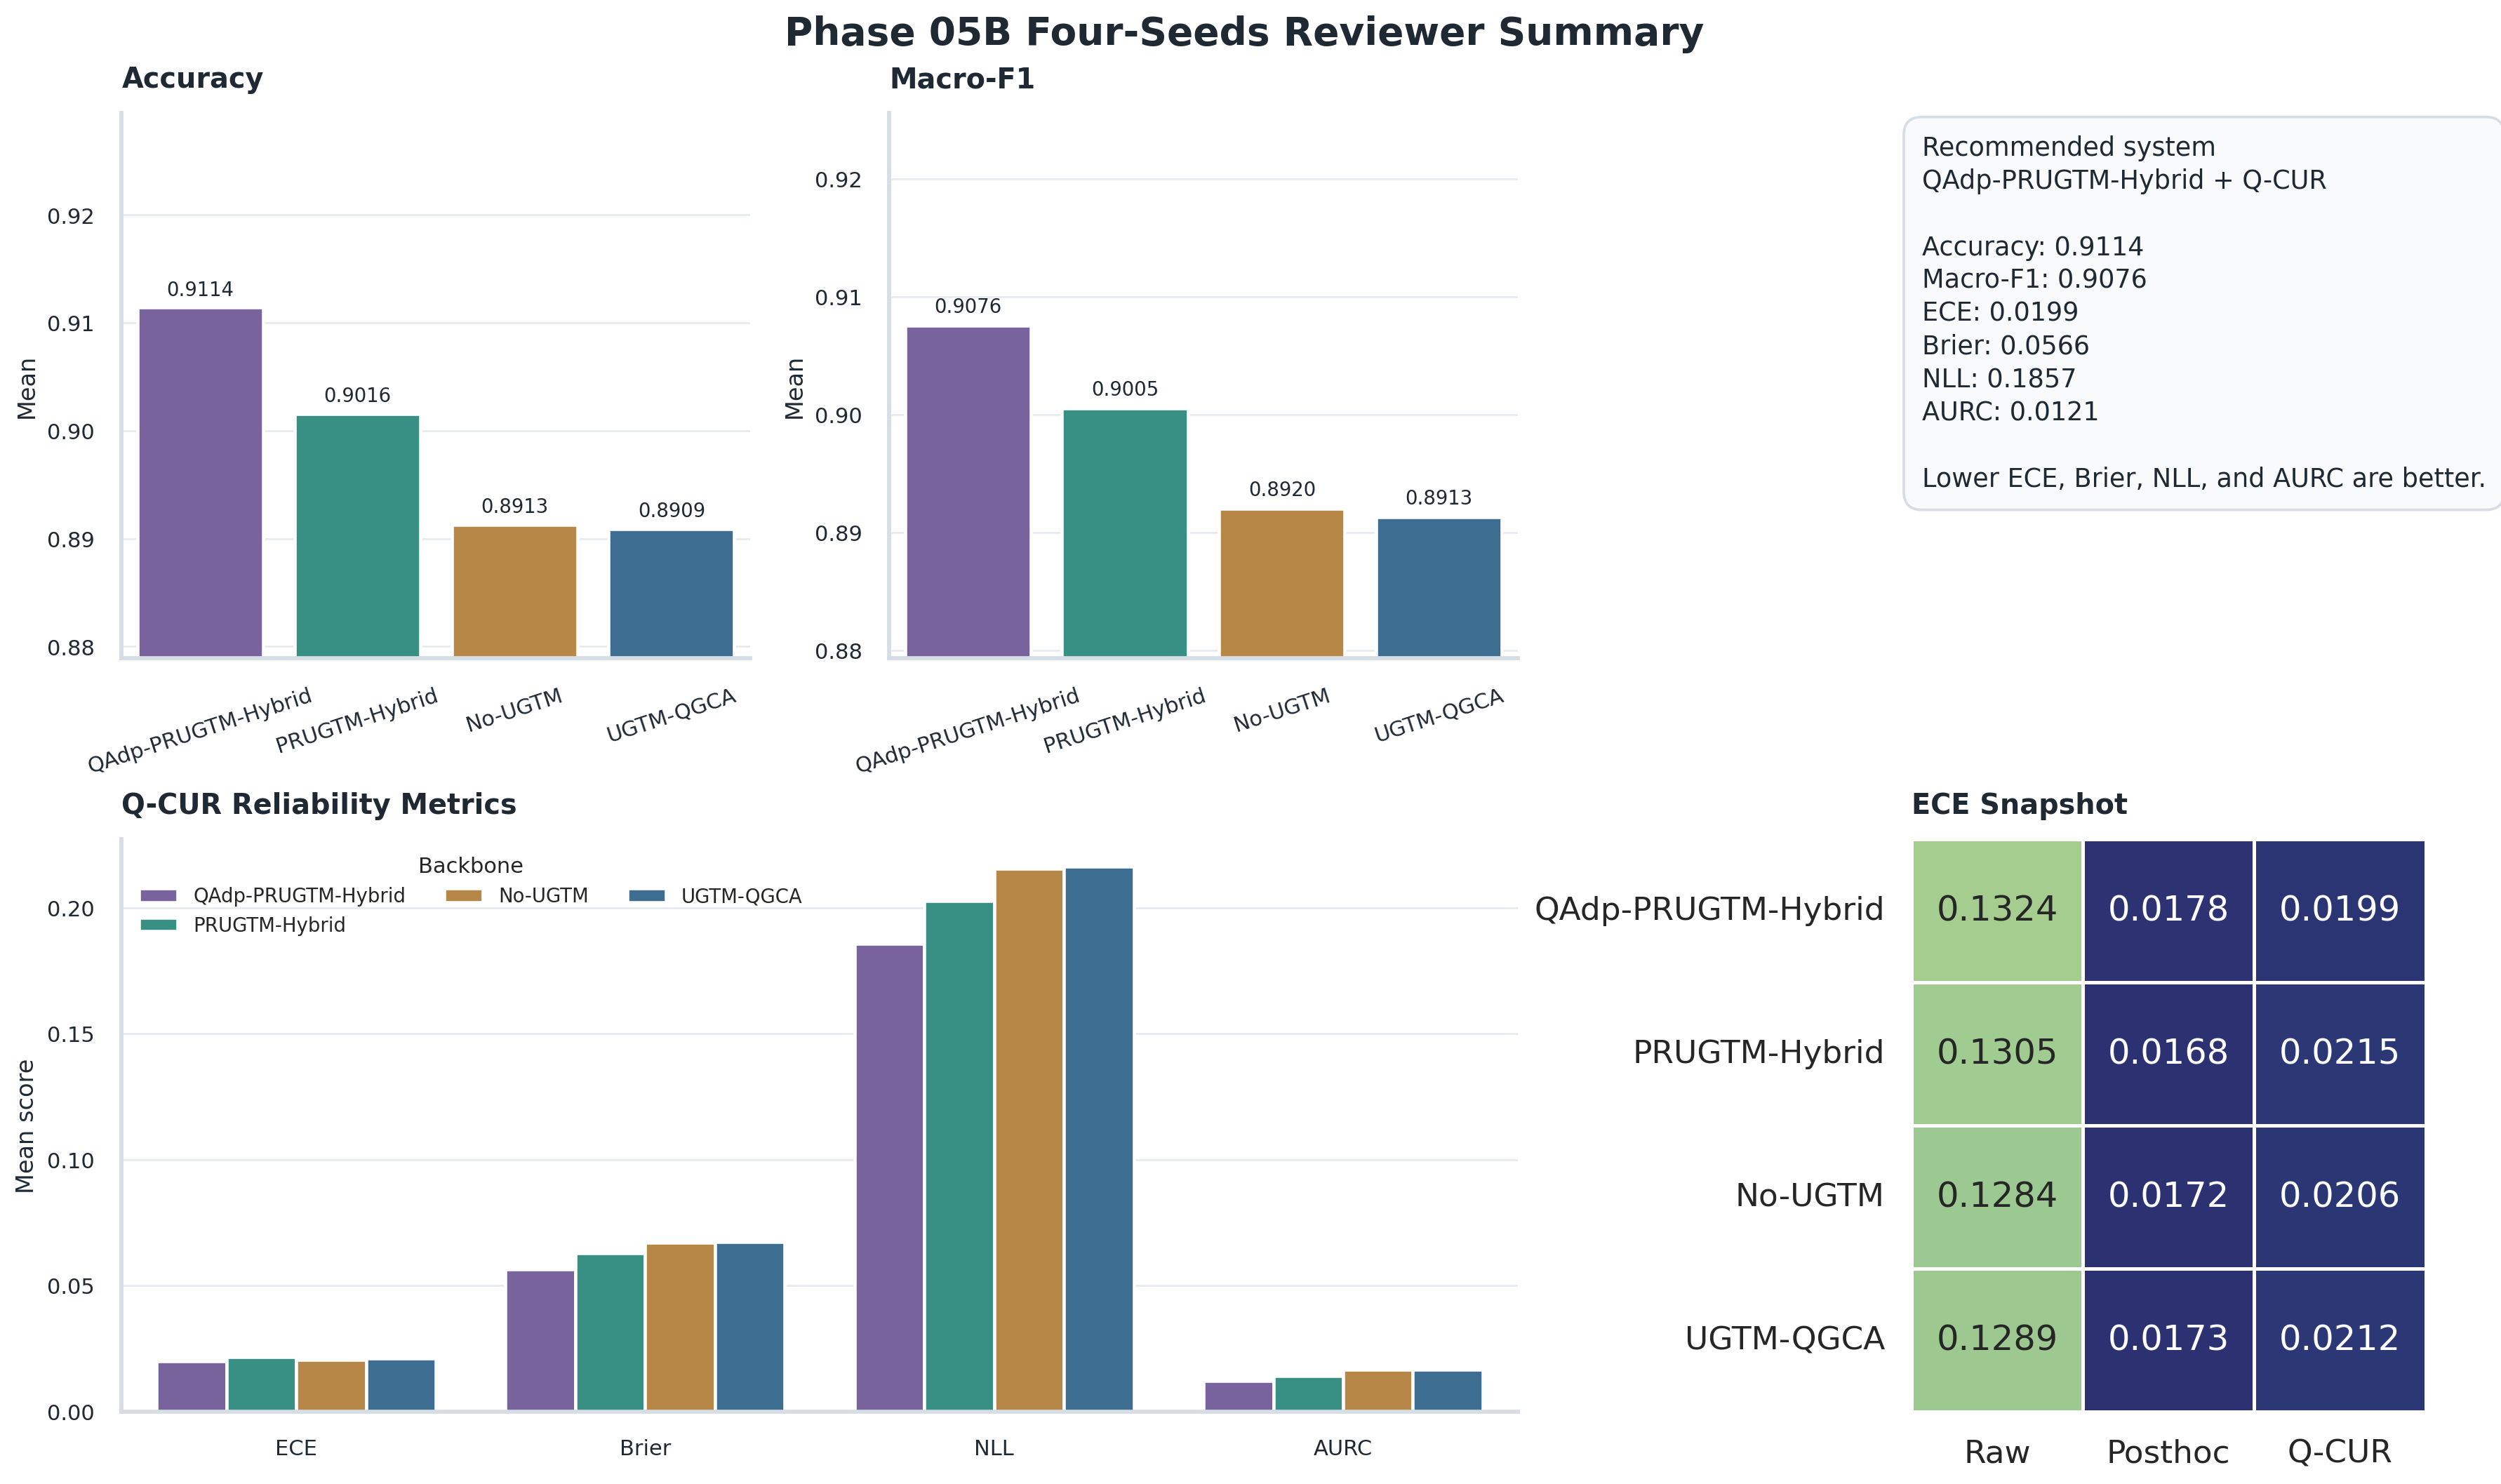

### Answer Backbone Comparison

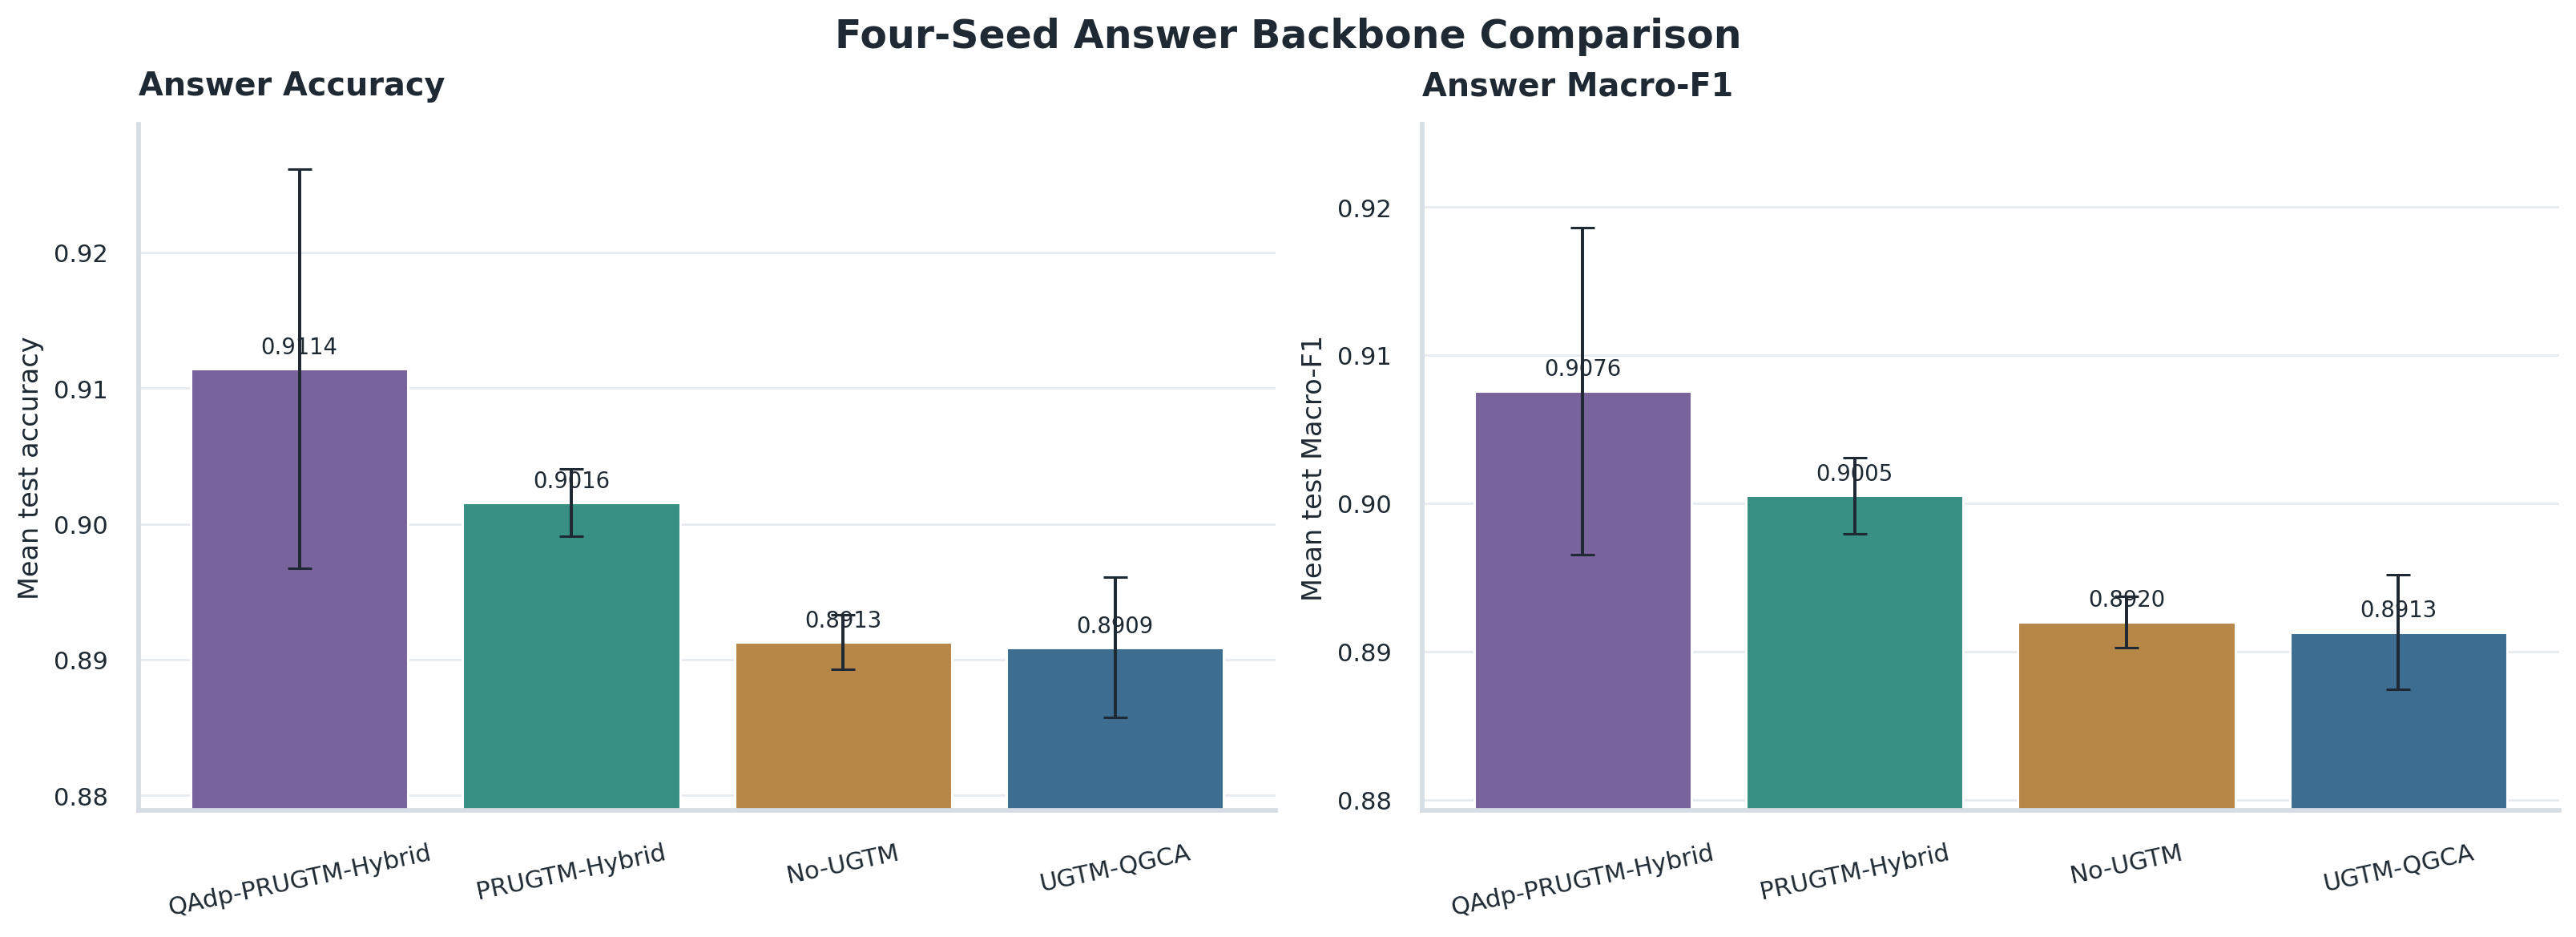

### Ablation Comparison

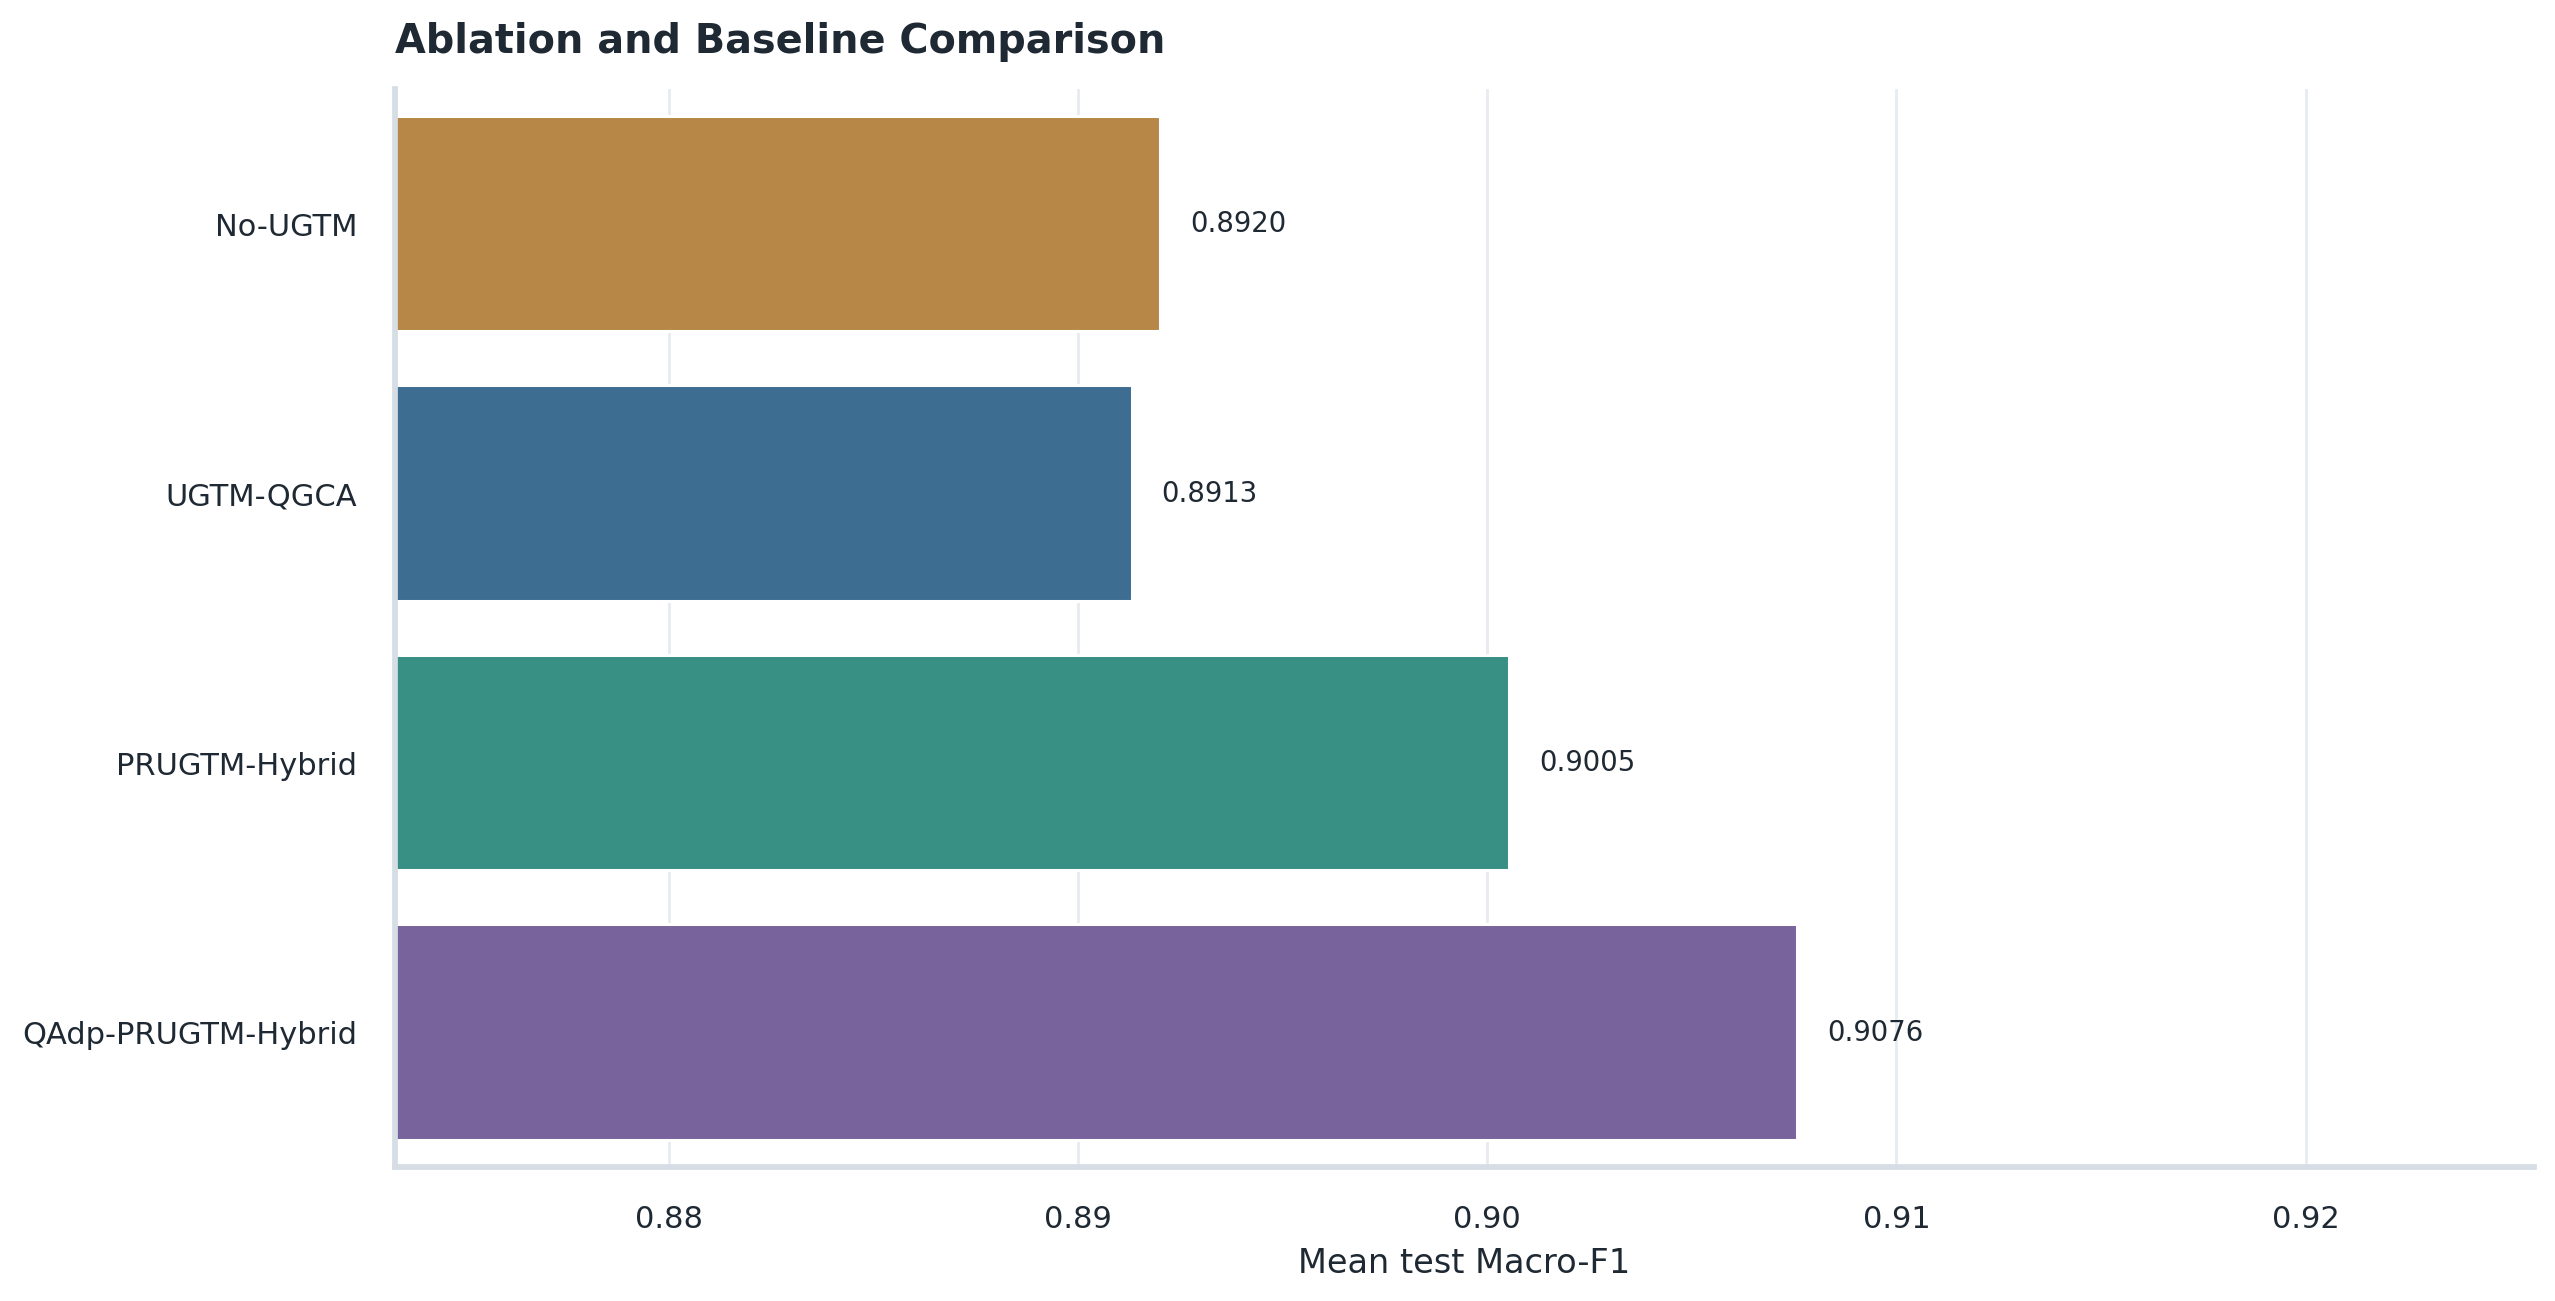

### Calibration Metrics Comparison

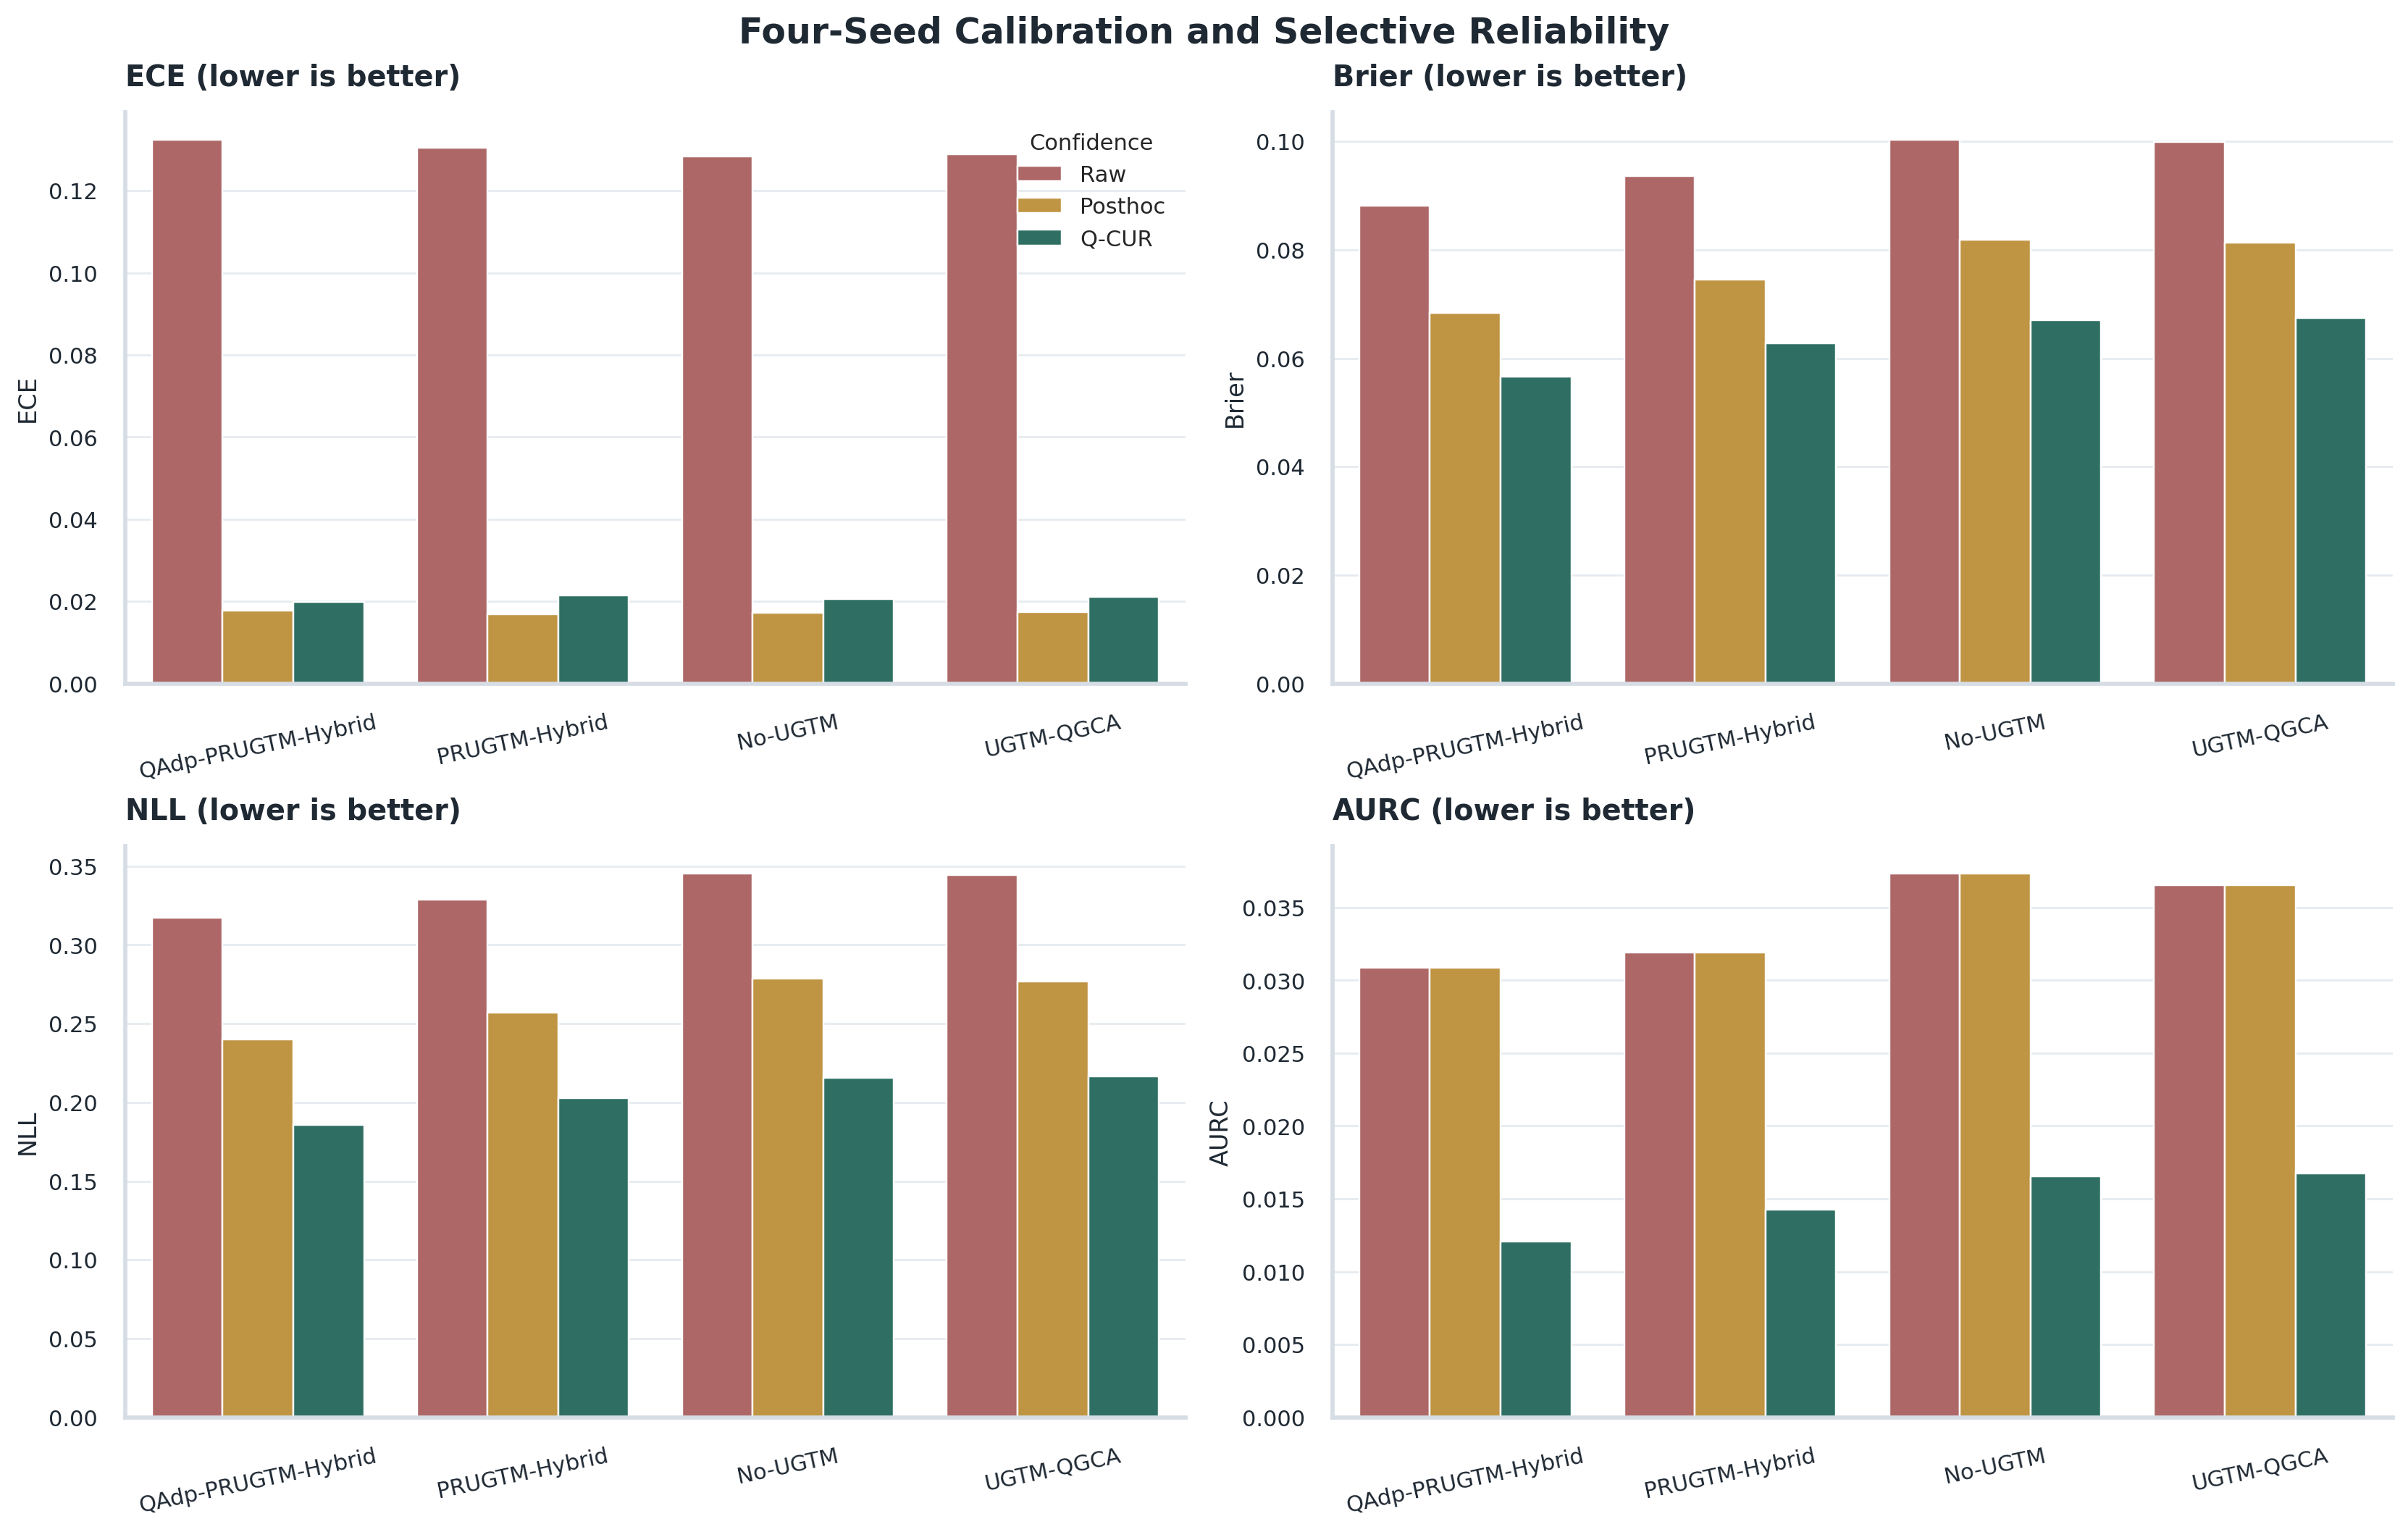

### Q-CUR Reliability Gain

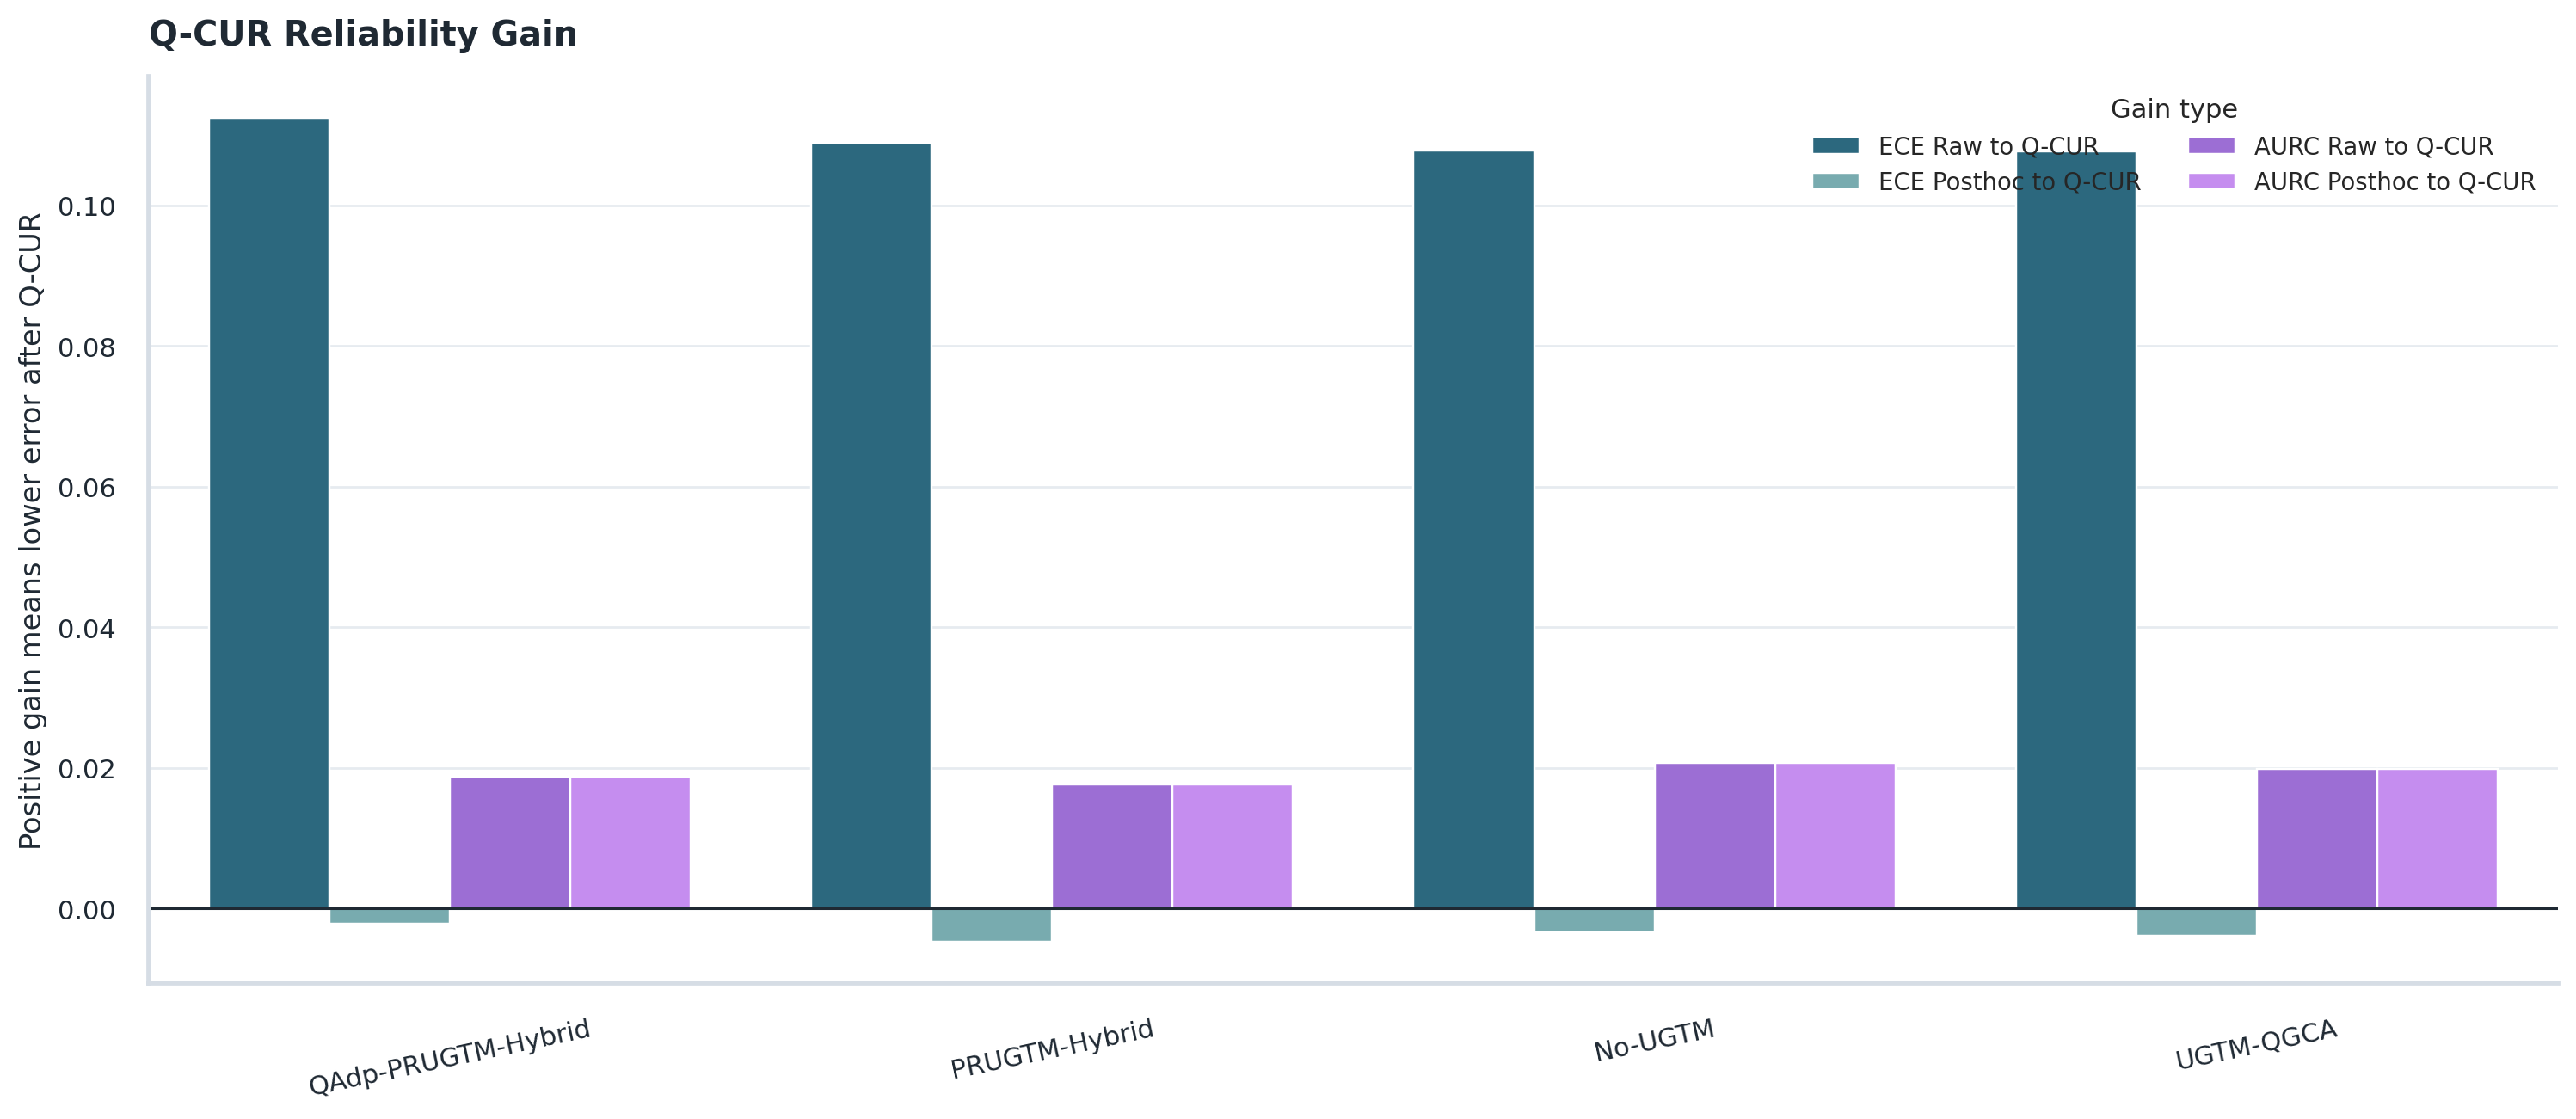

### ECE Heatmap

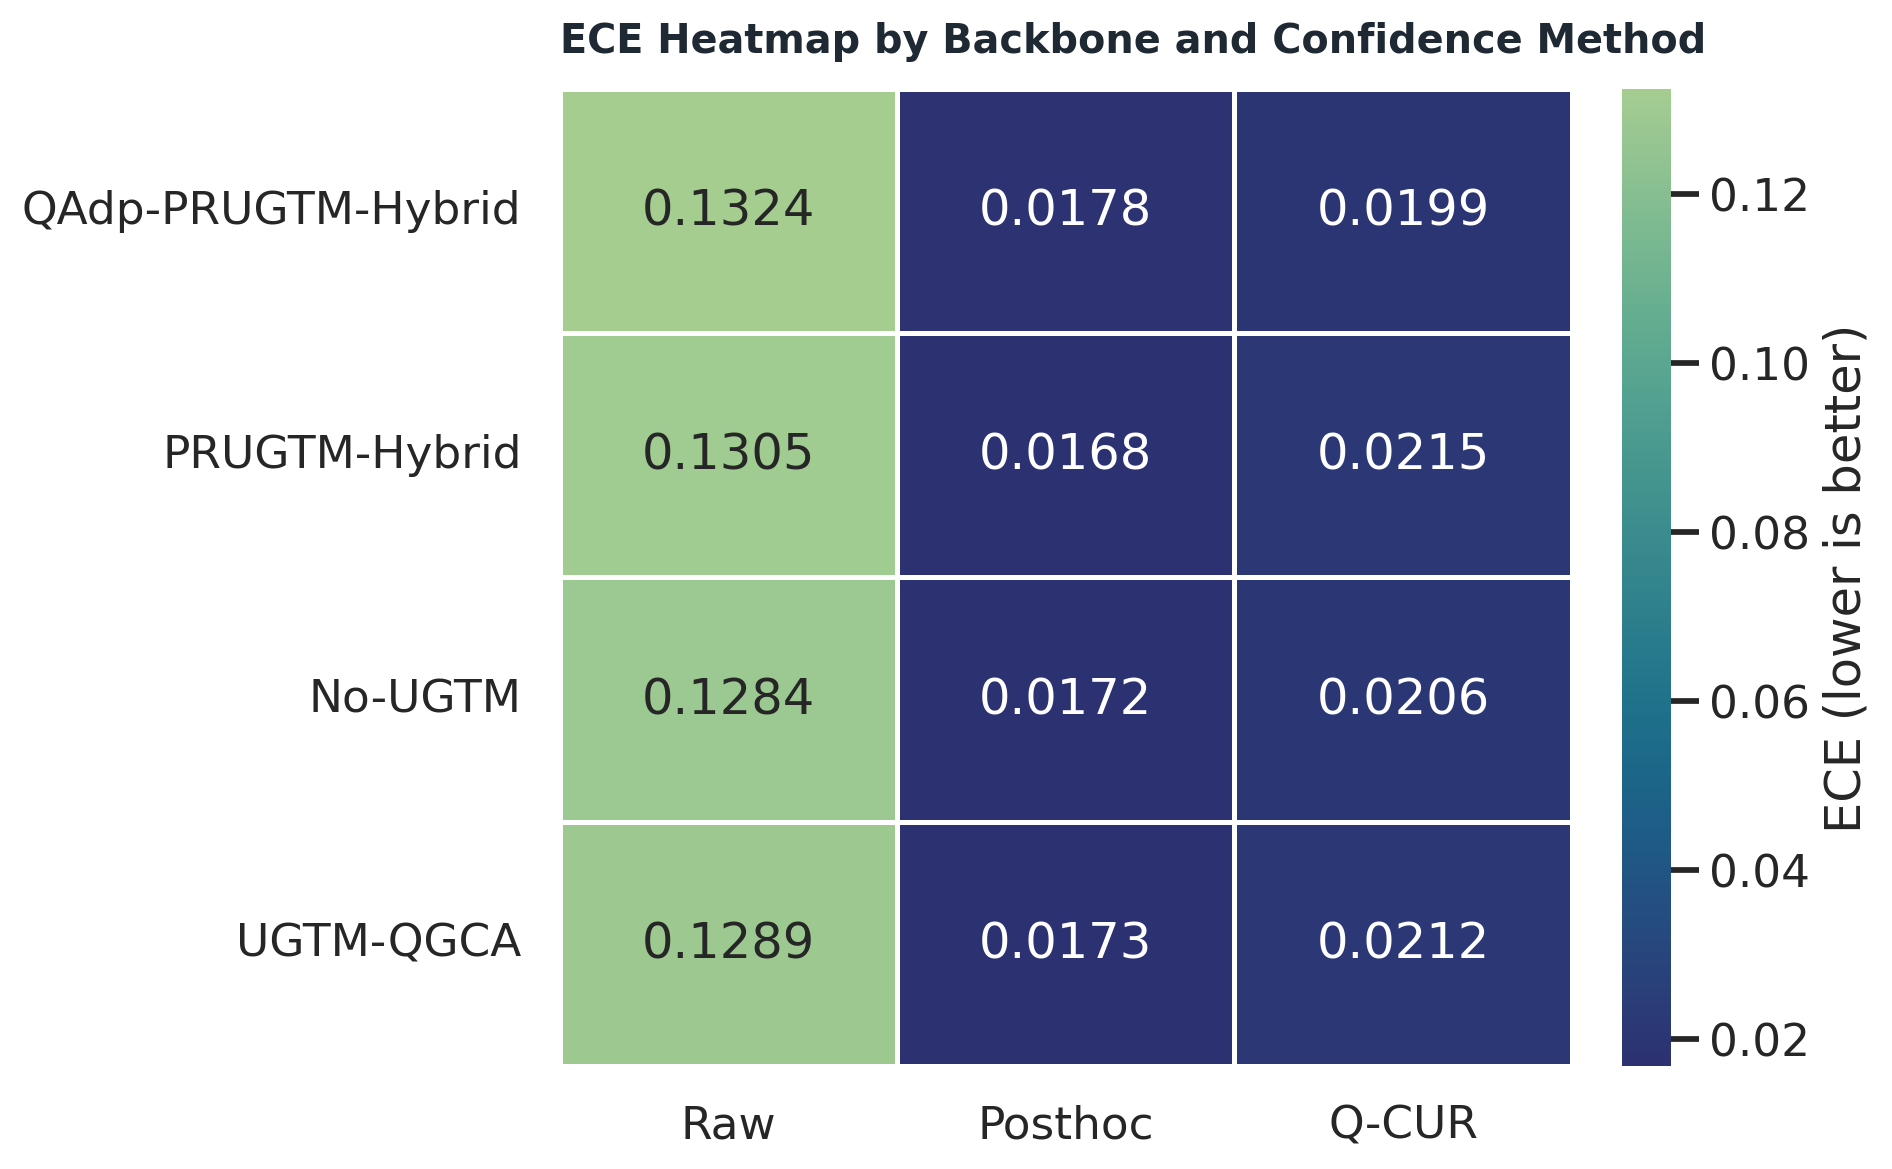

In [24]:
from IPython.display import display, Image, Markdown

figure_paths = {
    "Reviewer Summary Dashboard": REVIEWER_DASHBOARD_FIG_PATH,
    "Answer Backbone Comparison": ANSWER_COMPARISON_FIG_PATH,
    "Ablation Comparison": ABLATION_COMPARISON_FIG_PATH,
    "Calibration Metrics Comparison": CALIBRATION_COMPARISON_FIG_PATH,
    "Q-CUR Reliability Gain": QCUR_GAIN_FIG_PATH,
    "ECE Heatmap": ECE_HEATMAP_FIG_PATH,
}

for title, path in figure_paths.items():
    display(Markdown(f"### {title}"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("Missing figure:", path)

## Backbone-Wise Reliability and Risk-Coverage Curves

## QAdp-PRUGTM-Hybrid

### Reliability Diagram

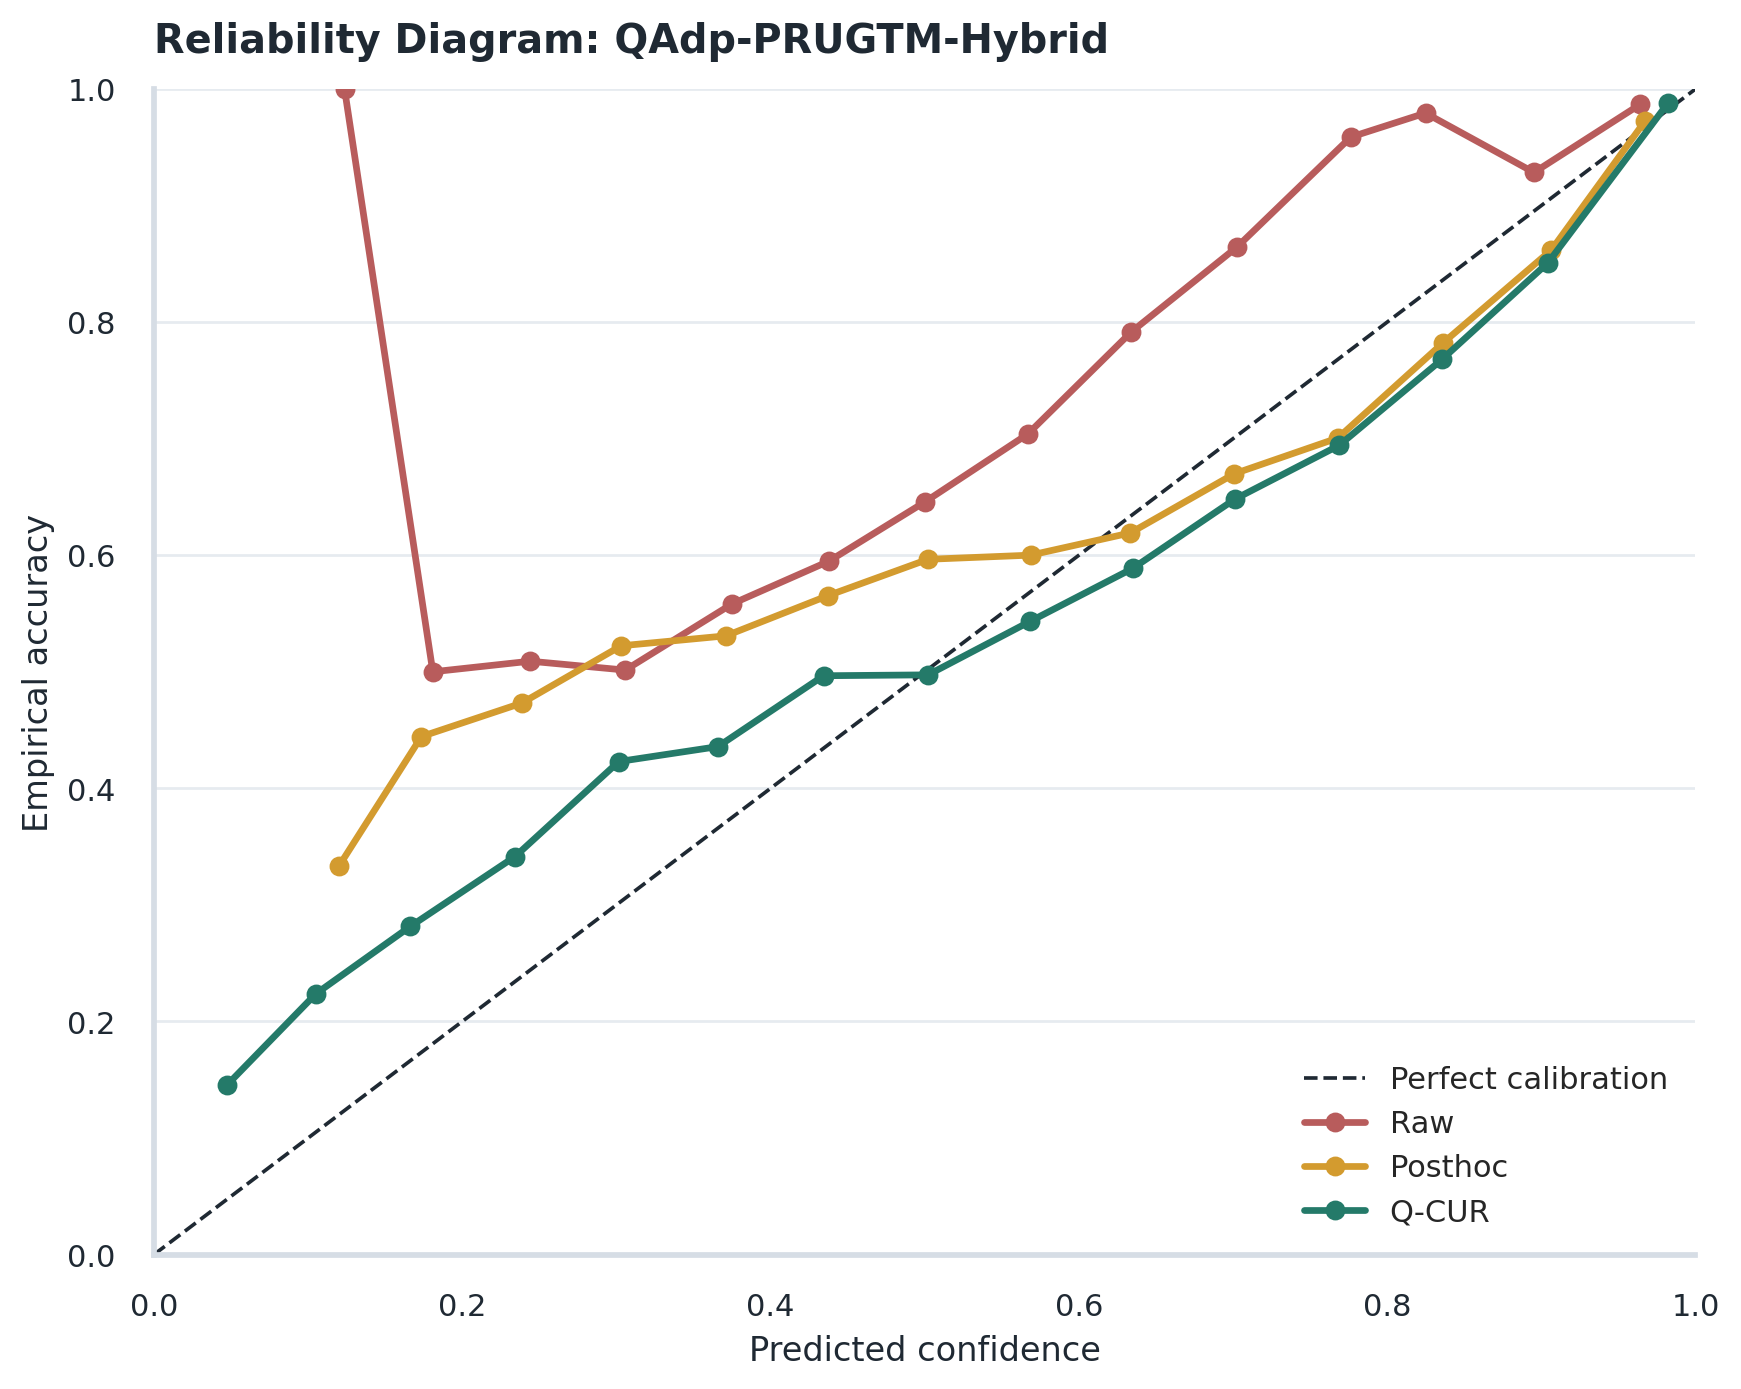

### Risk-Coverage Curve

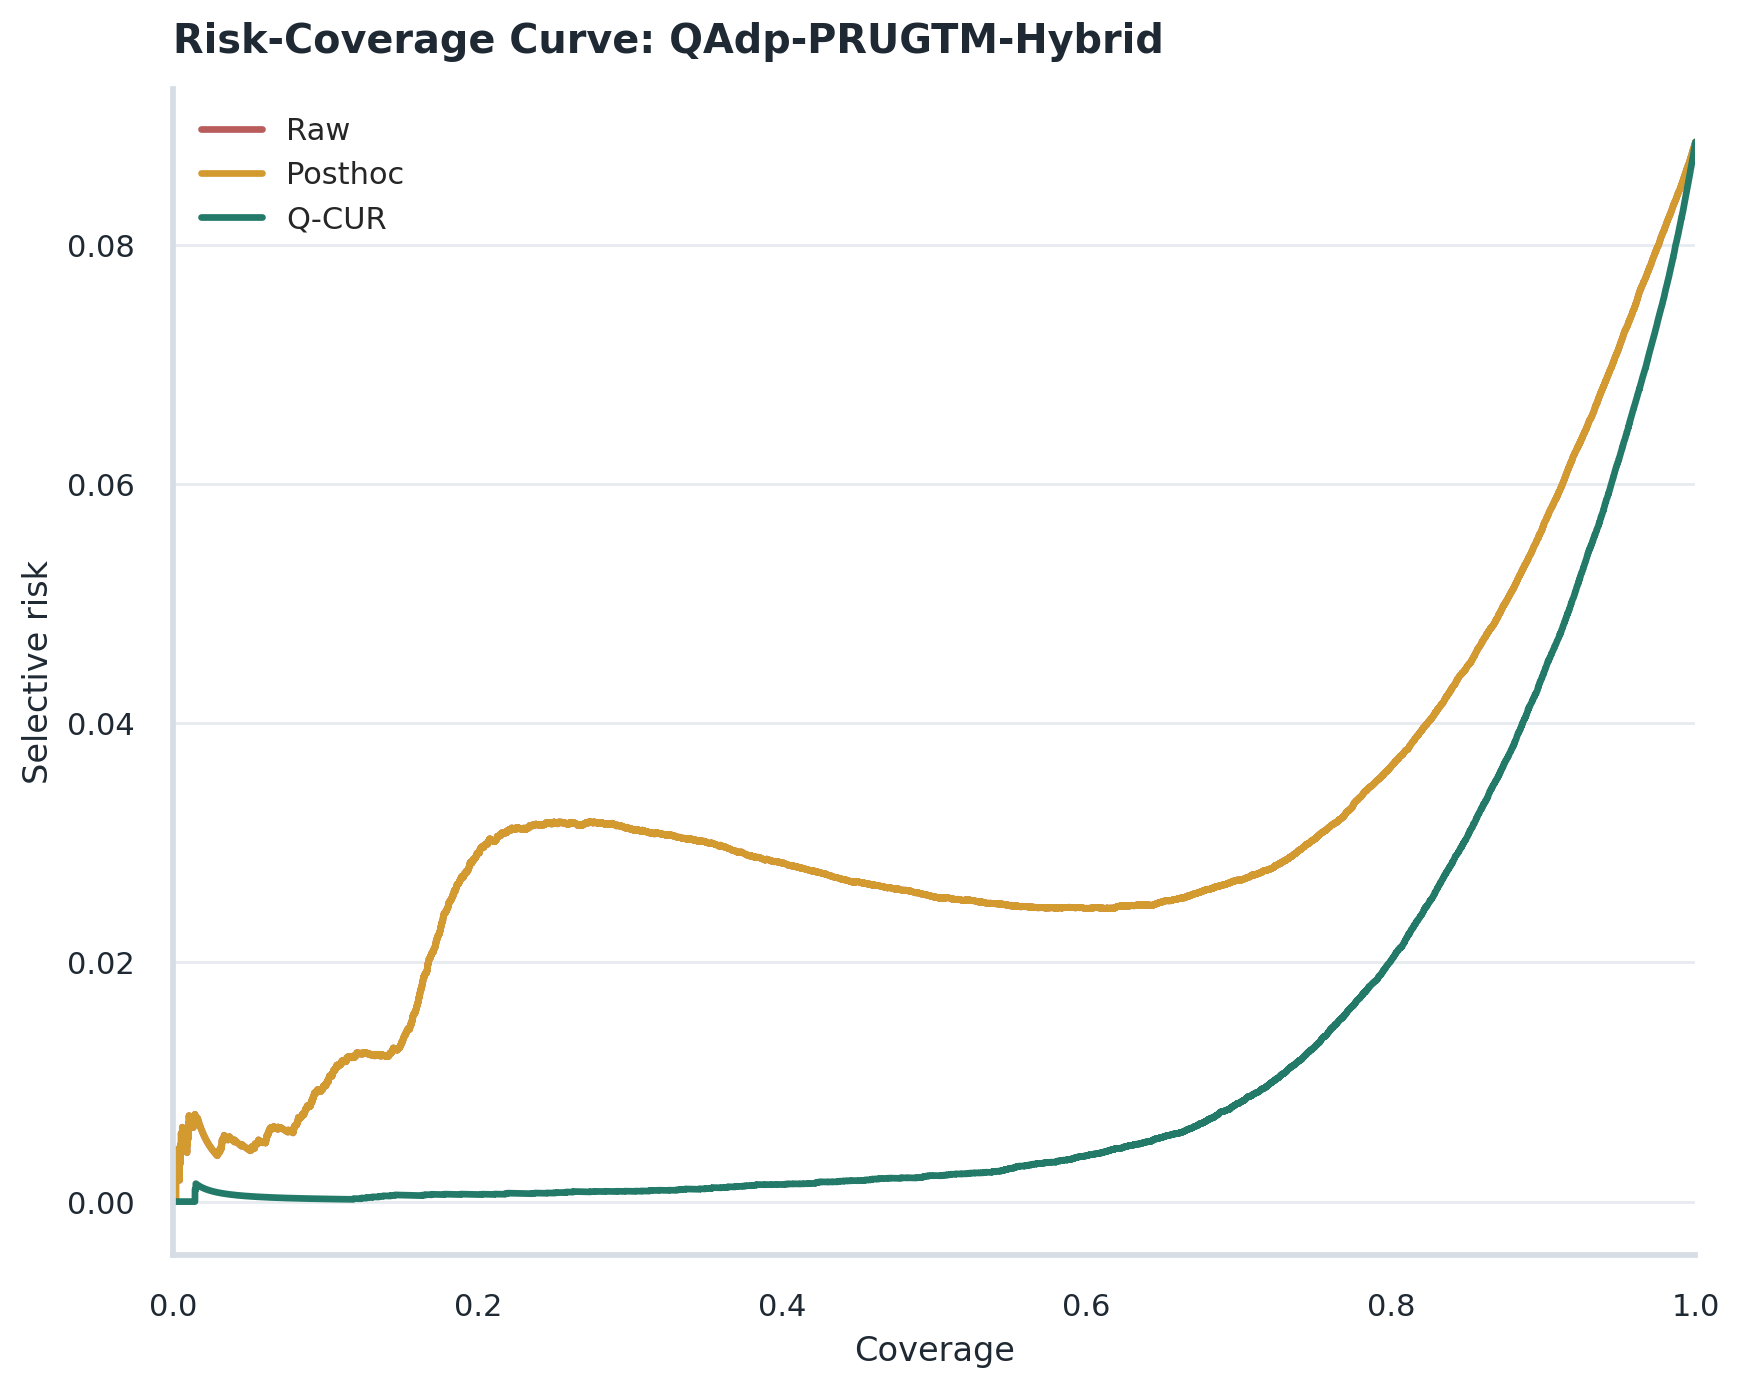

## PRUGTM-Hybrid

### Reliability Diagram

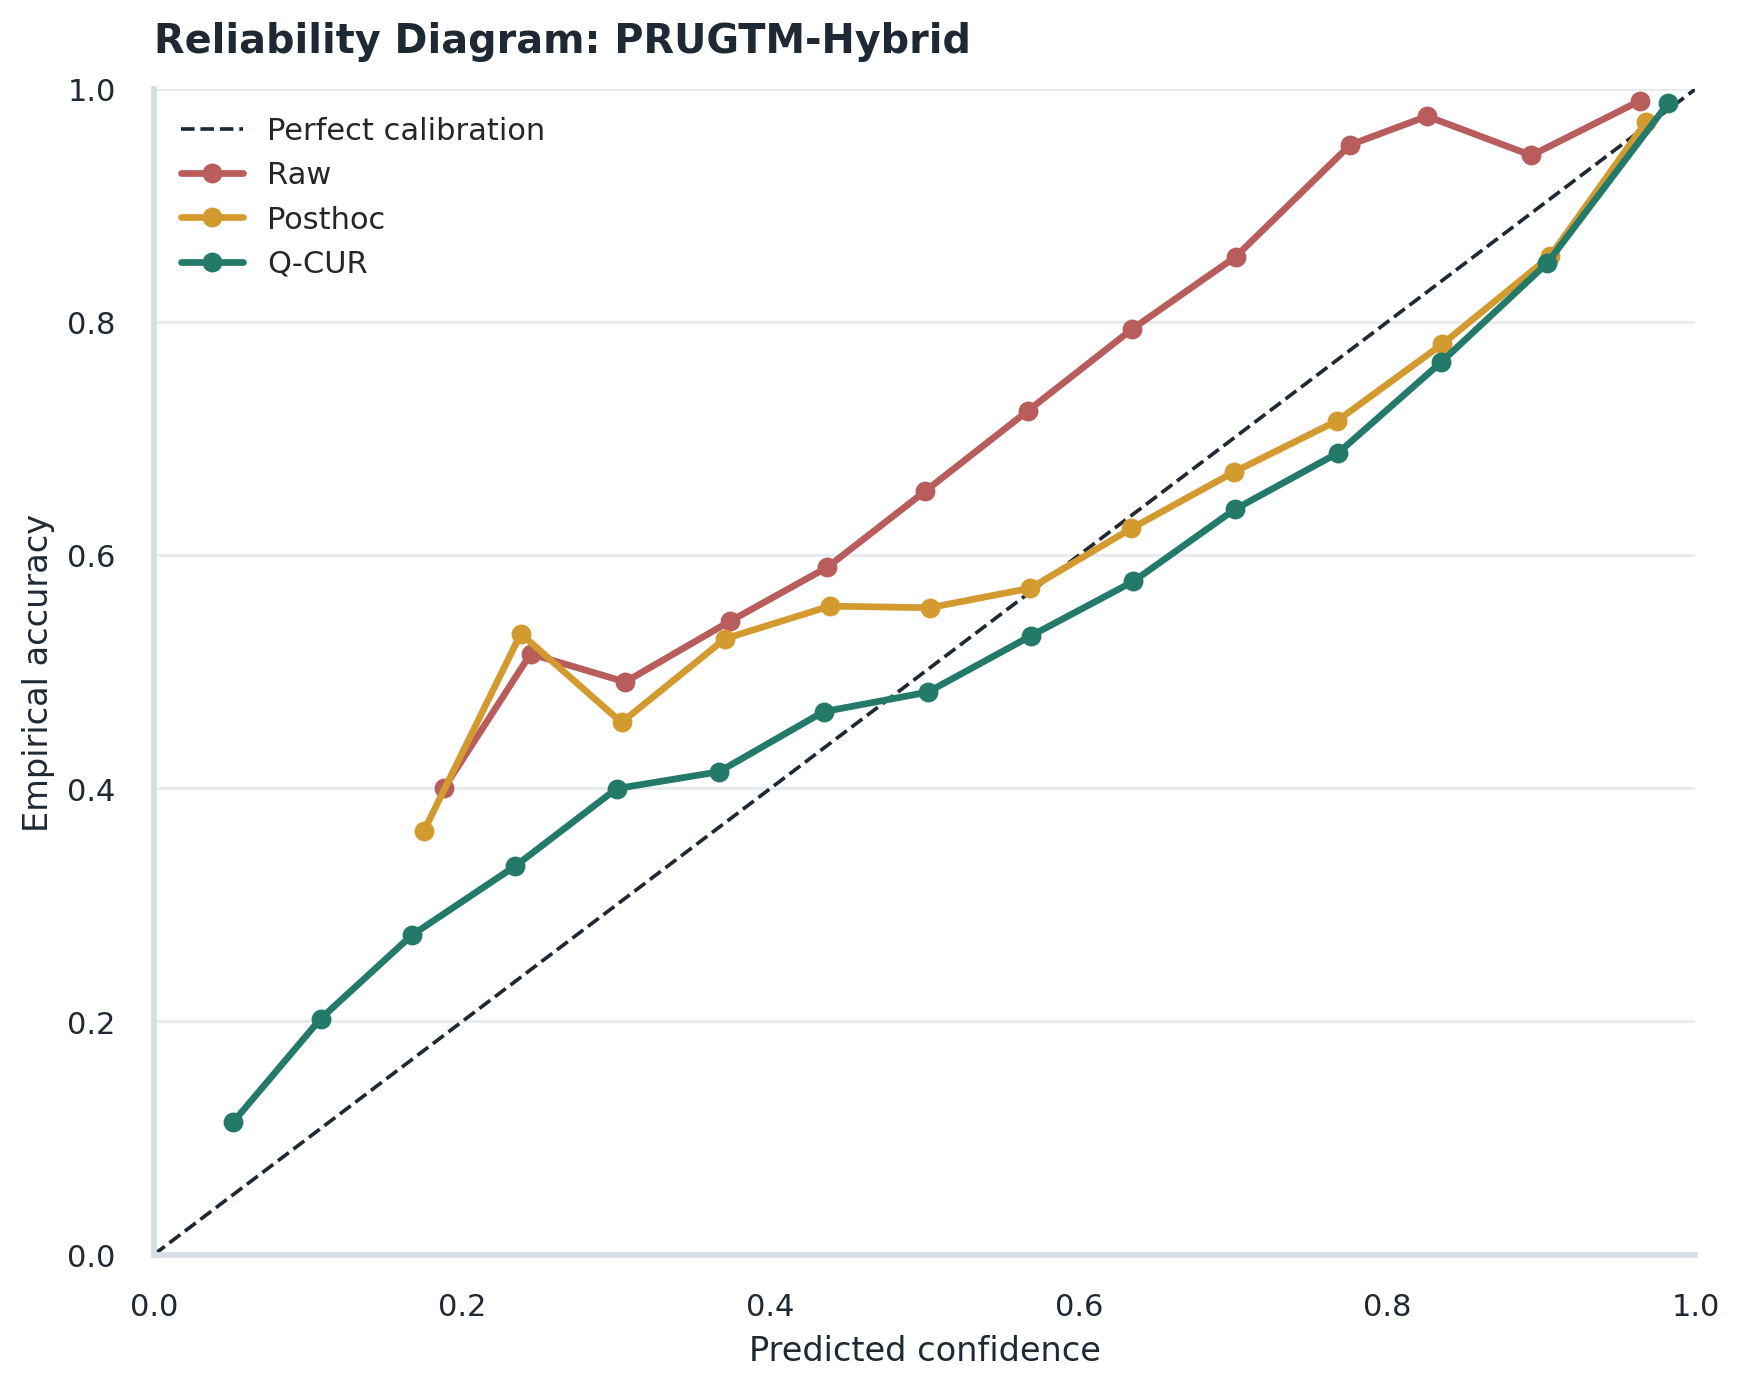

### Risk-Coverage Curve

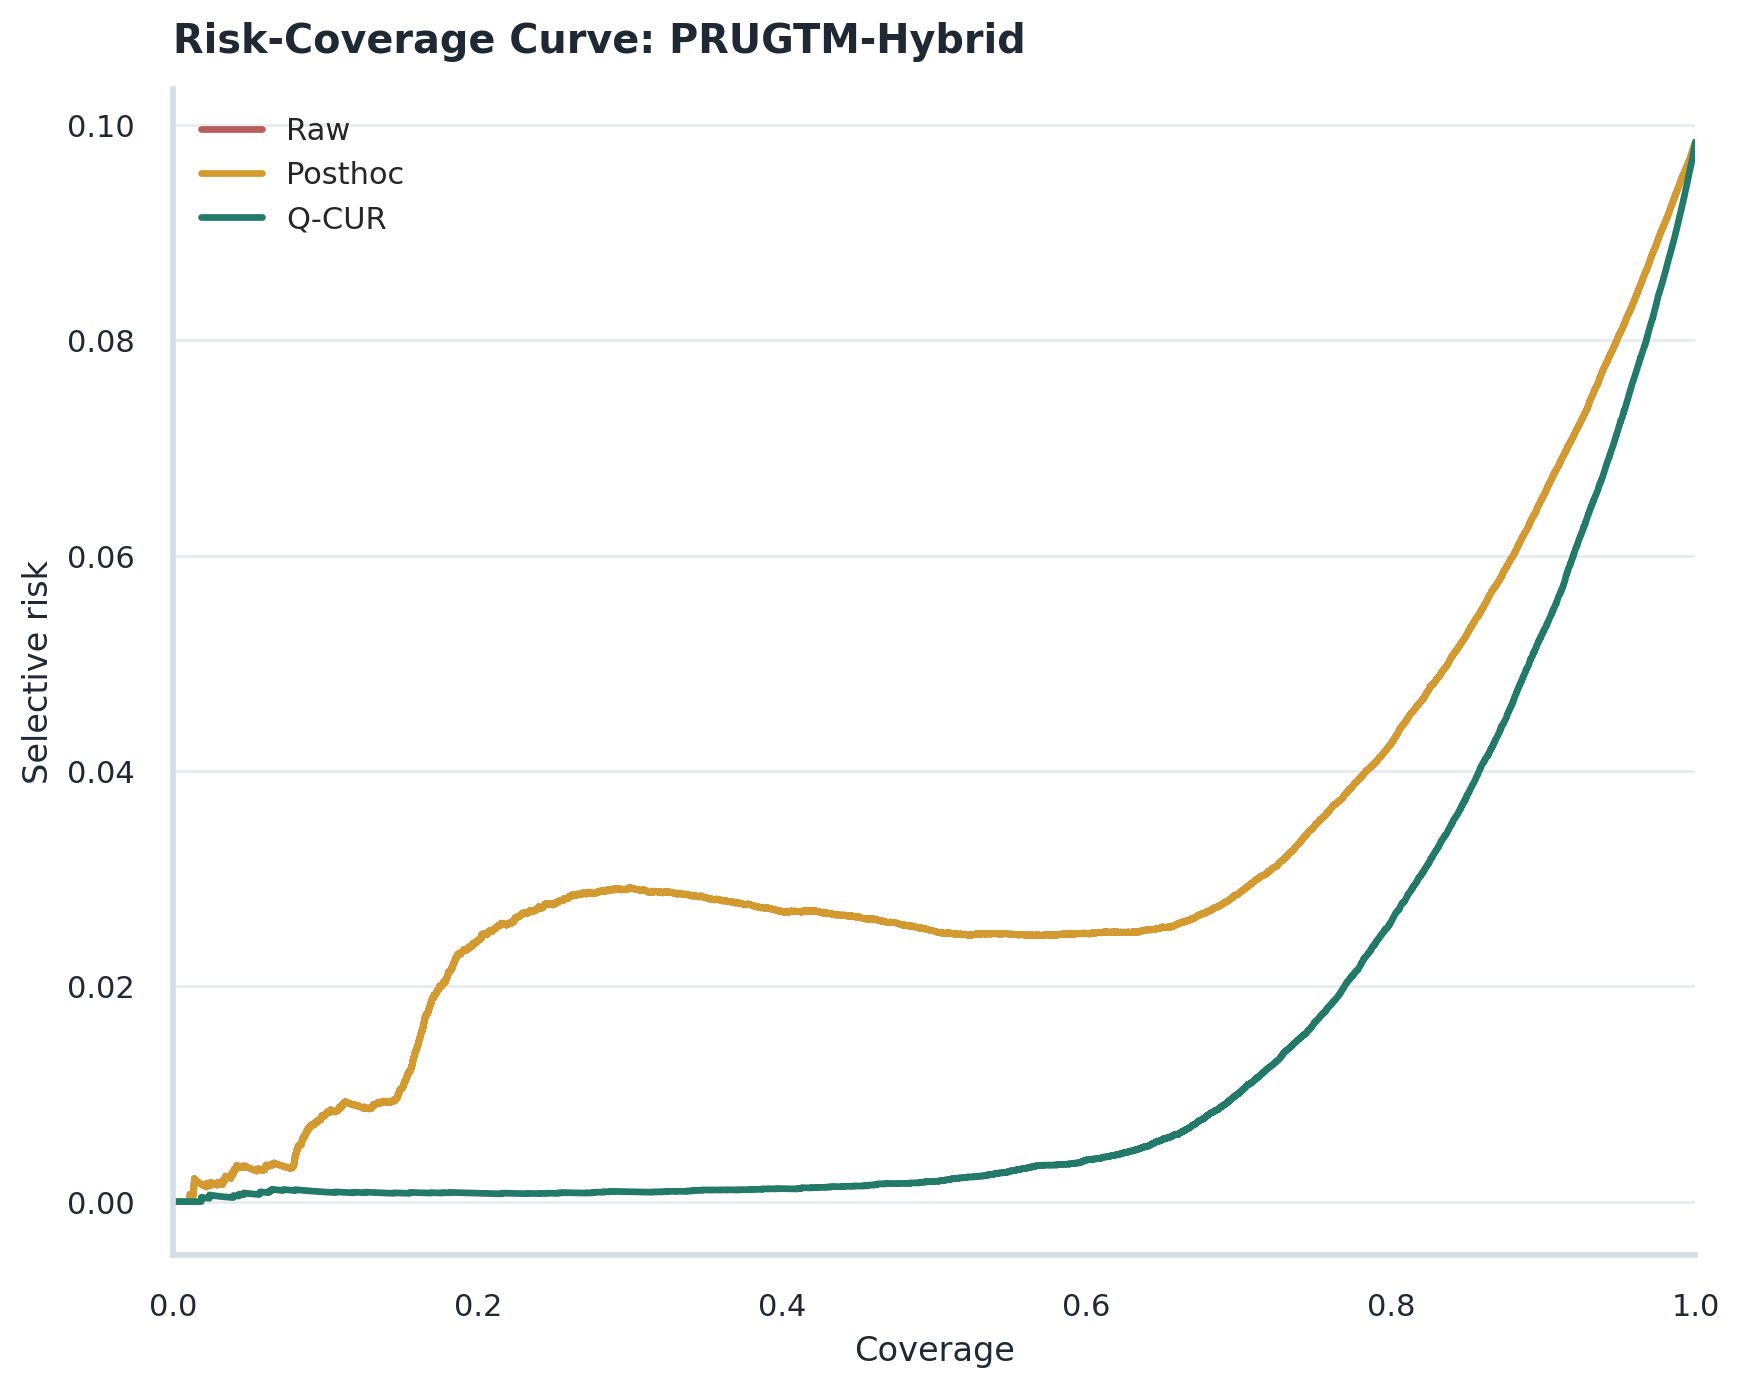

## No-UGTM

### Reliability Diagram

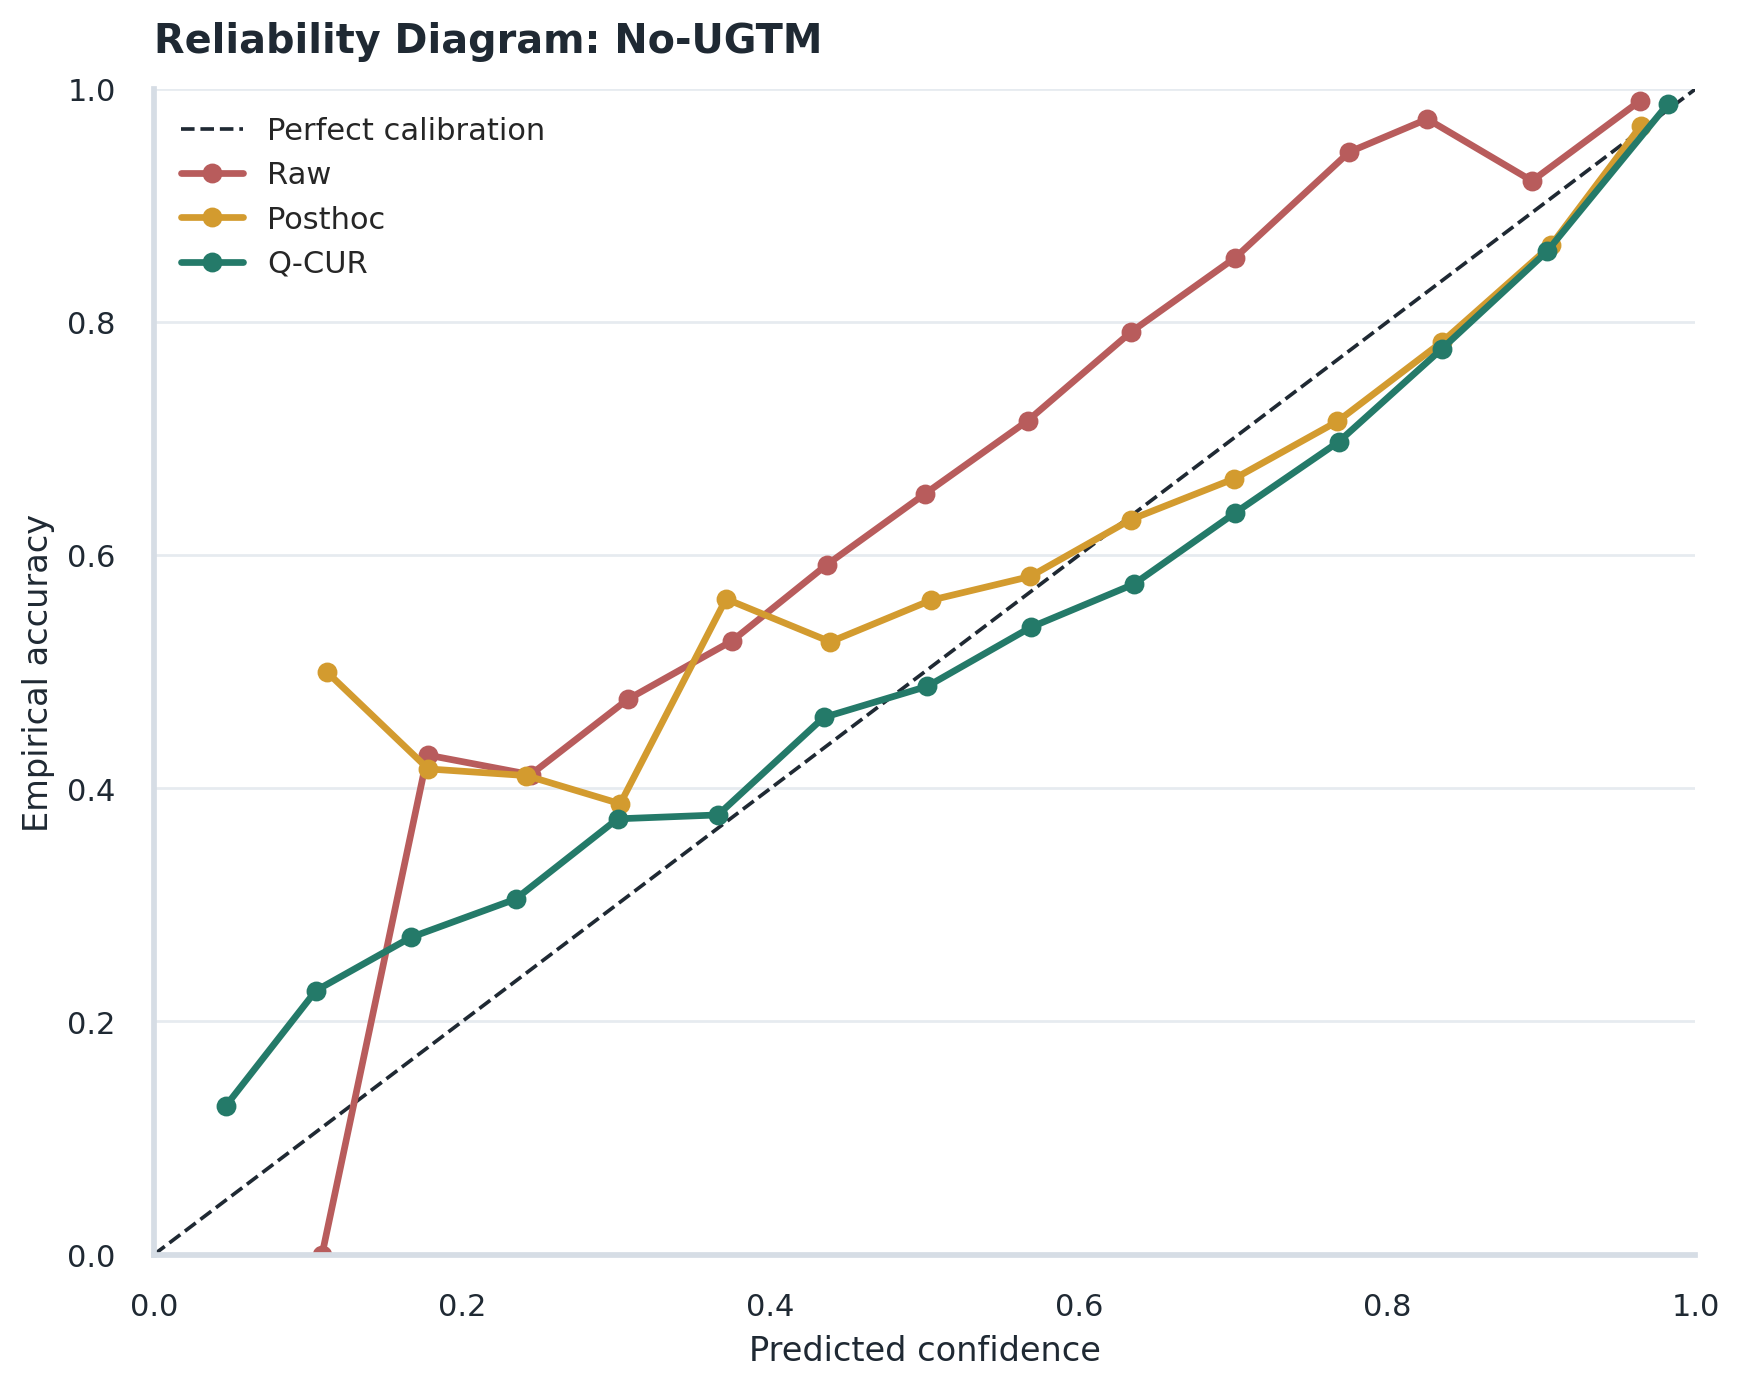

### Risk-Coverage Curve

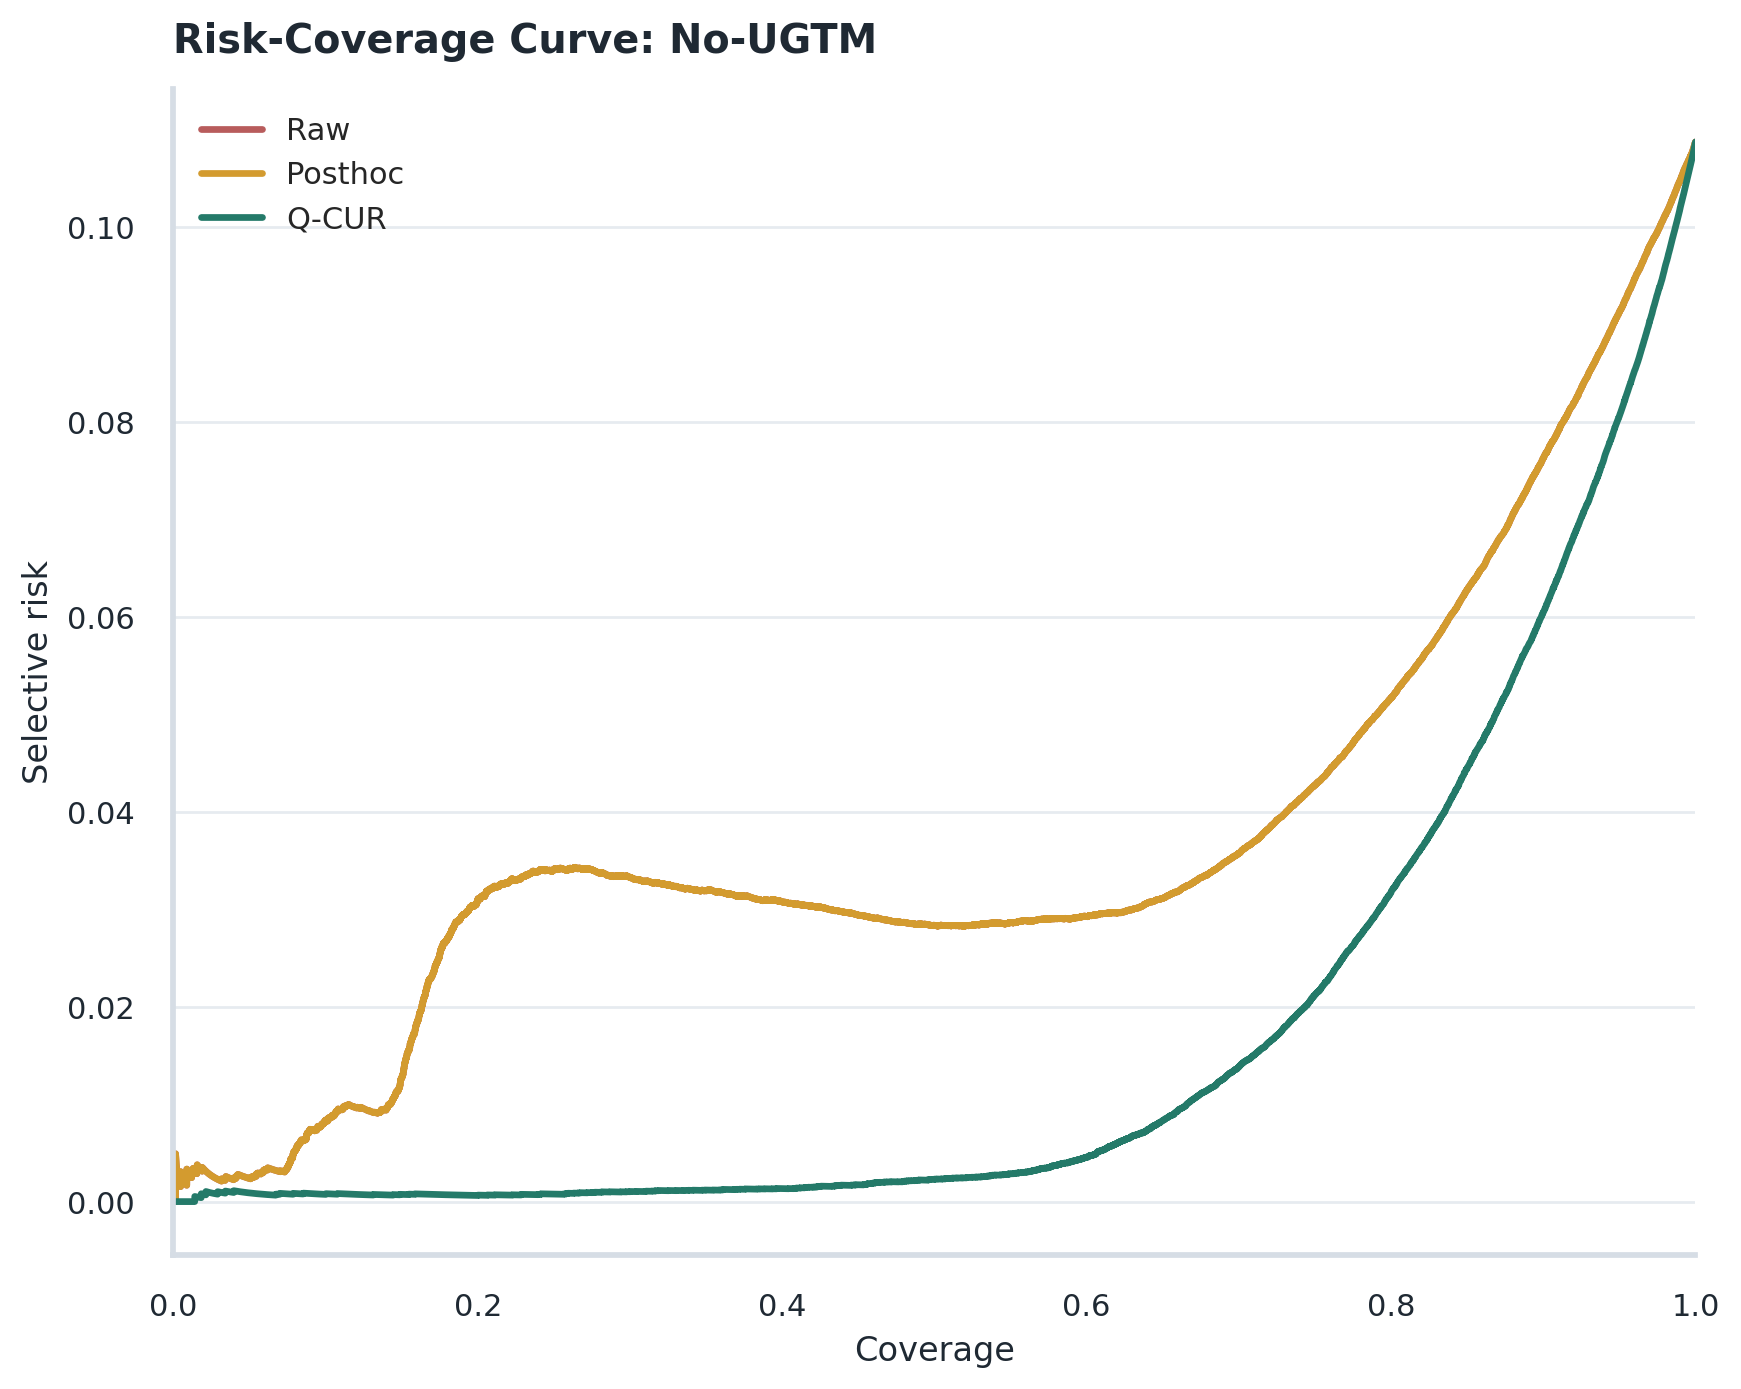

## UGTM-QGCA

### Reliability Diagram

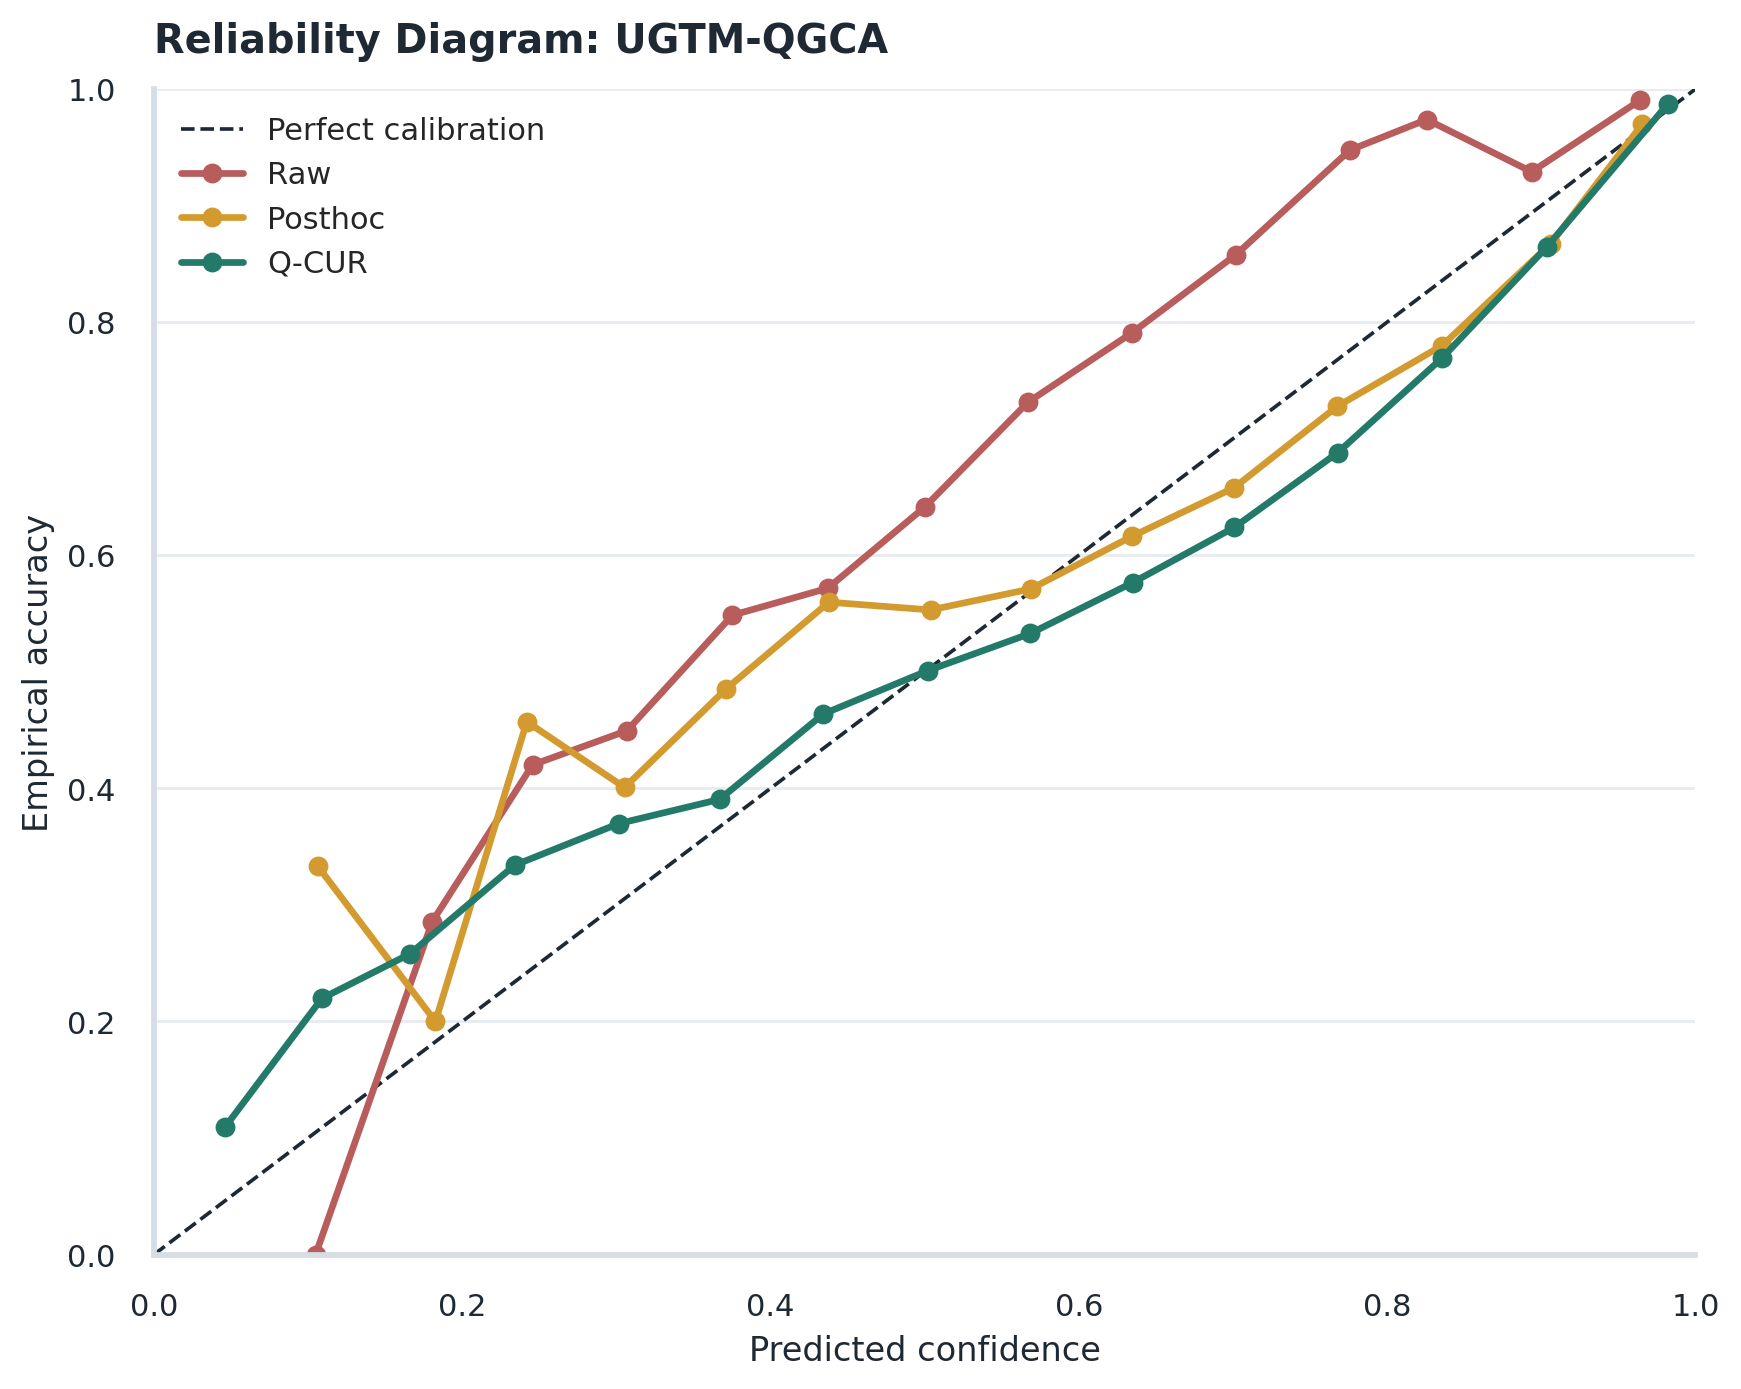

### Risk-Coverage Curve

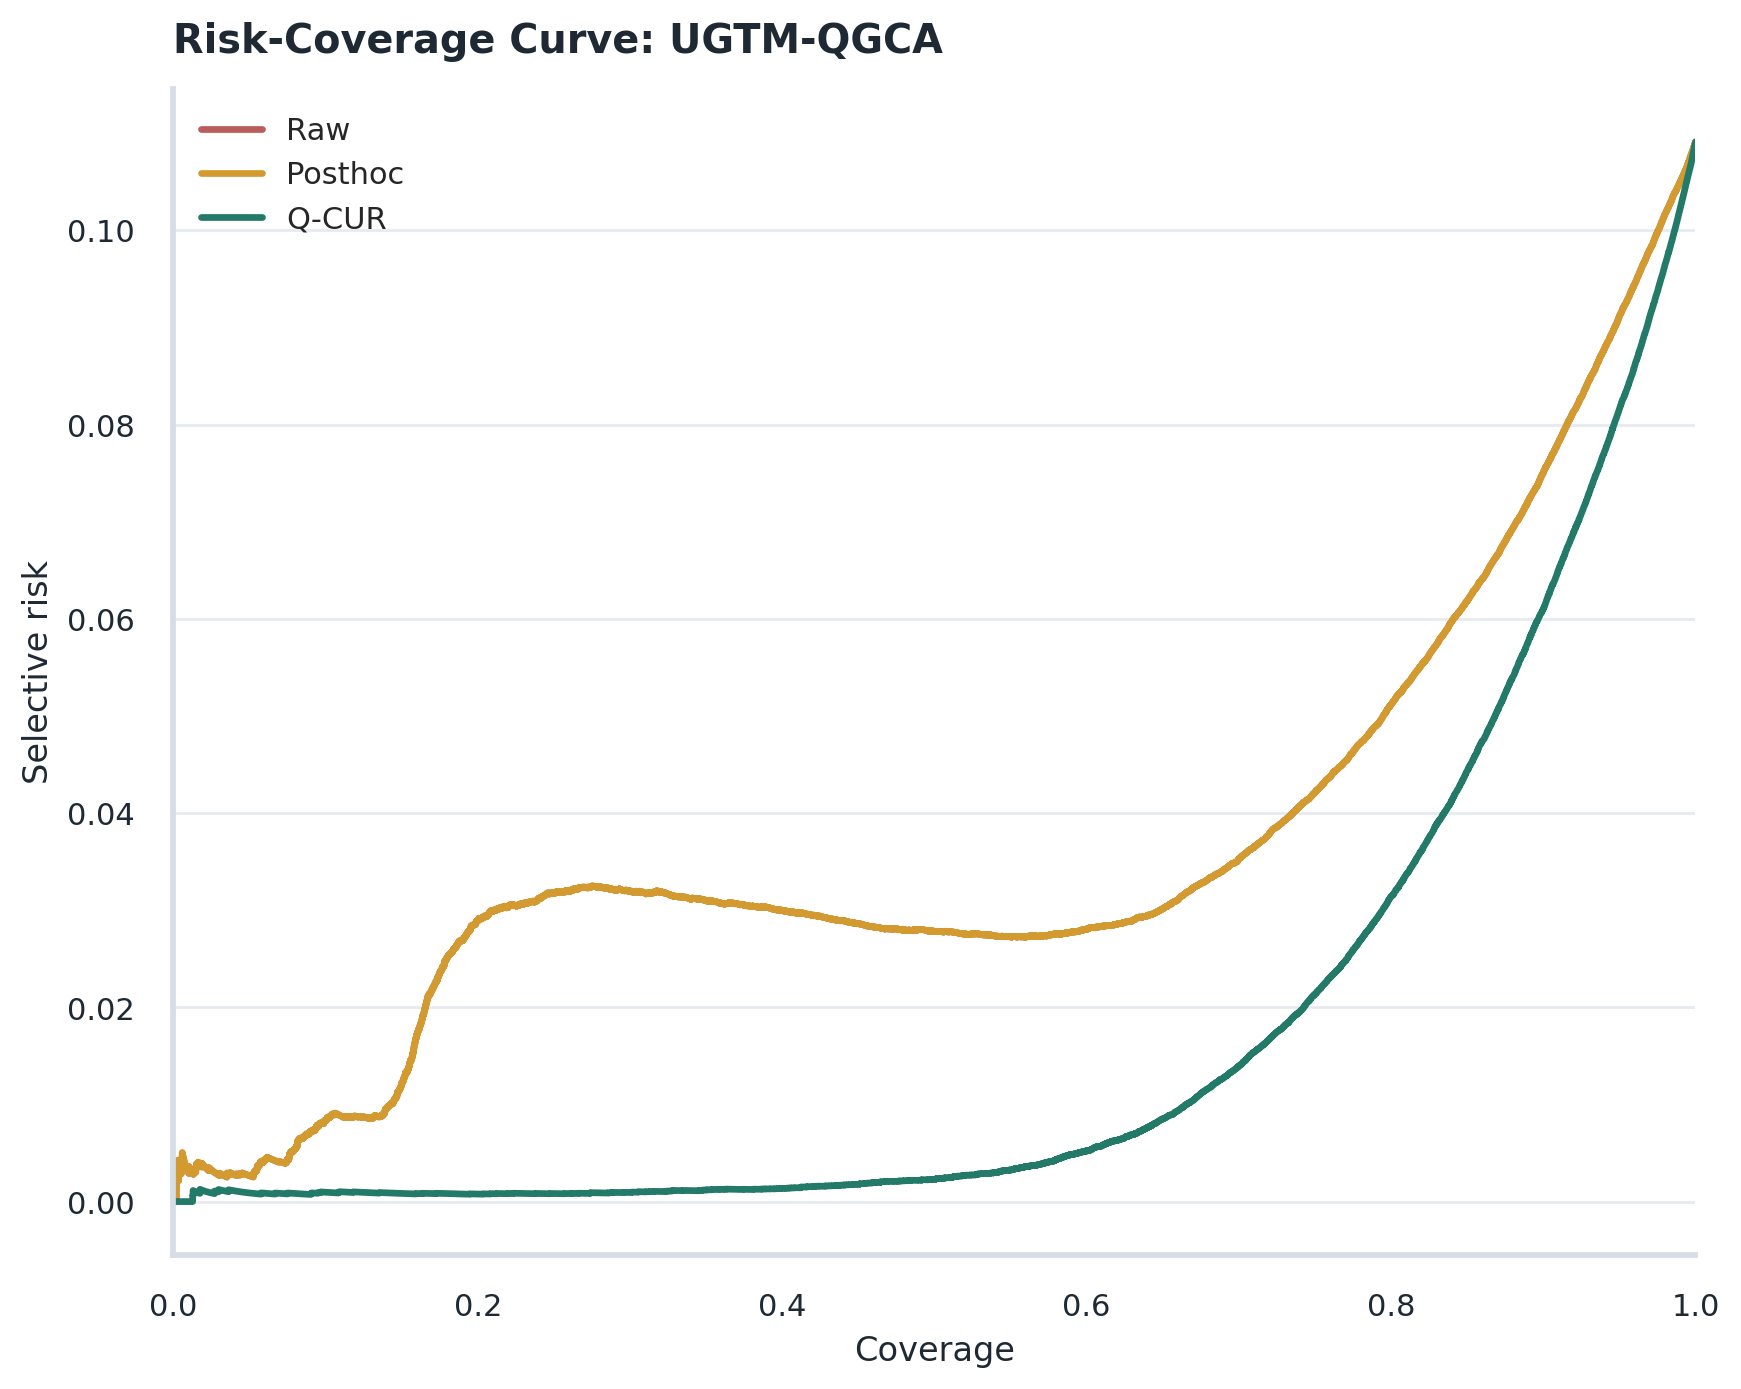

In [25]:
for backbone_key in ranked_backbone_keys:
    spec = BACKBONE_SPECS[backbone_key]
    label = spec["label"]

    reliability_path = FIGURES_DIR / f"{backbone_key}_four_seeds_reliability_diagram.png"
    risk_path = FIGURES_DIR / f"{backbone_key}_four_seeds_risk_coverage.png"

    display(Markdown(f"## {label}"))

    if reliability_path.exists():
        display(Markdown("### Reliability Diagram"))
        display(Image(filename=str(reliability_path)))

    if risk_path.exists():
        display(Markdown("### Risk-Coverage Curve"))
        display(Image(filename=str(risk_path)))

## Paper-Ready Calibration Metric Preview

In [26]:
calib_df = pd.read_csv(CALIBRATION_AGG_TABLE_PATH)

preview_cols = [
    "backbone",
    "method",
    "num_runs",
    "accuracy__mean",
    "macro_f1__mean",
    "ece__mean",
    "brier__mean",
    "nll__mean",
    "aurc__mean",
]

display(
    calib_df[preview_cols]
    .assign(backbone_rank=lambda df: df["backbone"].map(backbone_rank_map).fillna(999).astype(int))
    .assign(method=lambda df: pd.Categorical(df["method"], METHOD_ORDER, ordered=True))
    .sort_values(["backbone_rank", "method"])
    .drop(columns=["backbone_rank"])
    .round(6)
    .style
    .background_gradient(subset=["ece__mean", "brier__mean", "nll__mean", "aurc__mean"], cmap="YlGnBu_r")
    .format(precision=6)
)

,backbone,method,num_runs,accuracy__mean,macro_f1__mean,ece__mean,brier__mean,nll__mean,aurc__mean
0,QAdp-PRUGTM-Hybrid,Raw,4,0.911430,0.907572,0.132420,0.088085,0.317142,0.030860
1,QAdp-PRUGTM-Hybrid,Posthoc,4,0.911430,0.907572,0.017798,0.068307,0.240030,0.030860
2,QAdp-PRUGTM-Hybrid,Q-CUR,4,0.911430,0.907572,0.019947,0.056616,0.185718,0.012078
3,PRUGTM-Hybrid,Raw,4,0.901585,0.900537,0.130487,0.093628,0.328611,0.031901
4,PRUGTM-Hybrid,Posthoc,4,0.901585,0.900537,0.016816,0.074557,0.256993,0.031901
5,PRUGTM-Hybrid,Q-CUR,4,0.901585,0.900537,0.021532,0.062786,0.202839,0.014241
6,No-UGTM,Raw,4,0.891311,0.892008,0.128424,0.100312,0.345225,0.037326
7,No-UGTM,Posthoc,4,0.891311,0.892008,0.017204,0.081867,0.278761,0.037326
8,No-UGTM,Q-CUR,4,0.891311,0.892008,0.020570,0.067051,0.215549,0.016552
9,UGTM-QGCA,Raw,4,0.890911,0.891312,0.128898,0.099909,0.344246,0.036539
